<a href="https://colab.research.google.com/github/shanta-2000/Enhanced-Neural-Multi-Perspective-Learning-for-Heart-Disease-Prediction./blob/main/ENMP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enhanced Neural Multi-Perspective Learning for Heart-Disease Prediction

## Part 1: Dataset Loading and Initial Audit

This notebook implements the project step by step.  
The first stage loads and validates the two cardiovascular datasets:

1. Heart Disease Dataset
2. Cardiovascular Disease Dataset


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define the dataset folder

In [3]:
DATA_FOLDER = "/content/drive/MyDrive/Neural Network"

heart_path = os.path.join(DATA_FOLDER, "heart.csv")
cardio_path = os.path.join(DATA_FOLDER, "cardio_train.csv")

print("Heart dataset path:")
print(heart_path)

print("\nCardiovascular dataset path:")
print(cardio_path)

Heart dataset path:
/content/drive/MyDrive/Neural Network/heart.csv

Cardiovascular dataset path:
/content/drive/MyDrive/Neural Network/cardio_train.csv


Verifing that the files exist

In [4]:
print("heart.csv exists:", os.path.exists(heart_path))
print("cardio_train.csv exists:", os.path.exists(cardio_path))

heart.csv exists: True
cardio_train.csv exists: True


In [5]:
print(os.listdir(DATA_FOLDER))

['cardio_train.csv', 'heart.csv', 'MPML paper.pdf', 'Presentation_draft.gslides', 'paper selection.pdf', 'heart_stage2_clean.csv', 'cardio_stage2_clean.csv', 'heart_decision_tree_metrics.csv', 'heart_decision_tree_feature_importance.csv', 'Neural_Network.ipynb']


Loading the datasets

In [6]:
heart_df = pd.read_csv(heart_path)

cardio_df = pd.read_csv(
    cardio_path,
    sep=";"
)

In [7]:
print("Heart dataset shape:", heart_df.shape)
print("Cardiovascular dataset shape:", cardio_df.shape)

Heart dataset shape: (918, 12)
Cardiovascular dataset shape: (70000, 13)


In [8]:
display(heart_df.head())
display(cardio_df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Display all column names

In [9]:
print("Heart dataset columns:")
for index, column in enumerate(heart_df.columns, start=1):
    print(index, column)

print("\nCardiovascular dataset columns:")
for index, column in enumerate(cardio_df.columns, start=1):
    print(index, column)

Heart dataset columns:
1 Age
2 Sex
3 ChestPainType
4 RestingBP
5 Cholesterol
6 FastingBS
7 RestingECG
8 MaxHR
9 ExerciseAngina
10 Oldpeak
11 ST_Slope
12 HeartDisease

Cardiovascular dataset columns:
1 id
2 age
3 gender
4 height
5 weight
6 ap_hi
7 ap_lo
8 cholesterol
9 gluc
10 smoke
11 alco
12 active
13 cardio


Inspecting data types

In [10]:
print("Heart dataset data types:")
display(heart_df.dtypes.to_frame(name="Data Type"))

print("\nCardiovascular dataset data types:")
display(cardio_df.dtypes.to_frame(name="Data Type"))

Heart dataset data types:


,Data Type
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64



Cardiovascular dataset data types:


,Data Type
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


Generate a compact dataset summary

In [12]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Heart Disease", "Cardiovascular Disease"],
    "Rows": [heart_df.shape[0], cardio_df.shape[0]],
    "Columns": [heart_df.shape[1], cardio_df.shape[1]],
    "Target": ["HeartDisease", "cardio"]
})

display(dataset_summary)

,Dataset,Rows,Columns,Target
0,Heart Disease,918,12,HeartDisease
1,Cardiovascular Disease,70000,13,cardio


Check missing values

In [13]:
heart_missing = heart_df.isnull().sum()
cardio_missing = cardio_df.isnull().sum()

print("Missing values in heart dataset:")
display(heart_missing.to_frame(name="Missing Count"))

print("\nMissing values in cardiovascular dataset:")
display(cardio_missing.to_frame(name="Missing Count"))

Missing values in heart dataset:


,Missing Count
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0



Missing values in cardiovascular dataset:


,Missing Count
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


Check duplicate rows

In [14]:
heart_duplicates = heart_df.duplicated().sum()
cardio_duplicates = cardio_df.duplicated().sum()

print("Duplicate rows in heart dataset:", heart_duplicates)
print("Duplicate rows in cardiovascular dataset:", cardio_duplicates)

Duplicate rows in heart dataset: 0
Duplicate rows in cardiovascular dataset: 0


Check target classes

In [15]:
print("Heart target values:")
print(heart_df["HeartDisease"].value_counts().sort_index())

print("\nCardiovascular target values:")
print(cardio_df["cardio"].value_counts().sort_index())

Heart target values:
HeartDisease
0    410
1    508
Name: count, dtype: int64

Cardiovascular target values:
cardio
0    35021
1    34979
Name: count, dtype: int64


Calculate class percentages

In [16]:
heart_class_percentage = (
    heart_df["HeartDisease"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

cardio_class_percentage = (
    cardio_df["cardio"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Heart dataset class percentages:")
print(heart_class_percentage)

print("\nCardiovascular dataset class percentages:")
print(cardio_class_percentage)

Heart dataset class percentages:
HeartDisease
0    44.662309
1    55.337691
Name: proportion, dtype: float64

Cardiovascular dataset class percentages:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


Plot class distributions

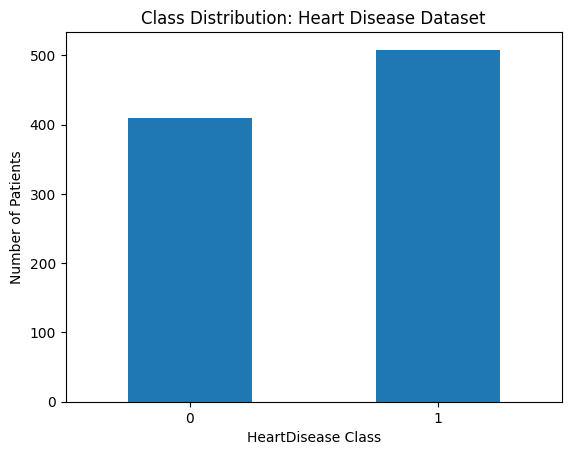

In [17]:
heart_df["HeartDisease"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Class Distribution: Heart Disease Dataset")
plt.xlabel("HeartDisease Class")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

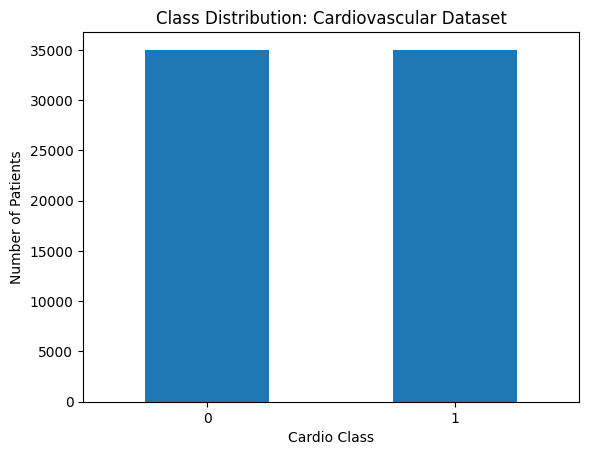

In [18]:
cardio_df["cardio"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Class Distribution: Cardiovascular Dataset")
plt.xlabel("Cardio Class")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

Inspect categorical values in heart dataset

In [19]:
heart_categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for column in heart_categorical_columns:
    print(f"\nColumn: {column}")
    print(heart_df[column].value_counts())


Column: Sex
Sex
M    725
F    193
Name: count, dtype: int64

Column: ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

Column: RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Column: ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

Column: ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


Inspect cardiovascular coded categories

In [20]:
cardio_categorical_columns = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

for column in cardio_categorical_columns:
    print(f"\nColumn: {column}")
    print(cardio_df[column].value_counts().sort_index())


Column: gender
gender
1    45530
2    24470
Name: count, dtype: int64

Column: cholesterol
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

Column: gluc
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

Column: smoke
smoke
0    63831
1     6169
Name: count, dtype: int64

Column: alco
alco
0    66236
1     3764
Name: count, dtype: int64

Column: active
active
0    13739
1    56261
Name: count, dtype: int64

Column: cardio
cardio
0    35021
1    34979
Name: count, dtype: int64


Numerical descriptive statistics

In [21]:
print("Heart dataset numerical summary:")
display(heart_df.describe().T)

print("\nCardiovascular dataset numerical summary:")
display(cardio_df.describe().T)

Heart dataset numerical summary:


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0



Cardiovascular dataset numerical summary:


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


Verify target validity

In [22]:
assert set(heart_df["HeartDisease"].unique()) == {0, 1}, \
    "HeartDisease target is not binary."

assert set(cardio_df["cardio"].unique()) == {0, 1}, \
    "Cardio target is not binary."

assert heart_df.shape[1] == 12, \
    "Unexpected number of columns in heart dataset."

assert cardio_df.shape[1] == 13, \
    "Unexpected number of columns in cardiovascular dataset."

print("Basic dataset validation passed.")

Basic dataset validation passed.


# Part 2: Feature Semantics and Data Quality Analysis

In this section, we:

1. classify the input variables,
2. identify clinically impossible or suspicious values,
3. distinguish invalid values from statistical outliers,
4. create cleaned working copies without introducing data leakage.

Create working copies

In [23]:
heart_clean = heart_df.copy()
cardio_work = cardio_df.copy()

print("Original heart shape:", heart_df.shape)
print("Working heart shape:", heart_clean.shape)

print("\nOriginal cardiovascular shape:", cardio_df.shape)
print("Working cardiovascular shape:", cardio_work.shape)

Original heart shape: (918, 12)
Working heart shape: (918, 12)

Original cardiovascular shape: (70000, 13)
Working cardiovascular shape: (70000, 13)


Define heart-dataset feature groups

In [24]:
heart_continuous = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

heart_binary = [
    "Sex",
    "FastingBS",
    "ExerciseAngina"
]

heart_nominal = [
    "ChestPainType",
    "RestingECG",
    "ST_Slope"
]

heart_target = "HeartDisease"

print("Continuous features:", heart_continuous)
print("Binary features:", heart_binary)
print("Nominal features:", heart_nominal)
print("Target:", heart_target)

Continuous features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Binary features: ['Sex', 'FastingBS', 'ExerciseAngina']
Nominal features: ['ChestPainType', 'RestingECG', 'ST_Slope']
Target: HeartDisease


Define cardiovascular feature groups

In [25]:
cardio_identifier = ["id"]

cardio_continuous = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

cardio_ordinal = [
    "cholesterol",
    "gluc"
]

cardio_binary = [
    "gender",
    "smoke",
    "alco",
    "active"
]

cardio_target = "cardio"

print("Identifier:", cardio_identifier)
print("Continuous features:", cardio_continuous)
print("Ordinal features:", cardio_ordinal)
print("Binary categorical features:", cardio_binary)
print("Target:", cardio_target)

Identifier: ['id']
Continuous features: ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
Ordinal features: ['cholesterol', 'gluc']
Binary categorical features: ['gender', 'smoke', 'alco', 'active']
Target: cardio


Verify that every feature was classified

In [26]:
heart_input_columns = set(heart_df.columns) - {heart_target}

classified_heart_columns = set(
    heart_continuous
    + heart_binary
    + heart_nominal
)

print("Unclassified heart features:")
print(heart_input_columns - classified_heart_columns)

print("\nIncorrectly listed heart features:")
print(classified_heart_columns - heart_input_columns)

assert heart_input_columns == classified_heart_columns
print("\nHeart feature classification passed.")

Unclassified heart features:
set()

Incorrectly listed heart features:
set()

Heart feature classification passed.


In [27]:
cardio_input_columns = set(cardio_df.columns) - {cardio_target}

classified_cardio_columns = set(
    cardio_identifier
    + cardio_continuous
    + cardio_ordinal
    + cardio_binary
)

print("Unclassified cardiovascular features:")
print(cardio_input_columns - classified_cardio_columns)

print("\nIncorrectly listed cardiovascular features:")
print(classified_cardio_columns - cardio_input_columns)

assert cardio_input_columns == classified_cardio_columns
print("\nCardiovascular feature classification passed.")

Unclassified cardiovascular features:
set()

Incorrectly listed cardiovascular features:
set()

Cardiovascular feature classification passed.


Investigate impossible zero values in the heart dataset

In [28]:
heart_zero_summary = pd.DataFrame({
    "Feature": [
        "RestingBP",
        "Cholesterol",
        "MaxHR"
    ],
    "Zero Count": [
        (heart_df["RestingBP"] == 0).sum(),
        (heart_df["Cholesterol"] == 0).sum(),
        (heart_df["MaxHR"] == 0).sum()
    ]
})

heart_zero_summary["Percentage"] = (
    heart_zero_summary["Zero Count"]
    / len(heart_df)
    * 100
)

display(heart_zero_summary)

,Feature,Zero Count,Percentage
0,RestingBP,1,0.108932
1,Cholesterol,172,18.736383
2,MaxHR,0,0.000000


Convert impossible zeros to missing values

In [29]:
heart_clean["RestingBP"] = (
    heart_clean["RestingBP"]
    .replace(0, np.nan)
)

heart_clean["Cholesterol"] = (
    heart_clean["Cholesterol"]
    .replace(0, np.nan)
)

print("Missing values after zero-value correction:")

display(
    heart_clean.isnull()
    .sum()
    .to_frame(name="Missing Count")
)

Missing values after zero-value correction:


,Missing Count
Age,0
Sex,0
ChestPainType,0
RestingBP,1
Cholesterol,172
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Validation cel

In [30]:
assert (heart_clean["RestingBP"] == 0).sum() == 0
assert (heart_clean["Cholesterol"] == 0).sum() == 0

assert heart_clean["RestingBP"].isnull().sum() == 1
assert heart_clean["Cholesterol"].isnull().sum() == 172

print("Impossible heart-dataset zero values were converted to NaN.")

Impossible heart-dataset zero values were converted to NaN.


Inspect negative Oldpeak observations

In [31]:
negative_oldpeak = heart_clean[
    heart_clean["Oldpeak"] < 0
]

print("Number of negative Oldpeak values:")
print(len(negative_oldpeak))

display(
    negative_oldpeak[
        [
            "Age",
            "Sex",
            "Oldpeak",
            "ST_Slope",
            "HeartDisease"
        ]
    ].head(10)
)

Number of negative Oldpeak values:
13


,Age,Sex,Oldpeak,ST_Slope,HeartDisease
321,63,M,-0.9,Flat,1
324,46,M,-2.6,Flat,1
325,42,M,-1.5,Down,1
326,45,M,-0.1,Up,0
331,56,M,-1.0,Up,1
332,38,M,-1.1,Up,0
334,51,M,-0.7,Up,1
335,62,M,-0.8,Flat,1
352,56,M,-1.0,Down,1
407,62,M,-0.5,Flat,1


Convert cardiovascular age from days to years

In [32]:
cardio_work["age_years"] = (
    cardio_work["age"] / 365.25
)

print("Minimum age in years:")
print(cardio_work["age_years"].min())

print("\nMaximum age in years:")
print(cardio_work["age_years"].max())

print("\nMean age in years:")
print(cardio_work["age_years"].mean())

Minimum age in years:
29.56331279945243

Maximum age in years:
64.92265571526352

Mean age in years:
53.3028495942114


Inspect extreme cardiovascular measurements

In [33]:
cardio_extreme_summary = (
    cardio_work[
        [
            "height",
            "weight",
            "ap_hi",
            "ap_lo"
        ]
    ]
    .agg(["min", "median", "max"])
    .T
)

display(cardio_extreme_summary)

,min,median,max
height,55.0,165.0,250.0
weight,10.0,72.0,200.0
ap_hi,-150.0,120.0,16020.0
ap_lo,-70.0,80.0,11000.0


Create rule masks

In [34]:
cardio_quality_rules = {
    "Height outside 120–220 cm": (
        (cardio_work["height"] < 120)
        | (cardio_work["height"] > 220)
    ),

    "Weight outside 30–200 kg": (
        (cardio_work["weight"] < 30)
        | (cardio_work["weight"] > 200)
    ),

    "Systolic BP outside 70–250": (
        (cardio_work["ap_hi"] < 70)
        | (cardio_work["ap_hi"] > 250)
    ),

    "Diastolic BP outside 40–150": (
        (cardio_work["ap_lo"] < 40)
        | (cardio_work["ap_lo"] > 150)
    ),

    "Systolic BP <= Diastolic BP": (
        cardio_work["ap_hi"]
        <= cardio_work["ap_lo"]
    )
}

In [35]:
cardio_quality_summary = pd.DataFrame({
    "Rule": list(cardio_quality_rules.keys()),
    "Affected Rows": [
        condition.sum()
        for condition in cardio_quality_rules.values()
    ]
})

cardio_quality_summary["Percentage"] = (
    cardio_quality_summary["Affected Rows"]
    / len(cardio_work)
    * 100
)

display(cardio_quality_summary)

,Rule,Affected Rows,Percentage
0,Height outside 120–220 cm,53,0.075714
1,Weight outside 30–200 kg,7,0.010000
2,Systolic BP outside 70–250,229,0.327143
3,Diastolic BP outside 40–150,1034,1.477143
4,Systolic BP <= Diastolic BP,1236,1.765714


Construct final validity mask

In [36]:
cardio_valid_mask = (
    cardio_work["height"].between(120, 220)
    & cardio_work["weight"].between(30, 200)
    & cardio_work["ap_hi"].between(70, 250)
    & cardio_work["ap_lo"].between(40, 150)
    & (cardio_work["ap_hi"] > cardio_work["ap_lo"])
)

valid_rows = cardio_valid_mask.sum()
invalid_rows = (~cardio_valid_mask).sum()

print("Valid rows:", valid_rows)
print("Invalid rows:", invalid_rows)

print(
    "Percentage removed:",
    invalid_rows / len(cardio_work) * 100
)

Valid rows: 68610
Invalid rows: 1390
Percentage removed: 1.9857142857142858


Create cleaned cardiovascular dataset

In [37]:
#Filter invalid rows
cardio_clean = (
    cardio_work
    .loc[cardio_valid_mask]
    .copy()
)

In [38]:
cardio_clean = cardio_clean.drop(
    columns=[
        "id",
        "age"
    ]
)

In [39]:
cardio_clean = cardio_clean[
    [
        "age_years",
        "gender",
        "height",
        "weight",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc",
        "smoke",
        "alco",
        "active",
        "cardio"
    ]
]

In [40]:
print("Clean cardiovascular shape:")
print(cardio_clean.shape)

display(cardio_clean.head())

Clean cardiovascular shape:
(68610, 12)


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.357290,2,168,62.0,110,80,1,1,0,0,1,0
1,55.381246,1,156,85.0,140,90,3,1,0,0,1,1
2,51.627652,1,165,64.0,130,70,3,1,0,0,0,1
3,48.249144,2,169,82.0,150,100,1,1,0,0,1,1
4,47.841205,1,156,56.0,100,60,1,1,0,0,0,0


Verify class distribution before and after cleaning

In [41]:
#Compare distributions
class_distribution_comparison = pd.DataFrame({
    "Before Cleaning": (
        cardio_df["cardio"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ),

    "After Cleaning": (
        cardio_clean["cardio"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )
})

class_distribution_comparison.index = [
    "Class 0",
    "Class 1"
]

display(class_distribution_comparison)

,Before Cleaning,After Cleaning
Class 0,50.03,50.530535
Class 1,49.97,49.469465


Investigate duplicates excluding patient ID

In [42]:
#Count duplicates without ID
cardio_duplicates_without_id = (
    cardio_df
    .drop(columns="id")
    .duplicated()
    .sum()
)

print(
    "Duplicate clinical rows excluding ID:",
    cardio_duplicates_without_id
)

Duplicate clinical rows excluding ID: 24


Create an IQR function

In [43]:
def calculate_iqr_summary(dataframe, columns):
    rows = []

    for column in columns:
        values = dataframe[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (values < lower_bound)
            | (values > upper_bound)
        ).sum()

        rows.append({
            "Feature": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": outlier_count
        })

    return pd.DataFrame(rows)

Heart-dataset IQR analysis

In [44]:
heart_iqr_summary = calculate_iqr_summary(
    heart_clean,
    heart_continuous
)

display(heart_iqr_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,47.00,60.0,13.00,27.500,79.500,0
1,RestingBP,120.00,140.0,20.00,90.000,170.000,27
2,Cholesterol,207.25,275.0,67.75,105.625,376.625,23
3,MaxHR,120.00,156.0,36.00,66.000,210.000,2
4,Oldpeak,0.00,1.5,1.50,-2.250,3.750,16


Cardiovascular IQR analysis

In [45]:
cardio_iqr_summary = calculate_iqr_summary(
    cardio_clean,
    [
        "age_years",
        "height",
        "weight",
        "ap_hi",
        "ap_lo"
    ]
)

display(cardio_iqr_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age_years,48.344969,58.38193,10.036961,33.289528,73.437372,4
1,height,159.000000,170.00000,11.000000,142.500000,186.500000,454
2,weight,65.000000,82.00000,17.000000,39.500000,107.500000,1732
3,ap_hi,120.000000,140.00000,20.000000,90.000000,170.000000,1003
4,ap_lo,80.000000,90.00000,10.000000,65.000000,105.000000,3493


Visualize distributions with boxplots

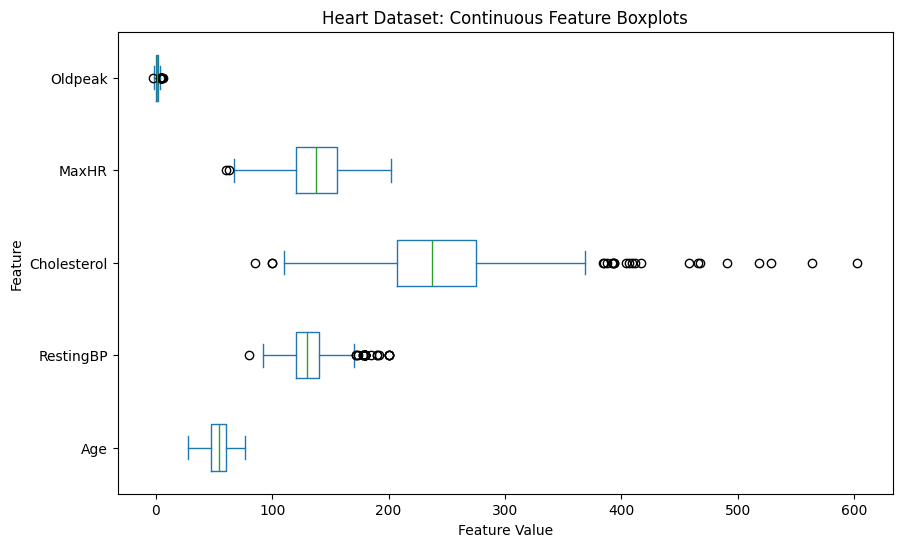

In [46]:
#Heart dataset
heart_clean[
    heart_continuous
].plot(
    kind="box",
    vert=False,
    figsize=(10, 6)
)

plt.title("Heart Dataset: Continuous Feature Boxplots")
plt.xlabel("Feature Value")
plt.ylabel("Feature")
plt.show()

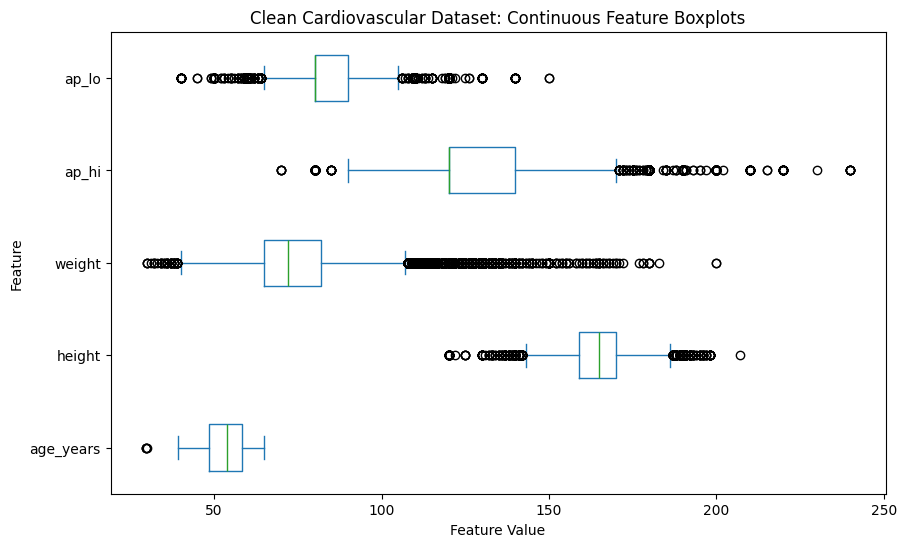

In [47]:
#Cardiovascular dataset
cardio_clean[
    [
        "age_years",
        "height",
        "weight",
        "ap_hi",
        "ap_lo"
    ]
].plot(
    kind="box",
    vert=False,
    figsize=(10, 6)
)

plt.title("Clean Cardiovascular Dataset: Continuous Feature Boxplots")
plt.xlabel("Feature Value")
plt.ylabel("Feature")
plt.show()

Final validation

In [48]:
#Validate cleaned datasets
assert heart_clean.shape[0] == 918
assert heart_clean["HeartDisease"].isnull().sum() == 0

assert cardio_clean.shape[0] == 68610
assert "id" not in cardio_clean.columns
assert "age" not in cardio_clean.columns
assert "age_years" in cardio_clean.columns

assert cardio_clean["height"].between(120, 220).all()
assert cardio_clean["weight"].between(30, 200).all()
assert cardio_clean["ap_hi"].between(70, 250).all()
assert cardio_clean["ap_lo"].between(40, 150).all()

assert (
    cardio_clean["ap_hi"]
    > cardio_clean["ap_lo"]
).all()

print("Part 2 data-quality validation passed.")

Part 2 data-quality validation passed.


Save Part 2 checkpoints

In [49]:
heart_stage2_path = os.path.join(
    DATA_FOLDER,
    "heart_stage2_clean.csv"
)

cardio_stage2_path = os.path.join(
    DATA_FOLDER,
    "cardio_stage2_clean.csv"
)

heart_clean.to_csv(
    heart_stage2_path,
    index=False
)

cardio_clean.to_csv(
    cardio_stage2_path,
    index=False
)

print("Saved:", heart_stage2_path)
print("Saved:", cardio_stage2_path)

Saved: /content/drive/MyDrive/Neural Network/heart_stage2_clean.csv
Saved: /content/drive/MyDrive/Neural Network/cardio_stage2_clean.csv


# Part 3: Leakage-Safe Data Preprocessing

This section performs:

1. feature-target separation,
2. stratified train-test splitting,
3. training-only median imputation,
4. one-hot encoding of categorical variables,
5. standardization of continuous variables,
6. validation of the transformed feature matrices.

Import preprocessing tools

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

Section A — Heart-Disease Dataset

In [51]:
#Separate features and target
X_heart = heart_clean.drop(
    columns="HeartDisease"
)

y_heart = heart_clean["HeartDisease"]

print("Heart feature matrix shape:", X_heart.shape)
print("Heart target shape:", y_heart.shape)


Heart feature matrix shape: (918, 11)
Heart target shape: (918,)


In [52]:
#input and target
display(X_heart.head())

print("Target values:")
print(y_heart.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up


Target values:
0    0
1    1
2    0
3    1
4    0
Name: HeartDisease, dtype: int64


Stratified train-test split

In [53]:
X_heart_train, X_heart_test, y_heart_train, y_heart_test = (
    train_test_split(
        X_heart,
        y_heart,
        test_size=0.20,
        random_state=42,
        stratify=y_heart
    )
)

print("Training feature shape:", X_heart_train.shape)
print("Test feature shape:", X_heart_test.shape)

print("Training target shape:", y_heart_train.shape)
print("Test target shape:", y_heart_test.shape)

Training feature shape: (734, 11)
Test feature shape: (184, 11)
Training target shape: (734,)
Test target shape: (184,)


In [54]:
#Verify stratification
heart_split_distribution = pd.DataFrame({
    "Full Dataset (%)": (
        y_heart.value_counts(normalize=True)
        .sort_index()
        * 100
    ),

    "Training Set (%)": (
        y_heart_train.value_counts(normalize=True)
        .sort_index()
        * 100
    ),

    "Test Set (%)": (
        y_heart_test.value_counts(normalize=True)
        .sort_index()
        * 100
    )
})

heart_split_distribution.index = [
    "Class 0",
    "Class 1"
]

display(heart_split_distribution)

,Full Dataset (%),Training Set (%),Test Set (%)
Class 0,44.662309,44.686649,44.565217
Class 1,55.337691,55.313351,55.434783


In [55]:
#Class counts
print("Training target counts:")
print(y_heart_train.value_counts().sort_index())

print("\nTest target counts:")
print(y_heart_test.value_counts().sort_index())

Training target counts:
HeartDisease
0    328
1    406
Name: count, dtype: int64

Test target counts:
HeartDisease
0     82
1    102
Name: count, dtype: int64


In [56]:
#Define heart feature groups
heart_numeric_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

heart_binary_numeric_features = [
    "FastingBS"
]

heart_categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [57]:
#Check coverage
all_heart_preprocessing_features = set(
    heart_numeric_features
    + heart_binary_numeric_features
    + heart_categorical_features
)

assert all_heart_preprocessing_features == set(X_heart.columns)

print("All heart-dataset features are included.")

All heart-dataset features are included.


In [58]:
#Build the numerical pipeline
heart_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [59]:
#Binary numerical pipeline
heart_binary_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        )
    ]
)

In [60]:
#Categorical pipeline
heart_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary",
                sparse_output=False
            )
        )
    ]
)

Combine transformations using ColumnTransformer

In [61]:
heart_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            heart_numeric_pipeline,
            heart_numeric_features
        ),

        (
            "binary_numeric",
            heart_binary_numeric_pipeline,
            heart_binary_numeric_features
        ),

        (
            "categorical",
            heart_categorical_pipeline,
            heart_categorical_features
        )
    ],

    remainder="drop",
    verbose_feature_names_out=False
)

In [62]:
#Fit only on training data
X_heart_train_processed = (
    heart_preprocessor.fit_transform(
        X_heart_train
    )
)

X_heart_test_processed = (
    heart_preprocessor.transform(
        X_heart_test
    )
)

In [63]:
#Check transformed dimensions
print(
    "Processed heart training shape:",
    X_heart_train_processed.shape
)

print(
    "Processed heart test shape:",
    X_heart_test_processed.shape
)

Processed heart training shape: (734, 18)
Processed heart test shape: (184, 18)


In [64]:
#Extract transformed feature names
heart_processed_feature_names = (
    heart_preprocessor.get_feature_names_out()
)

print("Number of processed features:")
print(len(heart_processed_feature_names))

print("\nProcessed feature names:")

for index, feature in enumerate(
    heart_processed_feature_names,
    start=1
):
    print(index, feature)

Number of processed features:
18

Processed feature names:
1 Age
2 RestingBP
3 Cholesterol
4 MaxHR
5 Oldpeak
6 FastingBS
7 Sex_M
8 ChestPainType_ASY
9 ChestPainType_ATA
10 ChestPainType_NAP
11 ChestPainType_TA
12 RestingECG_LVH
13 RestingECG_Normal
14 RestingECG_ST
15 ExerciseAngina_Y
16 ST_Slope_Down
17 ST_Slope_Flat
18 ST_Slope_Up


In [65]:
#Convert transformed data to DataFrames
X_heart_train_processed_df = pd.DataFrame(
    X_heart_train_processed,
    columns=heart_processed_feature_names,
    index=X_heart_train.index
)

X_heart_test_processed_df = pd.DataFrame(
    X_heart_test_processed,
    columns=heart_processed_feature_names,
    index=X_heart_test.index
)

display(X_heart_train_processed_df.head())

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,FastingBS,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,-0.517499,-0.324520,0.317046,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
486,0.122028,-1.266031,-0.572835,1.689837,-0.440356,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
117,0.546020,-0.159102,1.714383,-0.247045,0.601071,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
361,-0.725956,1.501291,-0.130147,-0.479470,-0.819056,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
296,-0.407962,0.671094,-0.130147,0.101594,-0.156330,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [66]:
#Validate processed heart data
print(
    "Missing values in processed training data:",
    np.isnan(X_heart_train_processed).sum()
)

print(
    "Missing values in processed test data:",
    np.isnan(X_heart_test_processed).sum()
)

print(
    "All training values finite:",
    np.isfinite(X_heart_train_processed).all()
)

print(
    "All test values finite:",
    np.isfinite(X_heart_test_processed).all()
)

Missing values in processed training data: 0
Missing values in processed test data: 0
All training values finite: True
All test values finite: True


In [67]:
#Validate standardization
heart_scaled_training = (
    X_heart_train_processed_df[
        heart_numeric_features
    ]
)

heart_scaling_check = pd.DataFrame({
    "Mean": heart_scaled_training.mean(),
    "Standard Deviation": (
        heart_scaled_training.std(ddof=0)
    )
})

display(heart_scaling_check)

,Mean,Standard Deviation
Age,1.647184e-16,1.0
RestingBP,-6.681001e-16,1.0
Cholesterol,2.418592e-16,1.0
MaxHR,-1.095097e-16,1.0
Oldpeak,1.016444e-16,1.0


Section B — Cardiovascular Dataset

In [68]:
#Separate features and target
X_cardio = cardio_clean.drop(
    columns="cardio"
)

y_cardio = cardio_clean["cardio"]

print("Cardiovascular feature shape:", X_cardio.shape)
print("Cardiovascular target shape:", y_cardio.shape)

Cardiovascular feature shape: (68610, 11)
Cardiovascular target shape: (68610,)


In [69]:
#Stratified cardiovascular split
X_cardio_train, X_cardio_test, y_cardio_train, y_cardio_test = (
    train_test_split(
        X_cardio,
        y_cardio,
        test_size=0.20,
        random_state=42,
        stratify=y_cardio
    )
)

print("Training feature shape:", X_cardio_train.shape)
print("Test feature shape:", X_cardio_test.shape)

print("Training target shape:", y_cardio_train.shape)
print("Test target shape:", y_cardio_test.shape)

Training feature shape: (54888, 11)
Test feature shape: (13722, 11)
Training target shape: (54888,)
Test target shape: (13722,)


In [70]:
#Define cardiovascular feature groups
cardio_continuous_features = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

cardio_categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

In [71]:
#Build cardiovascular preprocessing
cardio_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

cardio_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary",
                sparse_output=False
            )
        )
    ]
)

In [72]:
#Combine pipelines
cardio_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            cardio_numeric_pipeline,
            cardio_continuous_features
        ),

        (
            "categorical",
            cardio_categorical_pipeline,
            cardio_categorical_features
        )
    ],

    remainder="drop",
    verbose_feature_names_out=False
)

In [73]:
#Fit on cardiovascular training data
X_cardio_train_processed = (
    cardio_preprocessor.fit_transform(
        X_cardio_train
    )
)

X_cardio_test_processed = (
    cardio_preprocessor.transform(
        X_cardio_test
    )
)

print(
    "Processed cardiovascular training shape:",
    X_cardio_train_processed.shape
)

print(
    "Processed cardiovascular test shape:",
    X_cardio_test_processed.shape
)

Processed cardiovascular training shape: (54888, 15)
Processed cardiovascular test shape: (13722, 15)


In [74]:
#Cardiovascular transformed feature names
cardio_processed_feature_names = (
    cardio_preprocessor.get_feature_names_out()
)

for index, feature in enumerate(
    cardio_processed_feature_names,
    start=1
):
    print(index, feature)

1 age_years
2 height
3 weight
4 ap_hi
5 ap_lo
6 gender_2
7 cholesterol_1
8 cholesterol_2
9 cholesterol_3
10 gluc_1
11 gluc_2
12 gluc_3
13 smoke_1
14 alco_1
15 active_1


In [75]:
#cardio_processed_feature_names = (
X_cardio_train_processed_df = pd.DataFrame(
    X_cardio_train_processed,
    columns=cardio_processed_feature_names,
    index=X_cardio_train.index
)

X_cardio_test_processed_df = pd.DataFrame(
    X_cardio_test_processed,
    columns=cardio_processed_feature_names,
    index=X_cardio_test.index
)

display(X_cardio_train_processed_df.head())

,age_years,height,weight,ap_hi,ap_lo,gender_2,cholesterol_1,cholesterol_2,cholesterol_3,gluc_1,gluc_2,gluc_3,smoke_1,alco_1,active_1
42478,1.285672,-0.306346,-0.918441,0.202074,0.395390,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
9097,0.996048,-0.053276,-0.289804,-1.593777,-1.193954,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2848,0.327684,0.199793,0.618227,-0.396543,-0.134391,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
52172,-1.706571,0.705933,-0.289804,-0.995160,-1.193954,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
511,1.051947,0.579398,-0.848592,-0.396543,-0.134391,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [76]:
#Final validation
assert X_heart_train_processed.shape == (734, 18)
assert X_heart_test_processed.shape == (184, 18)

assert X_cardio_train_processed.shape == (54888, 15)
assert X_cardio_test_processed.shape == (13722, 15)

assert np.isfinite(
    X_heart_train_processed
).all()

assert np.isfinite(
    X_heart_test_processed
).all()

assert np.isfinite(
    X_cardio_train_processed
).all()

assert np.isfinite(
    X_cardio_test_processed
).all()

assert set(y_heart_train.unique()) == {0, 1}
assert set(y_heart_test.unique()) == {0, 1}

assert set(y_cardio_train.unique()) == {0, 1}
assert set(y_cardio_test.unique()) == {0, 1}

print("Part 3 preprocessing validation passed.")

Part 3 preprocessing validation passed.


# Part 4A: Decision Tree Baseline on the Heart-Disease Dataset

This section trains a full-feature decision-tree classifier and evaluates:

1. training and test performance,
2. confusion matrix,
3. accuracy, precision, sensitivity, specificity, F1-score,
4. ROC-AUC and average precision,
5. tree complexity and overfitting,
6. impurity-based feature importance.

In [77]:
#Import Decision Tree tools
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [78]:
required_objects = [
    "X_heart_train",
    "X_heart_test",
    "y_heart_train",
    "y_heart_test",
    "heart_preprocessor"
]

for object_name in required_objects:
    assert object_name in globals(), (
        f"{object_name} is missing. "
        "Run Part 3 before running Part 4."
    )

print("All required Part 3 objects are available.")

All required Part 3 objects are available.


In [79]:
#Build the complete model pipeline
heart_dt_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            heart_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                random_state=42
            )
        )
    ]
)

print(heart_dt_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak']),
                                                 ('binary_numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['FastingBS']),
                            

In [80]:
#Train the Decision Tree
heart_dt_pipeline.fit(
    X_heart_train,
    y_heart_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [81]:
#Generate predictions
y_heart_train_pred_dt = heart_dt_pipeline.predict(
    X_heart_train
)

y_heart_test_pred_dt = heart_dt_pipeline.predict(
    X_heart_test
)

y_heart_test_prob_dt = (
    heart_dt_pipeline.predict_proba(
        X_heart_test
    )[:, 1]
)

print("First 10 predicted classes:")
print(y_heart_test_pred_dt[:10])

print("\nFirst 10 predicted probabilities:")
print(y_heart_test_prob_dt[:10])

First 10 predicted classes:
[1 1 1 0 1 1 0 1 0 1]

First 10 predicted probabilities:
[1. 1. 1. 0. 1. 1. 0. 1. 0. 1.]


In [82]:
#Compare training and test accuracy
heart_train_accuracy_dt = accuracy_score(
    y_heart_train,
    y_heart_train_pred_dt
)

heart_test_accuracy_dt = accuracy_score(
    y_heart_test,
    y_heart_test_pred_dt
)

heart_generalization_gap_dt = (
    heart_train_accuracy_dt
    - heart_test_accuracy_dt
)

print(
    "Training accuracy:",
    round(heart_train_accuracy_dt, 4)
)

print(
    "Test accuracy:",
    round(heart_test_accuracy_dt, 4)
)

print(
    "Generalization gap:",
    round(heart_generalization_gap_dt, 4)
)

Training accuracy: 1.0
Test accuracy: 0.7826
Generalization gap: 0.2174


In [83]:
#Inspect tree complexity
fitted_heart_tree = (
    heart_dt_pipeline
    .named_steps["classifier"]
)

heart_tree_depth = fitted_heart_tree.get_depth()
heart_tree_leaves = fitted_heart_tree.get_n_leaves()

print("Tree depth:", heart_tree_depth)
print("Number of leaves:", heart_tree_leaves)

Tree depth: 12
Number of leaves: 109


Confusion matrix

In [84]:
heart_confusion_matrix_dt = confusion_matrix(
    y_heart_test,
    y_heart_test_pred_dt
)

print("Confusion Matrix:")
print(heart_confusion_matrix_dt)

Confusion Matrix:
[[64 18]
 [22 80]]


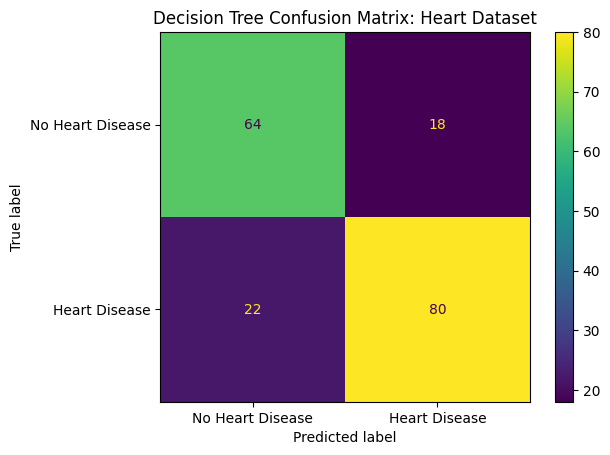

In [85]:
#confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_heart_test,
    y_heart_test_pred_dt,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title(
    "Decision Tree Confusion Matrix: Heart Dataset"
)

plt.show()

Rows represent the actual classes and columns represent predicted classes. The most clinically concerning errors are false negatives, because these are patients with heart disease whom the model predicts as disease-free

Calculate evaluation metrics

In [86]:
#Create a reusable function
def evaluate_binary_classifier(
    y_true,
    y_pred,
    y_probability
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    metrics = {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Sensitivity / Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Specificity": specificity,

        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability
        ),

        "Average Precision": average_precision_score(
            y_true,
            y_probability
        ),

        "MCC": matthews_corrcoef(
            y_true,
            y_pred
        )
    }

    return pd.DataFrame(
        metrics.items(),
        columns=[
            "Metric",
            "Value"
        ]
    )

In [87]:
#Evaluate the heart model
heart_dt_metrics = evaluate_binary_classifier(
    y_true=y_heart_test,
    y_pred=y_heart_test_pred_dt,
    y_probability=y_heart_test_prob_dt
)

heart_dt_metrics["Value"] = (
    heart_dt_metrics["Value"]
    .round(4)
)

display(heart_dt_metrics)

,Metric,Value
0,Accuracy,0.7826
1,Precision,0.8163
2,Sensitivity / Recall,0.7843
3,Specificity,0.7805
4,F1-score,0.8000
5,Balanced Accuracy,0.7824
6,ROC-AUC,0.7824
7,Average Precision,0.7598
8,MCC,0.5627


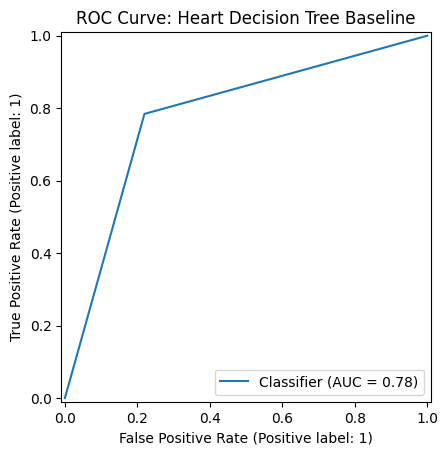

In [88]:
#ROC curve
RocCurveDisplay.from_predictions(
    y_heart_test,
    y_heart_test_prob_dt
)

plt.title(
    "ROC Curve: Heart Decision Tree Baseline"
)

plt.show()

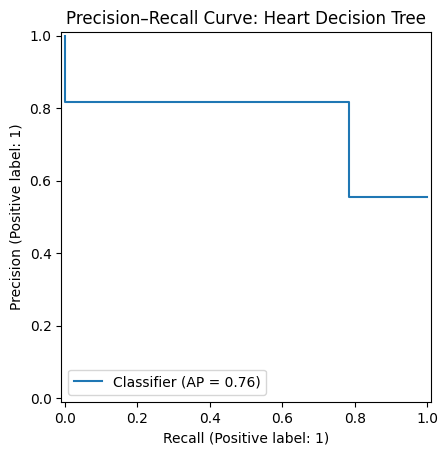

In [89]:
#Precision–Recall curve
PrecisionRecallDisplay.from_predictions(
    y_heart_test,
    y_heart_test_prob_dt
)

plt.title(
    "Precision–Recall Curve: Heart Decision Tree"
)

plt.show()


In [91]:
#Create feature-importance table
heart_dt_importance = pd.DataFrame({
    "Feature": heart_dt_feature_names,
    "Importance": (
        fitted_heart_tree
        .feature_importances_
    )
})

heart_dt_importance = (
    heart_dt_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    heart_dt_importance.head(10)
)

,Feature,Importance
0,ST_Slope_Up,0.421219
1,MaxHR,0.108385
2,Oldpeak,0.095718
3,ChestPainType_ASY,0.087742
4,Age,0.077163
5,Cholesterol,0.069190
6,RestingBP,0.057773
7,Sex_M,0.022104
8,ST_Slope_Flat,0.013829
9,RestingECG_Normal,0.013571


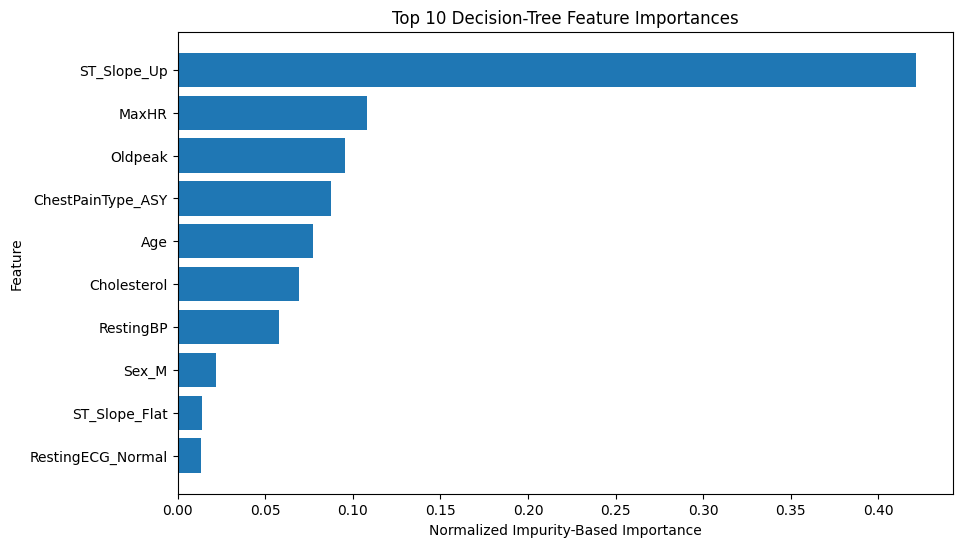

In [92]:
#Plot top feature importances
top_heart_dt_features = (
    heart_dt_importance
    .head(10)
    .sort_values(
        by="Importance"
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_heart_dt_features["Feature"],
    top_heart_dt_features["Importance"]
)

plt.title(
    "Top 10 Decision-Tree Feature Importances"
)

plt.xlabel(
    "Normalized Impurity-Based Importance"
)

plt.ylabel("Feature")

plt.show()

In [93]:
#Save baseline results
heart_dt_metrics.to_csv(
    os.path.join(
        DATA_FOLDER,
        "heart_decision_tree_metrics.csv"
    ),
    index=False
)

heart_dt_importance.to_csv(
    os.path.join(
        DATA_FOLDER,
        "heart_decision_tree_feature_importance.csv"
    ),
    index=False
)

print(
    "Decision-tree results saved successfully."
)

Decision-tree results saved successfully.


In [94]:
#Final validation
assert (
    len(y_heart_test_pred_dt)
    == len(y_heart_test)
)

assert (
    len(y_heart_test_prob_dt)
    == len(y_heart_test)
)

assert set(
    np.unique(y_heart_test_pred_dt)
).issubset({0, 1})

assert np.all(
    y_heart_test_prob_dt >= 0
)

assert np.all(
    y_heart_test_prob_dt <= 1
)

assert (
    heart_confusion_matrix_dt.sum()
    == len(y_heart_test)
)

assert np.isclose(
    fitted_heart_tree
    .feature_importances_
    .sum(),
    1.0
)

print(
    "Part 4A Decision Tree validation passed."
)

Part 4A Decision Tree validation passed.


# Part 4: Full-Feature MLP Baseline

This section develops a standard multilayer perceptron using all heart-disease features.

The training data is divided into development and validation subsets. The untouched test set is reserved for final evaluation after the architecture and training procedure have been fixed.

In [95]:
#Import TensorFlow and supporting tools

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.base import clone
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [96]:
#Set random seeds
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds set to:", SEED)

Random seeds set to: 42


In [97]:
#Verify required variables
required_variables = [
    "X_heart_train",
    "X_heart_test",
    "y_heart_train",
    "y_heart_test",
    "heart_preprocessor"
]

for variable_name in required_variables:
    assert variable_name in globals(), (
        f"{variable_name} is missing. "
        "Run the heart-dataset portion of Part 3 first."
    )

print("All required heart-dataset objects are available.")

All required heart-dataset objects are available.


In [98]:
#Create development and validation sets
(
    X_heart_dev,
    X_heart_val,
    y_heart_dev,
    y_heart_val
) = train_test_split(
    X_heart_train,
    y_heart_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_heart_train
)

print("Development features:", X_heart_dev.shape)
print("Validation features:", X_heart_val.shape)
print("Test features:", X_heart_test.shape)

print("\nDevelopment targets:", y_heart_dev.shape)
print("Validation targets:", y_heart_val.shape)
print("Test targets:", y_heart_test.shape)

Development features: (587, 11)
Validation features: (147, 11)
Test features: (184, 11)

Development targets: (587,)
Validation targets: (147,)
Test targets: (184,)


In [99]:
#Check class balance
mlp_split_distribution = pd.DataFrame({
    "Development (%)": (
        y_heart_dev
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),

    "Validation (%)": (
        y_heart_val
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),

    "Test (%)": (
        y_heart_test
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
})

mlp_split_distribution.index = [
    "Class 0",
    "Class 1"
]

display(mlp_split_distribution)

,Development (%),Validation (%),Test (%)
Class 0,44.633731,44.897959,44.565217
Class 1,55.366269,55.102041,55.434783


In [100]:
#Create an independent MLP preprocessor
mlp_preprocessor = clone(
    heart_preprocessor
)

X_heart_dev_processed = (
    mlp_preprocessor.fit_transform(
        X_heart_dev
    )
)

X_heart_val_processed = (
    mlp_preprocessor.transform(
        X_heart_val
    )
)

X_heart_test_processed_mlp = (
    mlp_preprocessor.transform(
        X_heart_test
    )
)

print(
    "Processed development shape:",
    X_heart_dev_processed.shape
)

print(
    "Processed validation shape:",
    X_heart_val_processed.shape
)

print(
    "Processed test shape:",
    X_heart_test_processed_mlp.shape
)

Processed development shape: (587, 18)
Processed validation shape: (147, 18)
Processed test shape: (184, 18)


In [101]:
#Validate processed data
assert (
    X_heart_dev_processed.shape[1]
    == X_heart_val_processed.shape[1]
    == X_heart_test_processed_mlp.shape[1]
)

assert np.isfinite(
    X_heart_dev_processed
).all()

assert np.isfinite(
    X_heart_val_processed
).all()

assert np.isfinite(
    X_heart_test_processed_mlp
).all()

print("Processed MLP inputs contain no NaN or infinite values.")

Processed MLP inputs contain no NaN or infinite values.


In [102]:
#Convert arrays to float32
X_heart_dev_processed = (
    X_heart_dev_processed.astype("float32")
)

X_heart_val_processed = (
    X_heart_val_processed.astype("float32")
)

X_heart_test_processed_mlp = (
    X_heart_test_processed_mlp.astype("float32")
)

y_heart_dev_array = (
    y_heart_dev
    .to_numpy()
    .astype("float32")
)

y_heart_val_array = (
    y_heart_val
    .to_numpy()
    .astype("float32")
)

y_heart_test_array = (
    y_heart_test
    .to_numpy()
    .astype("float32")
)

print("Input dtype:", X_heart_dev_processed.dtype)
print("Target dtype:", y_heart_dev_array.dtype)

Input dtype: float32
Target dtype: float32


In [103]:
#Create a model-building function
def build_full_feature_mlp(input_dimension):
    model = keras.Sequential(
        [
            keras.Input(
                shape=(input_dimension,),
                name="clinical_features"
            ),

            layers.Dense(
                units=16,
                activation="relu",
                name="hidden_layer_1"
            ),

            layers.Dropout(
                rate=0.20,
                name="dropout_layer"
            ),

            layers.Dense(
                units=8,
                activation="relu",
                name="hidden_layer_2"
            ),

            layers.Dense(
                units=1,
                activation="sigmoid",
                name="heart_disease_probability"
            )
        ],
        name="full_feature_mlp"
    )

    return model

In [104]:
#Build the model
input_dimension = (
    X_heart_dev_processed.shape[1]
)

full_feature_mlp = build_full_feature_mlp(
    input_dimension=input_dimension
)

print("Input dimension:", input_dimension)

full_feature_mlp.summary()

Input dimension: 18


Model: "full_feature_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ heart_disease_probability       │ (None, 1)              │             9 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
#Compile the model
full_feature_mlp.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.AUC(
            name="auc"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        )
    ]
)

print("Model compilation completed.")

Model compilation completed.


In [106]:
#Configure Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

In [107]:
#Train the MLP
history = full_feature_mlp.fit(
    X_heart_dev_processed,
    y_heart_dev_array,

    validation_data=(
        X_heart_val_processed,
        y_heart_val_array
    ),

    epochs=300,
    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5009 - auc: 0.5291 - loss: 0.7416 - precision: 0.6509 - recall: 0.2123 - val_accuracy: 0.5714 - val_auc: 0.6283 - val_loss: 0.6883 - val_precision: 0.6957 - val_recall: 0.3951
Epoch 2/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6303 - auc: 0.7097 - loss: 0.6524 - precision: 0.7308 - recall: 0.5262 - val_accuracy: 0.6871 - val_auc: 0.7176 - val_loss: 0.6460 - val_precision: 0.7215 - val_recall: 0.7037
Epoch 3/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7206 - auc: 0.7670 - loss: 0.6142 - precision: 0.7477 - recall: 0.7477 - val_accuracy: 0.7007 - val_auc: 0.7552 - val_loss: 0.6141 - val_precision: 0.7033 - val_recall: 0.7901
Epoch 4/300
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7359 - auc: 0.8036 - loss: 0.5816 - precision: 0.7335 - recall: 0.8215 - val_accuracy: 0.7415 - val_auc: 0.7889 - val_loss: 0.5868 - val_precision: 0.7363 - val_recall: 0.8272
Epoch 5/300
19/19 ━━━━━━━━━━━━━━━━━

In [108]:
#Inspect training history
history_keys = list(
    history.history.keys()
)

epochs_completed = len(
    history.history["loss"]
)

best_epoch = (
    np.argmin(
        history.history["val_loss"]
    )
    + 1
)

best_validation_loss = np.min(
    history.history["val_loss"]
)

print("Recorded history values:")
print(history_keys)

print("\nEpochs completed:")
print(epochs_completed)

print("\nBest epoch based on validation loss:")
print(best_epoch)

print("\nBest validation loss:")
print(round(best_validation_loss, 4))

Recorded history values:
['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall']

Epochs completed:
95

Best epoch based on validation loss:
75

Best validation loss:
0.4052


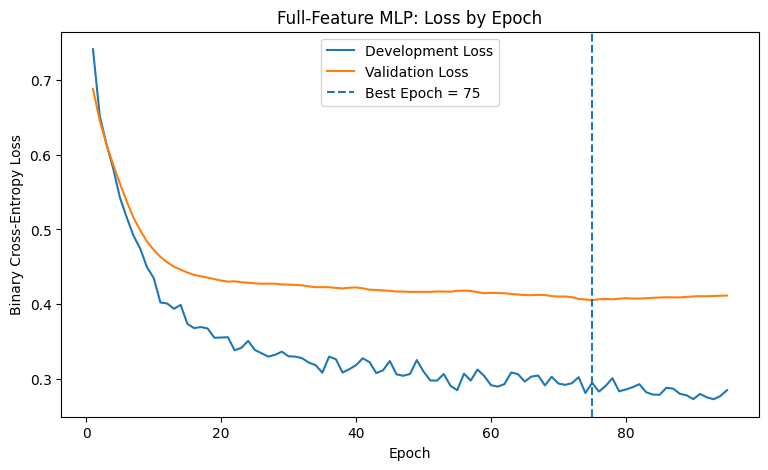

In [109]:
#Plot training and validation loss
training_epochs = range(
    1,
    epochs_completed + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    training_epochs,
    history.history["loss"],
    label="Development Loss"
)

plt.plot(
    training_epochs,
    history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.title("Full-Feature MLP: Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

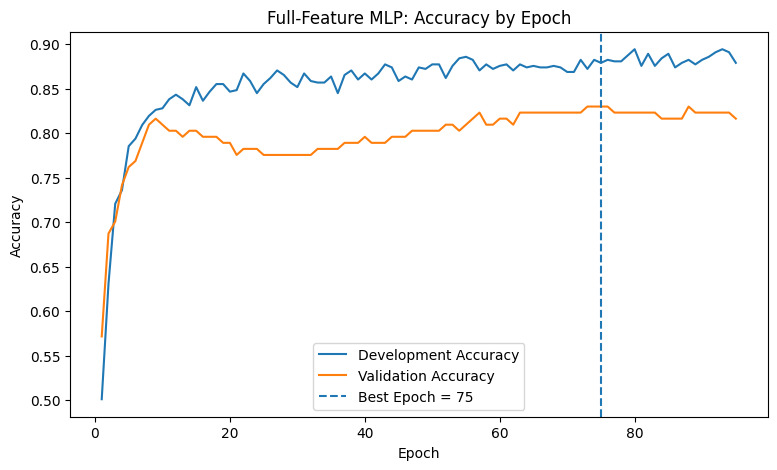

In [110]:
#Plot accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    training_epochs,
    history.history["accuracy"],
    label="Development Accuracy"
)

plt.plot(
    training_epochs,
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.title("Full-Feature MLP: Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [111]:
#Essential validation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predict heart-disease probabilities
y_val_prob = full_feature_mlp.predict(
    X_heart_val_processed,
    verbose=0
).ravel()

# Convert probabilities to class labels
y_val_pred = (
    y_val_prob >= 0.50
).astype(int)

print(
    "Validation Accuracy:",
    round(
        accuracy_score(
            y_heart_val_array,
            y_val_pred
        ),
        4
    )
)

print(
    "Validation Precision:",
    round(
        precision_score(
            y_heart_val_array,
            y_val_pred
        ),
        4
    )
)

print(
    "Validation Recall:",
    round(
        recall_score(
            y_heart_val_array,
            y_val_pred
        ),
        4
    )
)

print(
    "Validation F1-score:",
    round(
        f1_score(
            y_heart_val_array,
            y_val_pred
        ),
        4
    )
)

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            y_heart_val_array,
            y_val_prob
        ),
        4
    )
)

Validation Accuracy: 0.8299
Validation Precision: 0.8415
Validation Recall: 0.8519
Validation F1-score: 0.8466
Validation ROC-AUC: 0.9012


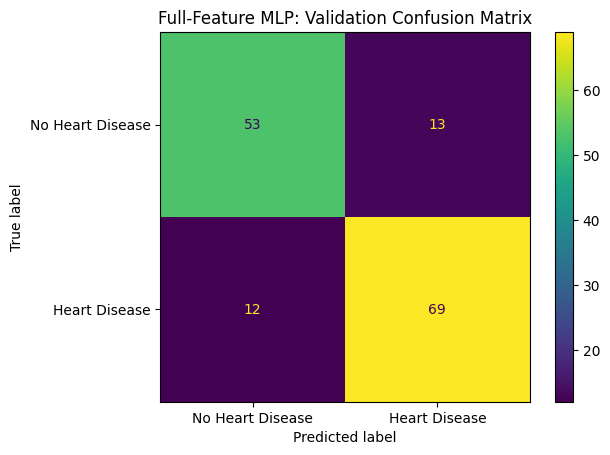

In [112]:
#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_heart_val_array.astype(int),
    y_val_pred,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title(
    "Full-Feature MLP: Validation Confusion Matrix"
)

plt.show()

# Part 5: Manual Perspective-Based MLP

The original clinical features are manually divided into four interpretable perspectives. A separate lightweight MLP is trained for each perspective, and their predicted probabilities are combined using equal-weight averaging.

In [113]:
#Define the perspectives
manual_perspectives = {
    "Demographic": [
        "Age",
        "Sex"
    ],

    "Symptoms": [
        "ChestPainType",
        "ExerciseAngina"
    ],

    "Resting_Clinical": [
        "RestingBP",
        "Cholesterol",
        "FastingBS",
        "RestingECG"
    ],

    "Exercise_ECG": [
        "MaxHR",
        "Oldpeak",
        "ST_Slope"
    ]
}

for perspective_name, features in manual_perspectives.items():
    print(f"{perspective_name}:")
    print(features)
    print()

Demographic:
['Age', 'Sex']

Symptoms:
['ChestPainType', 'ExerciseAngina']

Resting_Clinical:
['RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG']

Exercise_ECG:
['MaxHR', 'Oldpeak', 'ST_Slope']



In [114]:
#Validate the perspective assignment
all_perspective_features = []

for feature_list in manual_perspectives.values():
    all_perspective_features.extend(feature_list)

print(
    "Number of assigned features:",
    len(all_perspective_features)
)

print(
    "Number of unique assigned features:",
    len(set(all_perspective_features))
)

print(
    "Original input features:",
    X_heart_dev.shape[1]
)

assert len(all_perspective_features) == 11

assert len(set(all_perspective_features)) == 11

assert set(all_perspective_features) == set(
    X_heart_dev.columns
)

assert "HeartDisease" not in all_perspective_features

print("Manual perspective validation passed.")

Number of assigned features: 11
Number of unique assigned features: 11
Original input features: 11
Manual perspective validation passed.


Build perspective-specific preprocessing

In [115]:
#Required imports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [116]:
#One-hot encoder compatibility function
def create_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
            sparse_output=False
        )

    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
            sparse=False
        )

In [117]:
#Perspective preprocessor function
def build_perspective_preprocessor(feature_list):
    numerical_features = [
        feature
        for feature in feature_list
        if feature in heart_numeric_features
    ]

    binary_numerical_features = [
        feature
        for feature in feature_list
        if feature in heart_binary_numeric_features
    ]

    categorical_features = [
        feature
        for feature in feature_list
        if feature in heart_categorical_features
    ]

    transformers = []

    if len(numerical_features) > 0:
        numerical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]
        )

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_features
            )
        )

    if len(binary_numerical_features) > 0:
        binary_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                )
            ]
        )

        transformers.append(
            (
                "binary",
                binary_pipeline,
                binary_numerical_features
            )
        )

    if len(categorical_features) > 0:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    create_one_hot_encoder()
                )
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )

    return preprocessor

In [118]:
#Build the perspective-specific MLP
def build_perspective_mlp(
    input_dimension,
    perspective_name
):
    model = keras.Sequential(
        [
            keras.Input(
                shape=(input_dimension,),
                name=f"{perspective_name}_input"
            ),

            layers.Dense(
                units=8,
                activation="relu",
                name=f"{perspective_name}_hidden_1"
            ),

            layers.Dropout(
                rate=0.15,
                name=f"{perspective_name}_dropout"
            ),

            layers.Dense(
                units=4,
                activation="relu",
                name=f"{perspective_name}_hidden_2"
            ),

            layers.Dense(
                units=1,
                activation="sigmoid",
                name=f"{perspective_name}_output"
            )
        ],

        name=f"{perspective_name}_mlp"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss=keras.losses.BinaryCrossentropy(),

        metrics=[
            keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),

            keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    return model

In [119]:
#Train all perspective models
perspective_models = {}
perspective_preprocessors = {}
perspective_histories = {}
perspective_validation_probabilities = {}

perspective_results = []

for perspective_index, (
    perspective_name,
    perspective_features
) in enumerate(
    manual_perspectives.items()
):

    print("=" * 60)
    print("Training perspective:", perspective_name)
    print("Features:", perspective_features)

    # Build a separate preprocessor
    perspective_preprocessor = (
        build_perspective_preprocessor(
            perspective_features
        )
    )

    # Fit only on development data
    X_dev_perspective = (
        perspective_preprocessor.fit_transform(
            X_heart_dev[
                perspective_features
            ]
        )
        .astype("float32")
    )

    # Validation data is transformed only
    X_val_perspective = (
        perspective_preprocessor.transform(
            X_heart_val[
                perspective_features
            ]
        )
        .astype("float32")
    )

    input_dimension = (
        X_dev_perspective.shape[1]
    )

    print(
        "Processed input dimension:",
        input_dimension
    )

    # Set a reproducible seed
    keras.utils.set_random_seed(
        SEED + perspective_index
    )

    # Build the perspective MLP
    perspective_model = (
        build_perspective_mlp(
            input_dimension=input_dimension,
            perspective_name=perspective_name
        )
    )

    perspective_early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=20,
            restore_best_weights=True,
            verbose=0
        )
    )

    # Train the MLP
    perspective_history = (
        perspective_model.fit(
            X_dev_perspective,
            y_heart_dev_array,

            validation_data=(
                X_val_perspective,
                y_heart_val_array
            ),

            epochs=250,
            batch_size=32,

            callbacks=[
                perspective_early_stopping
            ],

            verbose=0
        )
    )

    # Validation probabilities
    validation_probabilities = (
        perspective_model.predict(
            X_val_perspective,
            verbose=0
        )
        .ravel()
    )

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)

    best_epoch = (
        np.argmin(
            perspective_history.history[
                "val_loss"
            ]
        )
        + 1
    )

    validation_accuracy = accuracy_score(
        y_heart_val_array,
        validation_predictions
    )

    validation_auc = roc_auc_score(
        y_heart_val_array,
        validation_probabilities
    )

    perspective_preprocessors[
        perspective_name
    ] = perspective_preprocessor

    perspective_models[
        perspective_name
    ] = perspective_model

    perspective_histories[
        perspective_name
    ] = perspective_history

    perspective_validation_probabilities[
        perspective_name
    ] = validation_probabilities

    perspective_results.append(
        {
            "Perspective": perspective_name,
            "Original Features": len(
                perspective_features
            ),
            "Processed Features": input_dimension,
            "Best Epoch": best_epoch,
            "Validation Accuracy": validation_accuracy,
            "Validation ROC-AUC": validation_auc
        }
    )

    print("Best epoch:", best_epoch)

    print(
        "Validation accuracy:",
        round(validation_accuracy, 4)
    )

    print(
        "Validation ROC-AUC:",
        round(validation_auc, 4)
    )

Training perspective: Demographic
Features: ['Age', 'Sex']
Processed input dimension: 2
Best epoch: 212
Validation accuracy: 0.6327
Validation ROC-AUC: 0.6903
Training perspective: Symptoms
Features: ['ChestPainType', 'ExerciseAngina']
Processed input dimension: 5


Best epoch: 118
Validation accuracy: 0.7755
Validation ROC-AUC: 0.8378
Training perspective: Resting_Clinical
Features: ['RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG']
Processed input dimension: 6
Best epoch: 89
Validation accuracy: 0.6259
Validation ROC-AUC: 0.645
Training perspective: Exercise_ECG
Features: ['MaxHR', 'Oldpeak', 'ST_Slope']
Processed input dimension: 5
Best epoch: 142
Validation accuracy: 0.8163
Validation ROC-AUC: 0.8716


In [120]:
#Display the perspective results
perspective_results_df = pd.DataFrame(
    perspective_results
)

display(
    perspective_results_df.round(4)
)

,Perspective,Original Features,Processed Features,Best Epoch,Validation Accuracy,Validation ROC-AUC
0,Demographic,2,2,212,0.6327,0.6903
1,Symptoms,2,5,118,0.7755,0.8378
2,Resting_Clinical,4,6,89,0.6259,0.6450
3,Exercise_ECG,3,5,142,0.8163,0.8716


In [121]:
#Construct the probability matrix
manual_validation_probability_matrix = pd.DataFrame(
    perspective_validation_probabilities,
    index=X_heart_val.index
)

display(
    manual_validation_probability_matrix.head()
)

,Demographic,Symptoms,Resting_Clinical,Exercise_ECG
192,0.553254,0.157332,0.489629,0.197065
167,0.553254,0.157332,0.479183,0.191702
825,0.671270,0.353989,0.517292,0.645795
36,0.719931,0.868284,0.741348,0.942389
744,0.679679,0.868284,0.743244,0.217365


In [122]:
#Equal-weight average fusion
manual_average_validation_probability = (
    manual_validation_probability_matrix
    .mean(axis=1)
    .to_numpy()
)

manual_average_validation_prediction = (
    manual_average_validation_probability
    >= 0.50
).astype(int)

print(
    "First 10 fused probabilities:"
)

print(
    np.round(
        manual_average_validation_probability[:10],
        4
    )
)

print(
    "\nFirst 10 fused predictions:"
)

print(
    manual_average_validation_prediction[:10]
)

First 10 fused probabilities:
[0.3493 0.3454 0.5471 0.818  0.6271 0.5046 0.5009 0.7456 0.752  0.6262]

First 10 fused predictions:
[0 0 1 1 1 1 1 1 1 1]


In [123]:
#Evaluate the fused model
manual_fusion_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ],

        "Value": [
            accuracy_score(
                y_heart_val_array,
                manual_average_validation_prediction
            ),

            precision_score(
                y_heart_val_array,
                manual_average_validation_prediction,
                zero_division=0
            ),

            recall_score(
                y_heart_val_array,
                manual_average_validation_prediction,
                zero_division=0
            ),

            f1_score(
                y_heart_val_array,
                manual_average_validation_prediction,
                zero_division=0
            ),

            roc_auc_score(
                y_heart_val_array,
                manual_average_validation_probability
            )
        ]
    }
)

display(
    manual_fusion_metrics.round(4)
)

,Metric,Value
0,Accuracy,0.8299
1,Precision,0.8111
2,Recall,0.9012
3,F1-score,0.8538
4,ROC-AUC,0.9052


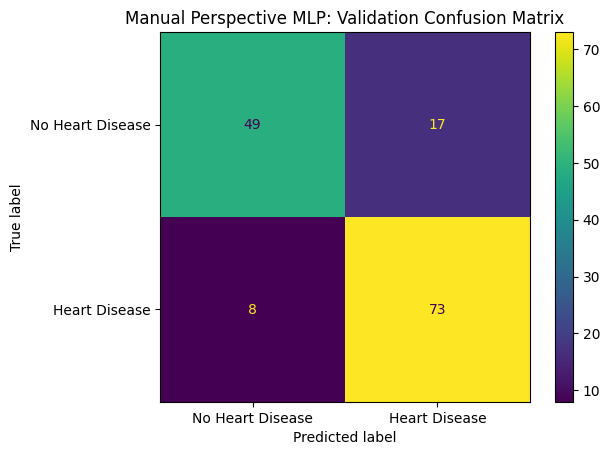

In [124]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_heart_val_array.astype(int),
    manual_average_validation_prediction,

    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title(
    "Manual Perspective MLP: Validation Confusion Matrix"
)

plt.show()

Compare with the Full-Feature MLP

In [125]:
full_mlp_validation_accuracy = accuracy_score(
    y_heart_val_array,
    y_val_pred
)

full_mlp_validation_auc = roc_auc_score(
    y_heart_val_array,
    y_val_prob
)

manual_mlp_validation_accuracy = accuracy_score(
    y_heart_val_array,
    manual_average_validation_prediction
)

manual_mlp_validation_auc = roc_auc_score(
    y_heart_val_array,
    manual_average_validation_probability
)

manual_comparison_table = pd.DataFrame(
    {
        "Model": [
            "Full-Feature MLP",
            "Manual Perspective MLP"
        ],

        "Validation Accuracy": [
            full_mlp_validation_accuracy,
            manual_mlp_validation_accuracy
        ],

        "Validation ROC-AUC": [
            full_mlp_validation_auc,
            manual_mlp_validation_auc
        ]
    }
)

display(
    manual_comparison_table.round(4)
)

,Model,Validation Accuracy,Validation ROC-AUC
0,Full-Feature MLP,0.8299,0.9012
1,Manual Perspective MLP,0.8299,0.9052


In [126]:
#Final validation
assert len(perspective_models) == 4

assert len(perspective_preprocessors) == 4

assert (
    manual_validation_probability_matrix.shape
    ==
    (len(X_heart_val), 4)
)

assert np.isfinite(
    manual_validation_probability_matrix
    .to_numpy()
).all()

assert np.all(
    manual_average_validation_probability >= 0
)

assert np.all(
    manual_average_validation_probability <= 1
)

assert set(
    np.unique(
        manual_average_validation_prediction
    )
).issubset({0, 1})

print(
    "Manual perspective MLP validation passed."
)

Manual perspective MLP validation passed.


# Part 6: Automatic Perspective Generation

This section constructs perspectives automatically from the development data using a mixed-type feature-similarity matrix and hierarchical clustering.

In [127]:
from sklearn.metrics import normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering

In [128]:
#Define feature types
automatic_numeric_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

automatic_categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

automatic_feature_names = list(X_heart_dev.columns)

print("Numerical features:")
print(automatic_numeric_features)

print("\nCategorical or binary features:")
print(automatic_categorical_features)

Numerical features:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Categorical or binary features:
['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [129]:
#Correlation ratio function
def correlation_ratio(categories, measurements):
    categories = (
        pd.Series(categories)
        .fillna("Missing")
        .astype(str)
    )

    measurements = pd.to_numeric(
        pd.Series(measurements),
        errors="coerce"
    )

    measurements = measurements.fillna(
        measurements.median()
    )

    category_codes, _ = pd.factorize(categories)

    overall_mean = measurements.mean()

    between_group_variation = 0.0

    for category_code in np.unique(category_codes):
        group_values = measurements[
            category_codes == category_code
        ]

        between_group_variation += (
            len(group_values)
            * (group_values.mean() - overall_mean) ** 2
        )

    total_variation = (
        (measurements - overall_mean) ** 2
    ).sum()

    if total_variation == 0:
        return 0.0

    eta = np.sqrt(
        between_group_variation
        / total_variation
    )

    return float(eta)

In [130]:
#Pairwise feature-similarity function
def calculate_feature_similarity(
    feature_1,
    feature_2,
    dataframe
):
    x = dataframe[feature_1]
    y = dataframe[feature_2]

    feature_1_is_numeric = (
        feature_1 in automatic_numeric_features
    )

    feature_2_is_numeric = (
        feature_2 in automatic_numeric_features
    )

    # Numerical–Numerical
    if (
        feature_1_is_numeric
        and feature_2_is_numeric
    ):
        x_numeric = pd.to_numeric(
            x,
            errors="coerce"
        )

        y_numeric = pd.to_numeric(
            y,
            errors="coerce"
        )

        x_numeric = x_numeric.fillna(
            x_numeric.median()
        )

        y_numeric = y_numeric.fillna(
            y_numeric.median()
        )

        similarity = x_numeric.corr(
            y_numeric,
            method="spearman"
        )

        if pd.isna(similarity):
            return 0.0

        return abs(float(similarity))

    # Categorical–Categorical
    if (
        not feature_1_is_numeric
        and not feature_2_is_numeric
    ):
        x_categorical = (
            x.fillna("Missing").astype(str)
        )

        y_categorical = (
            y.fillna("Missing").astype(str)
        )

        similarity = normalized_mutual_info_score(
            x_categorical,
            y_categorical
        )

        return float(similarity)

    # Numerical–Categorical
    if feature_1_is_numeric:
        return correlation_ratio(
            categories=y,
            measurements=x
        )

    return correlation_ratio(
        categories=x,
        measurements=y
    )

In [131]:
#Construct similarity matrix
number_of_features = len(
    automatic_feature_names
)

automatic_similarity_matrix = np.eye(
    number_of_features
)

for i in range(number_of_features):
    for j in range(i + 1, number_of_features):

        similarity = calculate_feature_similarity(
            feature_1=automatic_feature_names[i],
            feature_2=automatic_feature_names[j],
            dataframe=X_heart_dev
        )

        automatic_similarity_matrix[i, j] = similarity
        automatic_similarity_matrix[j, i] = similarity

In [132]:
automatic_similarity_df = pd.DataFrame(
    automatic_similarity_matrix,
    index=automatic_feature_names,
    columns=automatic_feature_names
)

display(
    automatic_similarity_df.round(3)
)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
Age,1.000,0.026,0.193,0.277,0.033,0.196,0.235,0.387,0.181,0.269,0.292
Sex,0.026,1.000,0.022,0.034,0.158,0.017,0.001,0.180,0.026,0.084,0.015
ChestPainType,0.193,0.022,1.000,0.080,0.102,0.015,0.010,0.344,0.121,0.344,0.109
RestingBP,0.277,0.034,0.080,1.000,0.100,0.052,0.101,0.123,0.138,0.149,0.139
Cholesterol,0.033,0.158,0.102,0.100,1.000,0.029,0.116,0.043,0.043,0.091,0.087
FastingBS,0.196,0.017,0.015,0.052,0.029,1.000,0.020,0.168,0.001,0.011,0.035
RestingECG,0.235,0.001,0.010,0.101,0.116,0.020,1.000,0.158,0.002,0.111,0.004
MaxHR,0.387,0.180,0.344,0.123,0.043,0.168,0.158,1.000,0.369,0.200,0.398
ExerciseAngina,0.181,0.026,0.121,0.138,0.043,0.001,0.002,0.369,1.000,0.427,0.150
Oldpeak,0.269,0.084,0.344,0.149,0.091,0.011,0.111,0.200,0.427,1.000,0.520


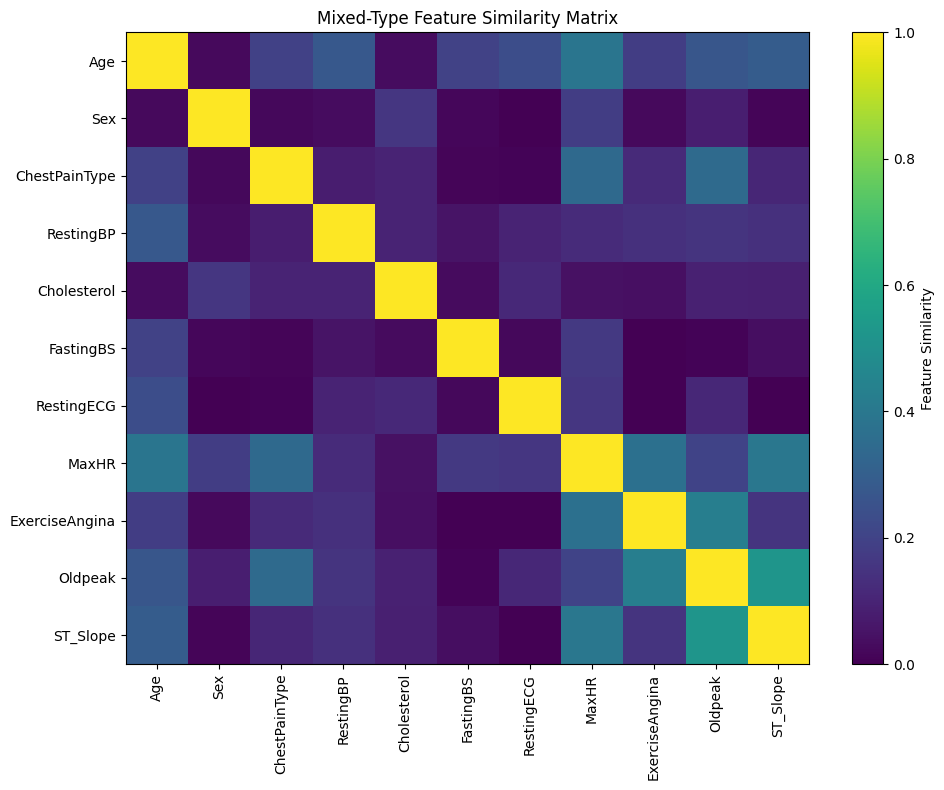

In [133]:
#Plot similarity matrix
plt.figure(figsize=(10, 8))

plt.imshow(
    automatic_similarity_df,
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    label="Feature Similarity"
)

plt.xticks(
    range(number_of_features),
    automatic_feature_names,
    rotation=90
)

plt.yticks(
    range(number_of_features),
    automatic_feature_names
)

plt.title(
    "Mixed-Type Feature Similarity Matrix"
)

plt.tight_layout()
plt.show()

In [134]:
#Convert similarity to distance
automatic_distance_matrix = (
    1.0 - automatic_similarity_matrix
)

np.fill_diagonal(
    automatic_distance_matrix,
    0.0
)

automatic_distance_df = pd.DataFrame(
    automatic_distance_matrix,
    index=automatic_feature_names,
    columns=automatic_feature_names
)

display(
    automatic_distance_df.round(3)
)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
Age,0.000,0.974,0.807,0.723,0.967,0.804,0.765,0.613,0.819,0.731,0.708
Sex,0.974,0.000,0.978,0.966,0.842,0.983,0.999,0.820,0.974,0.916,0.985
ChestPainType,0.807,0.978,0.000,0.920,0.898,0.985,0.990,0.656,0.879,0.656,0.891
RestingBP,0.723,0.966,0.920,0.000,0.900,0.948,0.899,0.877,0.862,0.851,0.861
Cholesterol,0.967,0.842,0.898,0.900,0.000,0.971,0.884,0.957,0.957,0.909,0.913
FastingBS,0.804,0.983,0.985,0.948,0.971,0.000,0.980,0.832,0.999,0.989,0.965
RestingECG,0.765,0.999,0.990,0.899,0.884,0.980,0.000,0.842,0.998,0.889,0.996
MaxHR,0.613,0.820,0.656,0.877,0.957,0.832,0.842,0.000,0.631,0.800,0.602
ExerciseAngina,0.819,0.974,0.879,0.862,0.957,0.999,0.998,0.631,0.000,0.573,0.850
Oldpeak,0.731,0.916,0.656,0.851,0.909,0.989,0.889,0.800,0.573,0.000,0.480


In [135]:
#Perform hierarchical clustering
NUMBER_OF_AUTOMATIC_PERSPECTIVES = 4

try:
    automatic_clusterer = AgglomerativeClustering(
        n_clusters=NUMBER_OF_AUTOMATIC_PERSPECTIVES,
        metric="precomputed",
        linkage="average"
    )

except TypeError:
    automatic_clusterer = AgglomerativeClustering(
        n_clusters=NUMBER_OF_AUTOMATIC_PERSPECTIVES,
        affinity="precomputed",
        linkage="average"
    )

automatic_cluster_labels = (
    automatic_clusterer.fit_predict(
        automatic_distance_matrix
    )
)

print("Cluster labels:")
print(automatic_cluster_labels)

Cluster labels:
[0 2 0 0 2 3 1 0 0 0 0]


In [136]:
#Create automatic perspectives
temporary_clusters = {}

for feature_name, cluster_label in zip(
    automatic_feature_names,
    automatic_cluster_labels
):
    cluster_label = int(cluster_label)

    if cluster_label not in temporary_clusters:
        temporary_clusters[cluster_label] = []

    temporary_clusters[cluster_label].append(
        feature_name
    )

In [137]:
ordered_clusters = sorted(
    temporary_clusters.values(),
    key=lambda feature_group: min(
        automatic_feature_names.index(feature)
        for feature in feature_group
    )
)

automatic_perspectives = {
    f"Auto_Perspective_{index + 1}": feature_group

    for index, feature_group in enumerate(
        ordered_clusters
    )
}

In [138]:
for perspective_name, features in (
    automatic_perspectives.items()
):
    print(perspective_name)
    print(features)
    print()

Auto_Perspective_1
['Age', 'ChestPainType', 'RestingBP', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Auto_Perspective_2
['Sex', 'Cholesterol']

Auto_Perspective_3
['FastingBS']

Auto_Perspective_4
['RestingECG']



In [139]:
#Assignment table
automatic_assignment_rows = []

for perspective_name, features in (
    automatic_perspectives.items()
):
    for feature in features:
        automatic_assignment_rows.append(
            {
                "Feature": feature,
                "Automatic Perspective": perspective_name
            }
        )

automatic_assignment_df = pd.DataFrame(
    automatic_assignment_rows
)

display(automatic_assignment_df)

,Feature,Automatic Perspective
0,Age,Auto_Perspective_1
1,ChestPainType,Auto_Perspective_1
2,RestingBP,Auto_Perspective_1
3,MaxHR,Auto_Perspective_1
4,ExerciseAngina,Auto_Perspective_1
5,Oldpeak,Auto_Perspective_1
6,ST_Slope,Auto_Perspective_1
7,Sex,Auto_Perspective_2
8,Cholesterol,Auto_Perspective_2
9,FastingBS,Auto_Perspective_3


Validate automatic perspectives

In [140]:
all_automatic_features = []

for feature_group in automatic_perspectives.values():
    all_automatic_features.extend(feature_group)

assert len(automatic_perspectives) == 4

assert len(all_automatic_features) == 11

assert len(set(all_automatic_features)) == 11

assert set(all_automatic_features) == set(
    X_heart_dev.columns
)

assert "HeartDisease" not in all_automatic_features

assert np.allclose(
    automatic_similarity_matrix,
    automatic_similarity_matrix.T
)

assert np.all(
    automatic_similarity_matrix >= 0
)

assert np.all(
    automatic_similarity_matrix <= 1
)

print(
    "Automatic perspective generation passed."
)

Automatic perspective generation passed.


Part 6B — Train Automatic Perspective MLPs

In [141]:
#Check group sizes
automatic_group_sizes = pd.DataFrame({
    "Perspective": list(automatic_perspectives.keys()),
    "Features": [
        ", ".join(features)
        for features in automatic_perspectives.values()
    ],
    "Number of Features": [
        len(features)
        for features in automatic_perspectives.values()
    ]
})

display(automatic_group_sizes)

,Perspective,Features,Number of Features
0,Auto_Perspective_1,"Age, ChestPainType, RestingBP, MaxHR, Exercise...",7
1,Auto_Perspective_2,"Sex, Cholesterol",2
2,Auto_Perspective_3,FastingBS,1
3,Auto_Perspective_4,RestingECG,1


In [142]:
#Train the automatic perspective models
automatic_models = {}
automatic_preprocessors = {}
automatic_histories = {}
automatic_validation_probabilities = {}

automatic_results = []

for perspective_index, (
    perspective_name,
    perspective_features
) in enumerate(automatic_perspectives.items()):

    print("=" * 60)
    print("Training:", perspective_name)
    print("Features:", perspective_features)

    # Create perspective-specific preprocessing
    auto_preprocessor = build_perspective_preprocessor(
        perspective_features
    )

    # Fit preprocessing only on development data
    X_auto_dev = auto_preprocessor.fit_transform(
        X_heart_dev[perspective_features]
    ).astype("float32")

    # Transform validation data using development statistics
    X_auto_val = auto_preprocessor.transform(
        X_heart_val[perspective_features]
    ).astype("float32")

    input_dimension = X_auto_dev.shape[1]

    print(
        "Processed input dimension:",
        input_dimension
    )

    # Reproducible initialization
    keras.utils.set_random_seed(
        SEED + 100 + perspective_index
    )

    # Build a small perspective-specific MLP
    auto_model = build_perspective_mlp(
        input_dimension=input_dimension,
        perspective_name=perspective_name
    )

    auto_early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=20,
        restore_best_weights=True,
        verbose=0
    )

    auto_history = auto_model.fit(
        X_auto_dev,
        y_heart_dev_array,

        validation_data=(
            X_auto_val,
            y_heart_val_array
        ),

        epochs=250,
        batch_size=32,

        callbacks=[
            auto_early_stopping
        ],

        verbose=0
    )

    # Validation probabilities
    auto_probabilities = auto_model.predict(
        X_auto_val,
        verbose=0
    ).ravel()

    auto_predictions = (
        auto_probabilities >= 0.50
    ).astype(int)

    best_epoch = (
        np.argmin(
            auto_history.history["val_loss"]
        )
        + 1
    )

    validation_accuracy = accuracy_score(
        y_heart_val_array,
        auto_predictions
    )

    validation_auc = roc_auc_score(
        y_heart_val_array,
        auto_probabilities
    )

    # Save objects
    automatic_models[perspective_name] = auto_model

    automatic_preprocessors[
        perspective_name
    ] = auto_preprocessor

    automatic_histories[
        perspective_name
    ] = auto_history

    automatic_validation_probabilities[
        perspective_name
    ] = auto_probabilities

    automatic_results.append({
        "Perspective": perspective_name,
        "Original Features": len(perspective_features),
        "Processed Features": input_dimension,
        "Best Epoch": best_epoch,
        "Validation Accuracy": validation_accuracy,
        "Validation ROC-AUC": validation_auc
    })

    print("Best epoch:", best_epoch)

    print(
        "Validation accuracy:",
        round(validation_accuracy, 4)
    )

    print(
        "Validation ROC-AUC:",
        round(validation_auc, 4)
    )

Training: Auto_Perspective_1
Features: ['Age', 'ChestPainType', 'RestingBP', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
Processed input dimension: 12
Best epoch: 26
Validation accuracy: 0.8231
Validation ROC-AUC: 0.8835
Training: Auto_Perspective_2
Features: ['Sex', 'Cholesterol']
Processed input dimension: 2
Best epoch: 65
Validation accuracy: 0.6531
Validation ROC-AUC: 0.6696
Training: Auto_Perspective_3
Features: ['FastingBS']
Processed input dimension: 1
Best epoch: 8
Validation accuracy: 0.551
Validation ROC-AUC: 0.5868
Training: Auto_Perspective_4
Features: ['RestingECG']
Processed input dimension: 3
Best epoch: 12
Validation accuracy: 0.551
Validation ROC-AUC: 0.5328


In [143]:
#Show individual perspective results
automatic_results_df = pd.DataFrame(
    automatic_results
)

display(
    automatic_results_df.round(4)
)

,Perspective,Original Features,Processed Features,Best Epoch,Validation Accuracy,Validation ROC-AUC
0,Auto_Perspective_1,7,12,26,0.8231,0.8835
1,Auto_Perspective_2,2,2,65,0.6531,0.6696
2,Auto_Perspective_3,1,1,8,0.5510,0.5868
3,Auto_Perspective_4,1,3,12,0.5510,0.5328


Part 6C — Average Fusion

In [144]:
#Build probability matrix
automatic_validation_probability_matrix = pd.DataFrame(
    automatic_validation_probabilities,
    index=X_heart_val.index
)

display(
    automatic_validation_probability_matrix.head()
)

,Auto_Perspective_1,Auto_Perspective_2,Auto_Perspective_3,Auto_Perspective_4
192,0.048117,0.666585,0.501327,0.510842
167,0.071442,0.663306,0.501327,0.510842
825,0.200820,0.678866,0.501327,0.549137
36,0.970403,0.637934,0.742087,0.510842
744,0.751629,0.648378,0.742087,0.510842


In [145]:
#Equal-weight averaging
automatic_average_validation_probability = (
    automatic_validation_probability_matrix
    .mean(axis=1)
    .to_numpy()
)

automatic_average_validation_prediction = (
    automatic_average_validation_probability
    >= 0.50
).astype(int)

In [146]:
#Evaluate automatic fusion
automatic_fusion_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value": [
        accuracy_score(
            y_heart_val_array,
            automatic_average_validation_prediction
        ),

        precision_score(
            y_heart_val_array,
            automatic_average_validation_prediction,
            zero_division=0
        ),

        recall_score(
            y_heart_val_array,
            automatic_average_validation_prediction,
            zero_division=0
        ),

        f1_score(
            y_heart_val_array,
            automatic_average_validation_prediction,
            zero_division=0
        ),

        roc_auc_score(
            y_heart_val_array,
            automatic_average_validation_probability
        )
    ]
})

display(
    automatic_fusion_metrics.round(4)
)

,Metric,Value
0,Accuracy,0.8163
1,Precision,0.7755
2,Recall,0.9383
3,F1-score,0.8492
4,ROC-AUC,0.8930


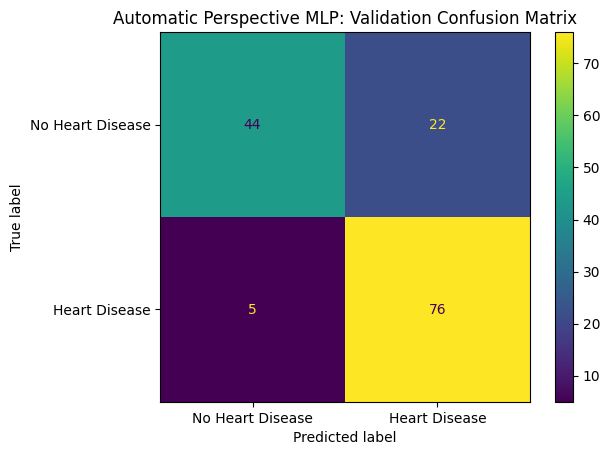

In [147]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_heart_val_array.astype(int),
    automatic_average_validation_prediction,

    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title(
    "Automatic Perspective MLP: Validation Confusion Matrix"
)

plt.show()

Compare All Three MLP Models

In [148]:
automatic_mlp_validation_accuracy = accuracy_score(
    y_heart_val_array,
    automatic_average_validation_prediction
)

automatic_mlp_validation_auc = roc_auc_score(
    y_heart_val_array,
    automatic_average_validation_probability
)

three_model_comparison = pd.DataFrame({
    "Model": [
        "Full-Feature MLP",
        "Manual Perspective MLP",
        "Automatic Perspective MLP"
    ],

    "Validation Accuracy": [
        full_mlp_validation_accuracy,
        manual_mlp_validation_accuracy,
        automatic_mlp_validation_accuracy
    ],

    "Validation ROC-AUC": [
        full_mlp_validation_auc,
        manual_mlp_validation_auc,
        automatic_mlp_validation_auc
    ]
})

display(
    three_model_comparison.round(4)
)

,Model,Validation Accuracy,Validation ROC-AUC
0,Full-Feature MLP,0.8299,0.9012
1,Manual Perspective MLP,0.8299,0.9052
2,Automatic Perspective MLP,0.8163,0.8930


-------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Part 7: Heart-Condition-Aware Automatic Perspectives

This section measures individual feature relevance and pairwise predictive complementarity using out-of-fold predictions on the development data.

In [149]:
#Import required tools
from itertools import combinations

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

In [150]:
#Define internal cross-validation
feature_scoring_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(feature_scoring_cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [151]:
#Create a feature-scoring function
def calculate_cross_validated_auc(feature_list):
    """
    Calculate out-of-fold ROC-AUC using only the
    selected original clinical features.
    """

    feature_preprocessor = (
        build_perspective_preprocessor(
            feature_list
        )
    )

    scoring_classifier = LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        random_state=SEED
    )

    scoring_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                feature_preprocessor
            ),
            (
                "classifier",
                scoring_classifier
            )
        ]
    )

    out_of_fold_probabilities = cross_val_predict(
        scoring_pipeline,

        X_heart_dev[feature_list],
        y_heart_dev,

        cv=feature_scoring_cv,
        method="predict_proba"
    )[:, 1]

    auc_value = roc_auc_score(
        y_heart_dev,
        out_of_fold_probabilities
    )

    return float(auc_value)

In [152]:
#Calculate individual feature AUC
heart_feature_names = list(
    X_heart_dev.columns
)

individual_feature_auc = {}

for feature_name in heart_feature_names:

    auc_value = calculate_cross_validated_auc(
        [feature_name]
    )

    individual_feature_auc[
        feature_name
    ] = auc_value

    print(
        feature_name,
        "AUC =",
        round(auc_value, 4)
    )

Age AUC = 0.6507
Sex AUC = 0.5992
ChestPainType AUC = 0.7637
RestingBP AUC = 0.5392
Cholesterol AUC = 0.5417
FastingBS AUC = 0.6023
RestingECG AUC = 0.5487
MaxHR AUC = 0.7454
ExerciseAngina AUC = 0.7261
Oldpeak AUC = 0.7108
ST_Slope AUC = 0.7971


In [153]:
#Display sorted individual results
individual_feature_auc_df = pd.DataFrame({
    "Feature": list(
        individual_feature_auc.keys()
    ),

    "Individual CV ROC-AUC": list(
        individual_feature_auc.values()
    )
})

individual_feature_auc_df = (
    individual_feature_auc_df
    .sort_values(
        by="Individual CV ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    individual_feature_auc_df.round(4)
)

,Feature,Individual CV ROC-AUC
0,ST_Slope,0.7971
1,ChestPainType,0.7637
2,MaxHR,0.7454
3,ExerciseAngina,0.7261
4,Oldpeak,0.7108
5,Age,0.6507
6,FastingBS,0.6023
7,Sex,0.5992
8,RestingECG,0.5487
9,Cholesterol,0.5417


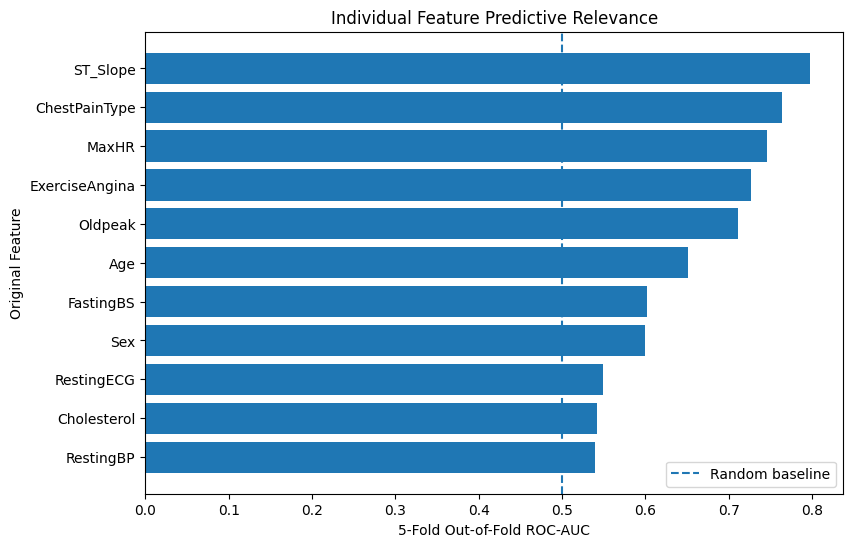

In [154]:
#Plot individual feature scores
individual_plot_data = (
    individual_feature_auc_df
    .sort_values(
        by="Individual CV ROC-AUC"
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    individual_plot_data["Feature"],
    individual_plot_data[
        "Individual CV ROC-AUC"
    ]
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Random baseline"
)

plt.title(
    "Individual Feature Predictive Relevance"
)

plt.xlabel(
    "5-Fold Out-of-Fold ROC-AUC"
)

plt.ylabel("Original Feature")

plt.legend()
plt.show()

Calculate all feature-pair AUC values

In [155]:
number_of_heart_features = len(
    heart_feature_names
)

pairwise_auc_matrix = np.zeros(
    (
        number_of_heart_features,
        number_of_heart_features
    )
)

pairwise_gain_matrix = np.zeros(
    (
        number_of_heart_features,
        number_of_heart_features
    )
)

# Put individual AUC values on the diagonal
for feature_index, feature_name in enumerate(
    heart_feature_names
):
    pairwise_auc_matrix[
        feature_index,
        feature_index
    ] = individual_feature_auc[
        feature_name
    ]

In [156]:
pairwise_feature_results = []

all_feature_pairs = list(
    combinations(
        heart_feature_names,
        2
    )
)

print(
    "Total feature pairs:",
    len(all_feature_pairs)
)

for pair_number, (
    feature_1,
    feature_2
) in enumerate(
    all_feature_pairs,
    start=1
):

    pair_auc = calculate_cross_validated_auc(
        [
            feature_1,
            feature_2
        ]
    )

    best_individual_auc = max(
        individual_feature_auc[feature_1],
        individual_feature_auc[feature_2]
    )

    complementarity_gain = max(
        0.0,
        pair_auc - best_individual_auc
    )

    index_1 = heart_feature_names.index(
        feature_1
    )

    index_2 = heart_feature_names.index(
        feature_2
    )

    pairwise_auc_matrix[
        index_1,
        index_2
    ] = pair_auc

    pairwise_auc_matrix[
        index_2,
        index_1
    ] = pair_auc

    pairwise_gain_matrix[
        index_1,
        index_2
    ] = complementarity_gain

    pairwise_gain_matrix[
        index_2,
        index_1
    ] = complementarity_gain

    pairwise_feature_results.append({
        "Feature 1": feature_1,
        "Feature 2": feature_2,
        "Feature 1 AUC": individual_feature_auc[
            feature_1
        ],
        "Feature 2 AUC": individual_feature_auc[
            feature_2
        ],
        "Pair CV ROC-AUC": pair_auc,
        "Complementarity Gain": complementarity_gain
    })

    print(
        f"{pair_number:02d}/55:",
        feature_1,
        "+",
        feature_2,
        "AUC =",
        round(pair_auc, 4),
        "Gain =",
        round(complementarity_gain, 4)
    )

Total feature pairs: 55
01/55: Age + Sex AUC = 0.7056 Gain = 0.0549
02/55: Age + ChestPainType AUC = 0.8183 Gain = 0.0546
03/55: Age + RestingBP AUC = 0.6487 Gain = 0.0
04/55: Age + Cholesterol AUC = 0.6501 Gain = 0.0
05/55: Age + FastingBS AUC = 0.7045 Gain = 0.0538
06/55: Age + RestingECG AUC = 0.653 Gain = 0.0023
07/55: Age + MaxHR AUC = 0.7445 Gain = 0.0
08/55: Age + ExerciseAngina AUC = 0.7983 Gain = 0.0721
09/55: Age + Oldpeak AUC = 0.7494 Gain = 0.0386
10/55: Age + ST_Slope AUC = 0.8316 Gain = 0.0346
11/55: Sex + ChestPainType AUC = 0.7963 Gain = 0.0326
12/55: Sex + RestingBP AUC = 0.6273 Gain = 0.0281
13/55: Sex + Cholesterol AUC = 0.6472 Gain = 0.048
14/55: Sex + FastingBS AUC = 0.6722 Gain = 0.0699
15/55: Sex + RestingECG AUC = 0.6388 Gain = 0.0396
16/55: Sex + MaxHR AUC = 0.7709 Gain = 0.0255
17/55: Sex + ExerciseAngina AUC = 0.7737 Gain = 0.0476
18/55: Sex + Oldpeak AUC = 0.7528 Gain = 0.042
19/55: Sex + ST_Slope AUC = 0.8526 Gain = 0.0556
20/55: ChestPainType + RestingBP A

In [157]:
#Display the strongest pairs
pairwise_feature_results_df = pd.DataFrame(
    pairwise_feature_results
)

pairwise_feature_results_df = (
    pairwise_feature_results_df
    .sort_values(
        by=[
            "Pair CV ROC-AUC",
            "Complementarity Gain"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    pairwise_feature_results_df
    .head(15)
    .round(4)
)

,Feature 1,Feature 2,Feature 1 AUC,Feature 2 AUC,Pair CV ROC-AUC,Complementarity Gain
0,ChestPainType,ST_Slope,0.7637,0.7971,0.8804,0.0833
1,MaxHR,ST_Slope,0.7454,0.7971,0.8759,0.0789
2,ExerciseAngina,ST_Slope,0.7261,0.7971,0.8573,0.0603
3,Sex,ST_Slope,0.5992,0.7971,0.8526,0.0556
4,ChestPainType,MaxHR,0.7637,0.7454,0.8387,0.0750
5,Oldpeak,ST_Slope,0.7108,0.7971,0.8341,0.0370
6,FastingBS,ST_Slope,0.6023,0.7971,0.8336,0.0365
7,ChestPainType,ExerciseAngina,0.7637,0.7261,0.8323,0.0686
8,Age,ST_Slope,0.6507,0.7971,0.8316,0.0346
9,RestingECG,ST_Slope,0.5487,0.7971,0.8226,0.0256


In [158]:
#Display the most complementary pairs
most_complementary_pairs_df = (
    pd.DataFrame(
        pairwise_feature_results
    )
    .sort_values(
        by="Complementarity Gain",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    most_complementary_pairs_df
    .head(15)
    .round(4)
)

,Feature 1,Feature 2,Feature 1 AUC,Feature 2 AUC,Pair CV ROC-AUC,Complementarity Gain
0,ChestPainType,ST_Slope,0.7637,0.7971,0.8804,0.0833
1,MaxHR,ST_Slope,0.7454,0.7971,0.8759,0.0789
2,ChestPainType,MaxHR,0.7637,0.7454,0.8387,0.0750
3,Age,ExerciseAngina,0.6507,0.7261,0.7983,0.0721
4,Sex,FastingBS,0.5992,0.6023,0.6722,0.0699
5,FastingBS,ExerciseAngina,0.6023,0.7261,0.7948,0.0687
6,ChestPainType,ExerciseAngina,0.7637,0.7261,0.8323,0.0686
7,MaxHR,ExerciseAngina,0.7454,0.7261,0.8140,0.0685
8,ExerciseAngina,ST_Slope,0.7261,0.7971,0.8573,0.0603
9,ChestPainType,Oldpeak,0.7637,0.7108,0.8222,0.0585


In [159]:
#Convert matrices to DataFrames
pairwise_auc_df = pd.DataFrame(
    pairwise_auc_matrix,
    index=heart_feature_names,
    columns=heart_feature_names
)

pairwise_gain_df = pd.DataFrame(
    pairwise_gain_matrix,
    index=heart_feature_names,
    columns=heart_feature_names
)

print("Pairwise predictive AUC matrix:")

display(
    pairwise_auc_df.round(3)
)

print("\nPairwise complementarity-gain matrix:")

display(
    pairwise_gain_df.round(3)
)

Pairwise predictive AUC matrix:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
Age,0.651,0.706,0.818,0.649,0.650,0.704,0.653,0.744,0.798,0.749,0.832
Sex,0.706,0.599,0.796,0.627,0.647,0.672,0.639,0.771,0.774,0.753,0.853
ChestPainType,0.818,0.796,0.764,0.780,0.767,0.805,0.780,0.839,0.832,0.822,0.880
RestingBP,0.649,0.627,0.780,0.539,0.536,0.635,0.568,0.744,0.720,0.716,0.794
Cholesterol,0.650,0.647,0.767,0.536,0.542,0.636,0.558,0.749,0.738,0.711,0.796
FastingBS,0.704,0.672,0.805,0.635,0.636,0.602,0.629,0.776,0.795,0.761,0.834
RestingECG,0.653,0.639,0.780,0.568,0.558,0.629,0.549,0.750,0.758,0.728,0.823
MaxHR,0.744,0.771,0.839,0.744,0.749,0.776,0.750,0.745,0.814,0.803,0.876
ExerciseAngina,0.798,0.774,0.832,0.720,0.738,0.795,0.758,0.814,0.726,0.784,0.857
Oldpeak,0.749,0.753,0.822,0.716,0.711,0.761,0.728,0.803,0.784,0.711,0.834



Pairwise complementarity-gain matrix:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
Age,0.000,0.055,0.055,0.000,0.000,0.054,0.002,0.000,0.072,0.039,0.035
Sex,0.055,0.000,0.033,0.028,0.048,0.070,0.040,0.025,0.048,0.042,0.056
ChestPainType,0.055,0.033,0.000,0.017,0.004,0.041,0.017,0.075,0.069,0.059,0.083
RestingBP,0.000,0.028,0.017,0.000,0.000,0.033,0.019,0.000,0.000,0.005,0.000
Cholesterol,0.000,0.048,0.004,0.000,0.000,0.033,0.010,0.004,0.012,0.000,0.000
FastingBS,0.054,0.070,0.041,0.033,0.033,0.000,0.027,0.031,0.069,0.050,0.037
RestingECG,0.002,0.040,0.017,0.019,0.010,0.027,0.000,0.004,0.032,0.017,0.026
MaxHR,0.000,0.025,0.075,0.000,0.004,0.031,0.004,0.000,0.069,0.057,0.079
ExerciseAngina,0.072,0.048,0.069,0.000,0.012,0.069,0.032,0.069,0.000,0.057,0.060
Oldpeak,0.039,0.042,0.059,0.005,0.000,0.050,0.017,0.057,0.057,0.000,0.037


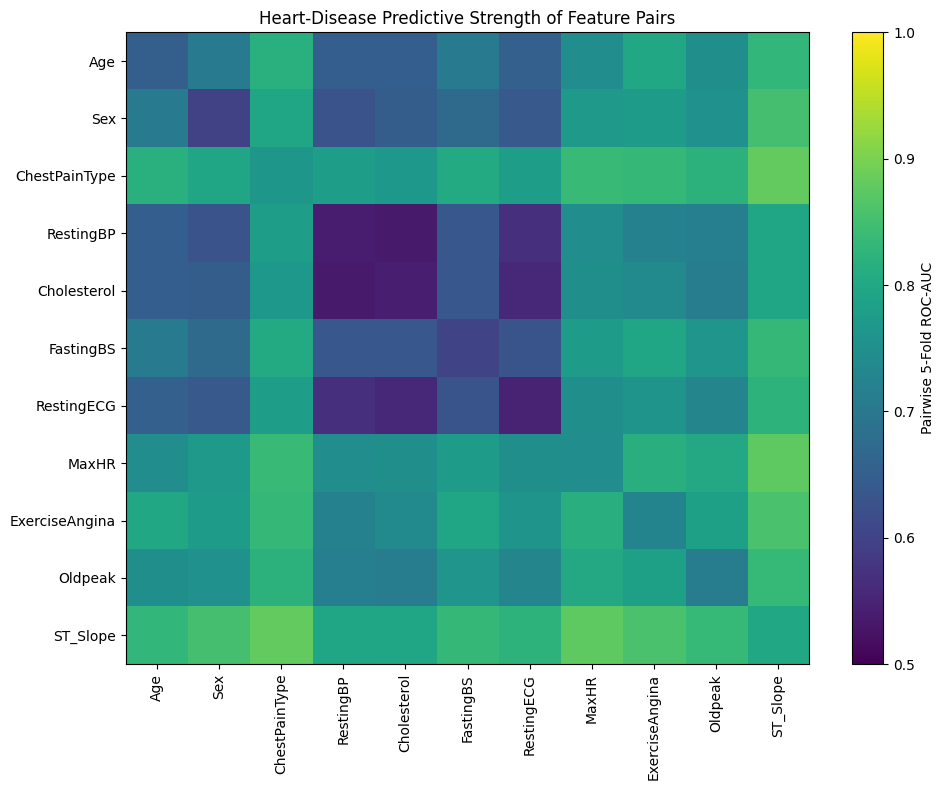

In [160]:
#visualize pairwise predictive AUC
plt.figure(figsize=(10, 8))

plt.imshow(
    pairwise_auc_df,
    vmin=0.50,
    vmax=1.00,
    aspect="auto"
)

plt.colorbar(
    label="Pairwise 5-Fold ROC-AUC"
)

plt.xticks(
    range(number_of_heart_features),
    heart_feature_names,
    rotation=90
)

plt.yticks(
    range(number_of_heart_features),
    heart_feature_names
)

plt.title(
    "Heart-Disease Predictive Strength of Feature Pairs"
)

plt.tight_layout()
plt.show()

In [161]:
#Validate the results
assert len(
    individual_feature_auc
) == 11

assert len(
    pairwise_feature_results
) == 55

assert pairwise_auc_matrix.shape == (
    11,
    11
)

assert pairwise_gain_matrix.shape == (
    11,
    11
)

assert np.allclose(
    pairwise_auc_matrix,
    pairwise_auc_matrix.T
)

assert np.allclose(
    pairwise_gain_matrix,
    pairwise_gain_matrix.T
)

assert np.all(
    pairwise_gain_matrix >= 0
)

assert np.isfinite(
    pairwise_auc_matrix
).all()

assert np.isfinite(
    pairwise_gain_matrix
).all()

print(
    "Heart-condition-aware feature scoring passed."
)

Heart-condition-aware feature scoring passed.


# Part 7B: Heart-Condition-Aware Balanced Perspectives

The automatic perspectives are constructed using joint target prediction,
pairwise complementarity, and mixed-type feature dependency.

Perspective generation uses only the development data.

In [162]:
#Verify required results
required_part7_objects = [
    "heart_feature_names",
    "individual_feature_auc",
    "pairwise_auc_matrix",
    "pairwise_gain_matrix",
    "automatic_similarity_matrix"
]

for object_name in required_part7_objects:
    assert object_name in globals(), (
        f"{object_name} is missing. "
        "Run Parts 6A and 7A first."
    )

print("All feature-scoring results are available.")

All feature-scoring results are available.


In [163]:
#Normalize the three score matrices
# Pairwise AUC: 0.50 maps to 0, and 1.00 maps to 1
normalized_pairwise_auc = np.clip(
    (pairwise_auc_matrix - 0.50) / 0.50,
    0.0,
    1.0
)

# Complementarity gain normalization
maximum_gain = pairwise_gain_matrix.max()

if maximum_gain > 0:
    normalized_pairwise_gain = (
        pairwise_gain_matrix / maximum_gain
    )
else:
    normalized_pairwise_gain = (
        np.zeros_like(pairwise_gain_matrix)
    )

# Mixed-type dependency is already between 0 and 1
normalized_dependency = np.clip(
    automatic_similarity_matrix,
    0.0,
    1.0
)

print(
    "Maximum observed complementarity gain:",
    round(float(maximum_gain), 4)
)

Maximum observed complementarity gain: 0.0833


In [164]:
#Build the final affinity matrix
JOINT_PREDICTION_WEIGHT = 0.50
COMPLEMENTARITY_WEIGHT = 0.30
DEPENDENCY_WEIGHT = 0.20

assert np.isclose(
    JOINT_PREDICTION_WEIGHT
    + COMPLEMENTARITY_WEIGHT
    + DEPENDENCY_WEIGHT,
    1.0
)

heart_condition_affinity_matrix = (
    JOINT_PREDICTION_WEIGHT
    * normalized_pairwise_auc

    + COMPLEMENTARITY_WEIGHT
    * normalized_pairwise_gain

    + DEPENDENCY_WEIGHT
    * normalized_dependency
)

# A feature is perfectly compatible with itself
np.fill_diagonal(
    heart_condition_affinity_matrix,
    1.0
)

heart_condition_affinity_df = pd.DataFrame(
    heart_condition_affinity_matrix,
    index=heart_feature_names,
    columns=heart_feature_names
)

display(
    heart_condition_affinity_df.round(3)
)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
Age,1.000,0.409,0.553,0.204,0.157,0.437,0.208,0.322,0.594,0.442,0.515
Sex,0.409,1.000,0.418,0.235,0.351,0.427,0.282,0.399,0.450,0.421,0.556
ChestPainType,0.553,0.418,1.000,0.356,0.301,0.457,0.342,0.677,0.603,0.602,0.702
RestingBP,0.204,0.235,0.356,1.000,0.056,0.265,0.157,0.269,0.248,0.263,0.322
Cholesterol,0.157,0.351,0.301,0.056,1.000,0.262,0.116,0.272,0.290,0.231,0.314
FastingBS,0.437,0.427,0.457,0.265,0.262,1.000,0.229,0.421,0.542,0.443,0.472
RestingECG,0.208,0.282,0.342,0.157,0.116,0.229,1.000,0.297,0.375,0.312,0.415
MaxHR,0.322,0.399,0.677,0.269,0.272,0.421,0.297,1.000,0.634,0.549,0.740
ExerciseAngina,0.594,0.450,0.603,0.248,0.290,0.542,0.375,0.634,1.000,0.576,0.604
Oldpeak,0.442,0.421,0.602,0.263,0.231,0.443,0.312,0.549,0.576,1.000,0.571


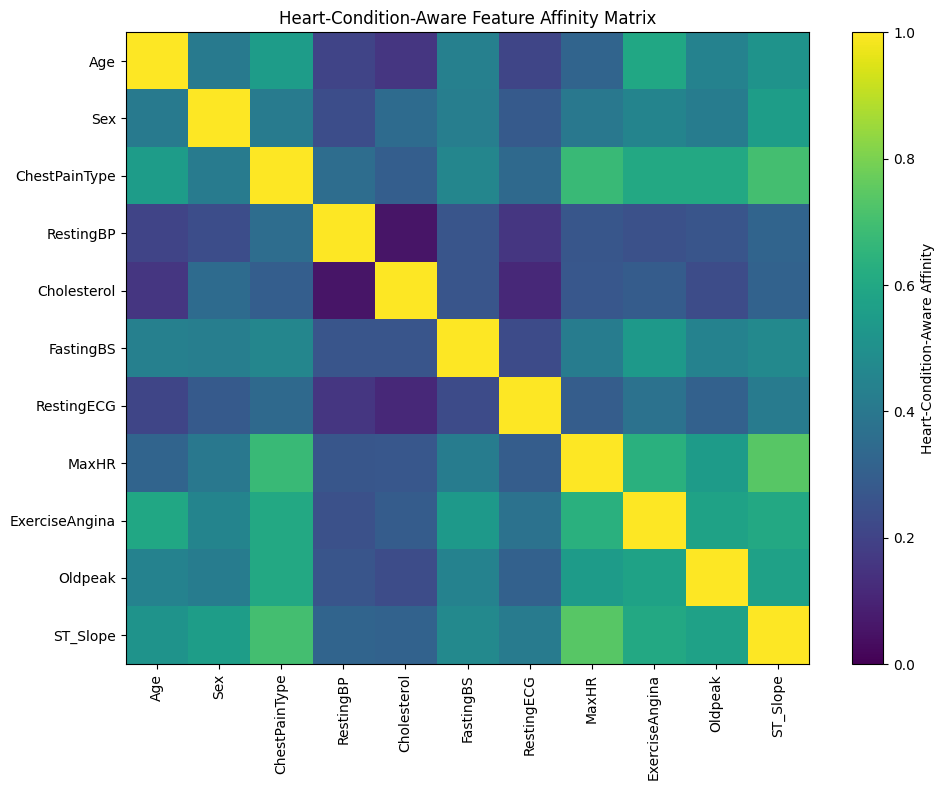

In [165]:
#Plot final affinity matrix
plt.figure(figsize=(10, 8))

plt.imshow(
    heart_condition_affinity_df,
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    label="Heart-Condition-Aware Affinity"
)

plt.xticks(
    range(len(heart_feature_names)),
    heart_feature_names,
    rotation=90
)

plt.yticks(
    range(len(heart_feature_names)),
    heart_feature_names
)

plt.title(
    "Heart-Condition-Aware Feature Affinity Matrix"
)

plt.tight_layout()
plt.show()

In [166]:
#Normalize individual feature relevance
individual_auc_values = np.array(
    [
        individual_feature_auc[feature]
        for feature in heart_feature_names
    ],
    dtype=float
)

minimum_individual_auc = (
    individual_auc_values.min()
)

maximum_individual_auc = (
    individual_auc_values.max()
)

if (
    maximum_individual_auc
    > minimum_individual_auc
):
    normalized_individual_relevance = (
        individual_auc_values
        - minimum_individual_auc
    ) / (
        maximum_individual_auc
        - minimum_individual_auc
    )
else:
    normalized_individual_relevance = (
        np.ones_like(individual_auc_values)
    )

individual_relevance_df = pd.DataFrame({
    "Feature": heart_feature_names,
    "Individual CV AUC": individual_auc_values,
    "Normalized Relevance": (
        normalized_individual_relevance
    )
})

display(
    individual_relevance_df
    .sort_values(
        "Individual CV AUC",
        ascending=False
    )
    .round(4)
)

,Feature,Individual CV AUC,Normalized Relevance
10,ST_Slope,0.7971,1.0000
2,ChestPainType,0.7637,0.8707
7,MaxHR,0.7454,0.7999
8,ExerciseAngina,0.7261,0.7249
9,Oldpeak,0.7108,0.6654
0,Age,0.6507,0.4325
5,FastingBS,0.6023,0.2450
1,Sex,0.5992,0.2328
6,RestingECG,0.5487,0.0370
4,Cholesterol,0.5417,0.0100


In [167]:
#Select four diverse predictive anchors
NUMBER_OF_BALANCED_PERSPECTIVES = 4

selected_anchor_indices = []

# First anchor: highest individual predictive relevance
first_anchor_index = int(
    np.argmax(
        normalized_individual_relevance
    )
)

selected_anchor_indices.append(
    first_anchor_index
)

while (
    len(selected_anchor_indices)
    < NUMBER_OF_BALANCED_PERSPECTIVES
):

    candidate_scores = []

    for candidate_index in range(
        len(heart_feature_names)
    ):
        if candidate_index in selected_anchor_indices:
            continue

        relevance_score = (
            normalized_individual_relevance[
                candidate_index
            ]
        )

        maximum_affinity_to_existing_anchor = max(
            heart_condition_affinity_matrix[
                candidate_index,
                anchor_index
            ]
            for anchor_index
            in selected_anchor_indices
        )

        diversity_score = (
            1.0
            - maximum_affinity_to_existing_anchor
        )

        anchor_score = (
            0.70 * relevance_score
            + 0.30 * diversity_score
        )

        candidate_scores.append(
            (
                anchor_score,
                relevance_score,
                diversity_score,
                candidate_index
            )
        )

    # Deterministic selection
    candidate_scores.sort(
        reverse=True
    )

    selected_anchor_indices.append(
        candidate_scores[0][3]
    )

selected_anchor_features = [
    heart_feature_names[index]
    for index in selected_anchor_indices
]

print("Selected perspective anchors:")

for index, feature in enumerate(
    selected_anchor_features,
    start=1
):
    print(
        f"Anchor {index}: {feature}"
    )

Selected perspective anchors:
Anchor 1: ST_Slope
Anchor 2: ChestPainType
Anchor 3: MaxHR
Anchor 4: ExerciseAngina


In [168]:
#Create balanced perspective capacities
perspective_capacities = [
    3,
    3,
    3,
    2
]

assert sum(
    perspective_capacities
) == len(heart_feature_names)

print(
    "Perspective capacities:",
    perspective_capacities
)

Perspective capacities: [3, 3, 3, 2]


In [169]:
#Initialize perspectives with anchors
balanced_perspective_indices = {
    perspective_index: [
        anchor_index
    ]

    for perspective_index, anchor_index
    in enumerate(
        selected_anchor_indices
    )
}

for perspective_index in (
    balanced_perspective_indices
):
    anchor_feature = heart_feature_names[
        balanced_perspective_indices[
            perspective_index
        ][0]
    ]

    print(
        f"Perspective {perspective_index + 1} "
        f"starts with anchor: {anchor_feature}"
    )

Perspective 1 starts with anchor: ST_Slope
Perspective 2 starts with anchor: ChestPainType
Perspective 3 starts with anchor: MaxHR
Perspective 4 starts with anchor: ExerciseAngina


In [170]:
#Assign remaining features
remaining_feature_indices = [
    feature_index

    for feature_index
    in range(len(heart_feature_names))

    if feature_index
    not in selected_anchor_indices
]

# More relevant features are assigned first
remaining_feature_indices.sort(
    key=lambda feature_index:
        normalized_individual_relevance[
            feature_index
        ],
    reverse=True
)

assignment_records = []

for feature_index in remaining_feature_indices:

    eligible_perspectives = []

    for perspective_index in range(
        NUMBER_OF_BALANCED_PERSPECTIVES
    ):
        current_size = len(
            balanced_perspective_indices[
                perspective_index
            ]
        )

        maximum_size = (
            perspective_capacities[
                perspective_index
            ]
        )

        if current_size < maximum_size:
            member_indices = (
                balanced_perspective_indices[
                    perspective_index
                ]
            )

            average_affinity = np.mean(
                [
                    heart_condition_affinity_matrix[
                        feature_index,
                        member_index
                    ]

                    for member_index
                    in member_indices
                ]
            )

            eligible_perspectives.append(
                (
                    float(average_affinity),
                    -current_size,
                    -perspective_index,
                    perspective_index
                )
            )

    eligible_perspectives.sort(
        reverse=True
    )

    selected_perspective_index = (
        eligible_perspectives[0][3]
    )

    selected_affinity = (
        eligible_perspectives[0][0]
    )

    balanced_perspective_indices[
        selected_perspective_index
    ].append(
        feature_index
    )

    assignment_records.append({
        "Feature": heart_feature_names[
            feature_index
        ],

        "Assigned Perspective": (
            f"Condition_Perspective_"
            f"{selected_perspective_index + 1}"
        ),

        "Assignment Affinity": (
            selected_affinity
        )
    })

In [171]:
#Convert indices into feature groups
condition_aware_perspectives = {}

for perspective_index in range(
    NUMBER_OF_BALANCED_PERSPECTIVES
):
    perspective_name = (
        f"Condition_Perspective_"
        f"{perspective_index + 1}"
    )

    perspective_features = [
        heart_feature_names[
            feature_index
        ]

        for feature_index in (
            balanced_perspective_indices[
                perspective_index
            ]
        )
    ]

    condition_aware_perspectives[
        perspective_name
    ] = perspective_features

In [172]:
for perspective_name, features in (
    condition_aware_perspectives.items()
):
    print(perspective_name)
    print(features)
    print(
        "Number of features:",
        len(features)
    )
    print()

Condition_Perspective_1
['ST_Slope', 'FastingBS', 'Sex']
Number of features: 3

Condition_Perspective_2
['ChestPainType', 'Oldpeak', 'RestingECG']
Number of features: 3

Condition_Perspective_3
['MaxHR', 'Cholesterol', 'RestingBP']
Number of features: 3

Condition_Perspective_4
['ExerciseAngina', 'Age']
Number of features: 2



In [173]:
#Create perspective summary table
condition_perspective_rows = []

for perspective_name, features in (
    condition_aware_perspectives.items()
):
    anchor_feature = features[0]

    mean_individual_auc = np.mean(
        [
            individual_feature_auc[feature]
            for feature in features
        ]
    )

    condition_perspective_rows.append({
        "Perspective": perspective_name,
        "Anchor": anchor_feature,
        "Features": ", ".join(features),
        "Group Size": len(features),
        "Mean Individual AUC": (
            mean_individual_auc
        )
    })

condition_perspective_summary_df = (
    pd.DataFrame(
        condition_perspective_rows
    )
)

display(
    condition_perspective_summary_df.round(4)
)

,Perspective,Anchor,Features,Group Size,Mean Individual AUC
0,Condition_Perspective_1,ST_Slope,"ST_Slope, FastingBS, Sex",3,0.6662
1,Condition_Perspective_2,ChestPainType,"ChestPainType, Oldpeak, RestingECG",3,0.6744
2,Condition_Perspective_3,MaxHR,"MaxHR, Cholesterol, RestingBP",3,0.6088
3,Condition_Perspective_4,ExerciseAngina,"ExerciseAngina, Age",2,0.6884


In [174]:
#Display assignment details
assignment_records_df = pd.DataFrame(
    assignment_records
)

display(
    assignment_records_df.round(4)
)

,Feature,Assigned Perspective,Assignment Affinity
0,Oldpeak,Condition_Perspective_2,0.6017
1,Age,Condition_Perspective_4,0.5941
2,FastingBS,Condition_Perspective_1,0.4721
3,Sex,Condition_Perspective_1,0.4913
4,RestingECG,Condition_Perspective_2,0.3271
5,Cholesterol,Condition_Perspective_3,0.2724
6,RestingBP,Condition_Perspective_3,0.1624


In [175]:
#Validate the generated perspectives
all_condition_features = []

for feature_group in (
    condition_aware_perspectives.values()
):
    all_condition_features.extend(
        feature_group
    )

generated_group_sizes = [
    len(feature_group)

    for feature_group in (
        condition_aware_perspectives.values()
    )
]

assert len(
    condition_aware_perspectives
) == 4

assert sum(
    generated_group_sizes
) == 11

assert sorted(
    generated_group_sizes,
    reverse=True
) == [3, 3, 3, 2]

assert len(
    set(all_condition_features)
) == 11

assert set(
    all_condition_features
) == set(
    heart_feature_names
)

assert "HeartDisease" not in (
    all_condition_features
)

assert np.all(
    heart_condition_affinity_matrix >= 0
)

assert np.all(
    heart_condition_affinity_matrix <= 1
)

assert np.allclose(
    heart_condition_affinity_matrix,
    heart_condition_affinity_matrix.T
)

print(
    "Heart-condition-aware balanced "
    "perspective generation passed."
)

Heart-condition-aware balanced perspective generation passed.


Part 7C — Condition-Aware Perspective MLP



In [176]:
condition_models = {}
condition_preprocessors = {}
condition_histories = {}
condition_validation_probabilities = {}

condition_results = []

for perspective_index, (
    perspective_name,
    perspective_features
) in enumerate(condition_aware_perspectives.items()):

    print("=" * 60)
    print("Training:", perspective_name)
    print("Features:", perspective_features)

    # Separate preprocessing for this perspective
    condition_preprocessor = (
        build_perspective_preprocessor(
            perspective_features
        )
    )

    # Fit only on development data
    X_condition_dev = (
        condition_preprocessor.fit_transform(
            X_heart_dev[perspective_features]
        )
        .astype("float32")
    )

    # Validation data is transformed only
    X_condition_val = (
        condition_preprocessor.transform(
            X_heart_val[perspective_features]
        )
        .astype("float32")
    )

    input_dimension = X_condition_dev.shape[1]

    print(
        "Processed input dimension:",
        input_dimension
    )

    # Reproducible initialization
    keras.utils.set_random_seed(
        SEED + 200 + perspective_index
    )

    condition_model = build_perspective_mlp(
        input_dimension=input_dimension,
        perspective_name=perspective_name
    )

    condition_early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=20,
            restore_best_weights=True,
            verbose=0
        )
    )

    condition_history = condition_model.fit(
        X_condition_dev,
        y_heart_dev_array,

        validation_data=(
            X_condition_val,
            y_heart_val_array
        ),

        epochs=250,
        batch_size=32,

        callbacks=[
            condition_early_stopping
        ],

        verbose=0
    )

    # Predict validation probabilities
    condition_probabilities = (
        condition_model.predict(
            X_condition_val,
            verbose=0
        )
        .ravel()
    )

    condition_predictions = (
        condition_probabilities >= 0.50
    ).astype(int)

    best_epoch = (
        np.argmin(
            condition_history.history["val_loss"]
        )
        + 1
    )

    validation_accuracy = accuracy_score(
        y_heart_val_array,
        condition_predictions
    )

    validation_auc = roc_auc_score(
        y_heart_val_array,
        condition_probabilities
    )

    # Save trained objects
    condition_models[
        perspective_name
    ] = condition_model

    condition_preprocessors[
        perspective_name
    ] = condition_preprocessor

    condition_histories[
        perspective_name
    ] = condition_history

    condition_validation_probabilities[
        perspective_name
    ] = condition_probabilities

    condition_results.append({
        "Perspective": perspective_name,
        "Features": ", ".join(perspective_features),
        "Original Features": len(perspective_features),
        "Processed Features": input_dimension,
        "Best Epoch": best_epoch,
        "Validation Accuracy": validation_accuracy,
        "Validation ROC-AUC": validation_auc
    })

    print("Best epoch:", best_epoch)

    print(
        "Validation accuracy:",
        round(validation_accuracy, 4)
    )

    print(
        "Validation ROC-AUC:",
        round(validation_auc, 4)
    )

Training: Condition_Perspective_1
Features: ['ST_Slope', 'FastingBS', 'Sex']
Processed input dimension: 5
Best epoch: 249
Validation accuracy: 0.7959
Validation ROC-AUC: 0.8474
Training: Condition_Perspective_2
Features: ['ChestPainType', 'Oldpeak', 'RestingECG']
Processed input dimension: 8
Best epoch: 172
Validation accuracy: 0.7959
Validation ROC-AUC: 0.8515
Training: Condition_Perspective_3
Features: ['MaxHR', 'Cholesterol', 'RestingBP']
Processed input dimension: 3
Best epoch: 23
Validation accuracy: 0.6803
Validation ROC-AUC: 0.7166
Training: Condition_Perspective_4
Features: ['ExerciseAngina', 'Age']
Processed input dimension: 2
Best epoch: 37
Validation accuracy: 0.6735
Validation ROC-AUC: 0.7424


In [177]:
#Show individual perspective results
condition_results_df = pd.DataFrame(
    condition_results
)

display(
    condition_results_df.round(4)
)

,Perspective,Features,Original Features,Processed Features,Best Epoch,Validation Accuracy,Validation ROC-AUC
0,Condition_Perspective_1,"ST_Slope, FastingBS, Sex",3,5,249,0.7959,0.8474
1,Condition_Perspective_2,"ChestPainType, Oldpeak, RestingECG",3,8,172,0.7959,0.8515
2,Condition_Perspective_3,"MaxHR, Cholesterol, RestingBP",3,3,23,0.6803,0.7166
3,Condition_Perspective_4,"ExerciseAngina, Age",2,2,37,0.6735,0.7424


In [178]:
#Build probability matrix
condition_validation_probability_matrix = pd.DataFrame(
    condition_validation_probabilities,
    index=X_heart_val.index
)

display(
    condition_validation_probability_matrix.head()
)

,Condition_Perspective_1,Condition_Perspective_2,Condition_Perspective_3,Condition_Perspective_4
192,0.176831,0.113608,0.455515,0.267559
167,0.176831,0.113608,0.716332,0.267559
825,0.857660,0.367926,0.518760,0.491501
36,0.931079,0.836017,0.888557,0.873868
744,0.456652,0.823964,0.454071,0.871573


In [179]:
#Equal-average fusion
condition_average_validation_probability = (
    condition_validation_probability_matrix
    .mean(axis=1)
    .to_numpy()
)

condition_average_validation_prediction = (
    condition_average_validation_probability
    >= 0.50
).astype(int)

In [180]:
#Essential metrics
condition_fusion_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value": [
        accuracy_score(
            y_heart_val_array,
            condition_average_validation_prediction
        ),

        precision_score(
            y_heart_val_array,
            condition_average_validation_prediction,
            zero_division=0
        ),

        recall_score(
            y_heart_val_array,
            condition_average_validation_prediction,
            zero_division=0
        ),

        f1_score(
            y_heart_val_array,
            condition_average_validation_prediction,
            zero_division=0
        ),

        roc_auc_score(
            y_heart_val_array,
            condition_average_validation_probability
        )
    ]
})

display(
    condition_fusion_metrics.round(4)
)

,Metric,Value
0,Accuracy,0.8367
1,Precision,0.8202
2,Recall,0.9012
3,F1-score,0.8588
4,ROC-AUC,0.9003


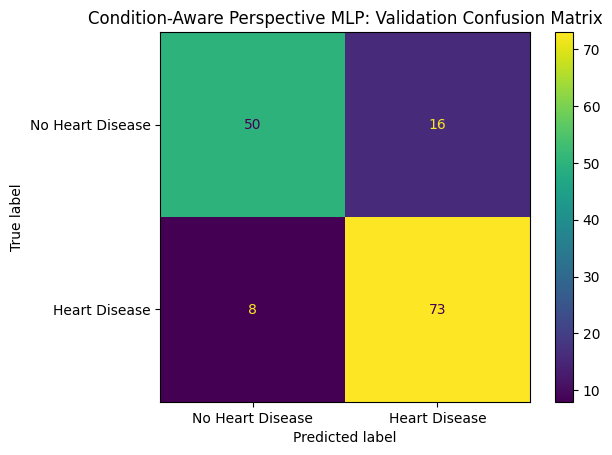

In [181]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_heart_val_array.astype(int),
    condition_average_validation_prediction,

    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title(
    "Condition-Aware Perspective MLP: "
    "Validation Confusion Matrix"
)

plt.show()

In [182]:
#Compare all four MLP systems
condition_mlp_validation_accuracy = accuracy_score(
    y_heart_val_array,
    condition_average_validation_prediction
)

condition_mlp_validation_auc = roc_auc_score(
    y_heart_val_array,
    condition_average_validation_probability
)

four_model_comparison = pd.DataFrame({
    "Model": [
        "Full-Feature MLP",
        "Manual Perspective MLP",
        "Mixed-Similarity Perspective MLP",
        "Condition-Aware Perspective MLP"
    ],

    "Validation Accuracy": [
        full_mlp_validation_accuracy,
        manual_mlp_validation_accuracy,
        automatic_mlp_validation_accuracy,
        condition_mlp_validation_accuracy
    ],

    "Validation ROC-AUC": [
        full_mlp_validation_auc,
        manual_mlp_validation_auc,
        automatic_mlp_validation_auc,
        condition_mlp_validation_auc
    ]
})

display(
    four_model_comparison.round(4)
)

,Model,Validation Accuracy,Validation ROC-AUC
0,Full-Feature MLP,0.8299,0.9012
1,Manual Perspective MLP,0.8299,0.9052
2,Mixed-Similarity Perspective MLP,0.8163,0.8930
3,Condition-Aware Perspective MLP,0.8367,0.9003


In [183]:
#Final validation
all_condition_probabilities = (
    condition_validation_probability_matrix
    .to_numpy()
)

assert len(condition_models) == 4
assert len(condition_preprocessors) == 4

assert (
    condition_validation_probability_matrix.shape
    ==
    (len(X_heart_val), 4)
)

assert np.isfinite(
    all_condition_probabilities
).all()

assert np.all(
    condition_average_validation_probability >= 0
)

assert np.all(
    condition_average_validation_probability <= 1
)

assert set(
    np.unique(
        condition_average_validation_prediction
    )
).issubset({0, 1})

print(
    "Condition-aware perspective MLP validation passed."
)

Condition-aware perspective MLP validation passed.


---------------------------------------------------------------------------
# Part 8: Leakage-Safe OOF Learned Fusion

Out-of-fold predictions from the condition-aware perspective MLPs are used to train a logistic fusion model. Each OOF prediction is generated by a model that did not train on that observation.

In [184]:
#Imports
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

In [185]:
#Define OOF cross-validation
OOF_FOLDS = 5

oof_cv = StratifiedKFold(
    n_splits=OOF_FOLDS,
    shuffle=True,
    random_state=SEED
)

perspective_names = list(
    condition_aware_perspectives.keys()
)

print("Number of perspectives:", len(perspective_names))
print("OOF folds:", OOF_FOLDS)

Number of perspectives: 4
OOF folds: 5


In [186]:
#Prepare OOF storage
number_of_development_samples = len(
    X_heart_dev
)

number_of_perspectives = len(
    condition_aware_perspectives
)

oof_probability_matrix = np.zeros(
    (
        number_of_development_samples,
        number_of_perspectives
    ),
    dtype=np.float32
)

oof_best_epochs = {
    perspective_name: []
    for perspective_name
    in perspective_names
}

print(
    "OOF matrix shape:",
    oof_probability_matrix.shape
)

OOF matrix shape: (587, 4)


In [187]:
#Generate OOF probabilities
for fold_number, (
    fold_train_positions,
    fold_holdout_positions
) in enumerate(
    oof_cv.split(
        X_heart_dev,
        y_heart_dev
    ),
    start=1
):

    print("=" * 65)
    print(f"OOF Fold {fold_number}/{OOF_FOLDS}")

    # Positional indexing
    X_fold_train = X_heart_dev.iloc[
        fold_train_positions
    ]

    y_fold_train = y_heart_dev.iloc[
        fold_train_positions
    ]

    X_fold_holdout = X_heart_dev.iloc[
        fold_holdout_positions
    ]

    # Create a small internal validation set
    # only for early stopping
    (
        X_fold_fit,
        X_fold_early_stop,
        y_fold_fit,
        y_fold_early_stop
    ) = train_test_split(
        X_fold_train,
        y_fold_train,
        test_size=0.15,
        random_state=SEED + fold_number,
        stratify=y_fold_train
    )

    for perspective_index, (
        perspective_name,
        perspective_features
    ) in enumerate(
        condition_aware_perspectives.items()
    ):

        print(
            f"  Training {perspective_name}"
        )

        # New preprocessing object for this fold
        fold_preprocessor = (
            build_perspective_preprocessor(
                perspective_features
            )
        )

        # Fit only on fold-fit data
        X_fit_processed = (
            fold_preprocessor.fit_transform(
                X_fold_fit[
                    perspective_features
                ]
            )
            .astype("float32")
        )

        # Transform internal early-stopping data
        X_early_stop_processed = (
            fold_preprocessor.transform(
                X_fold_early_stop[
                    perspective_features
                ]
            )
            .astype("float32")
        )

        # Transform unseen OOF holdout
        X_holdout_processed = (
            fold_preprocessor.transform(
                X_fold_holdout[
                    perspective_features
                ]
            )
            .astype("float32")
        )

        y_fit_array = (
            y_fold_fit
            .to_numpy()
            .astype("float32")
        )

        y_early_stop_array = (
            y_fold_early_stop
            .to_numpy()
            .astype("float32")
        )

        keras.utils.set_random_seed(
            SEED
            + fold_number * 100
            + perspective_index
        )

        fold_model = build_perspective_mlp(
            input_dimension=(
                X_fit_processed.shape[1]
            ),
            perspective_name=(
                f"{perspective_name}"
                f"_fold_{fold_number}"
            )
        )

        fold_early_stopping = (
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=15,
                restore_best_weights=True,
                verbose=0
            )
        )

        fold_history = fold_model.fit(
            X_fit_processed,
            y_fit_array,

            validation_data=(
                X_early_stop_processed,
                y_early_stop_array
            ),

            epochs=200,
            batch_size=32,

            callbacks=[
                fold_early_stopping
            ],

            verbose=0
        )

        best_epoch = (
            np.argmin(
                fold_history.history[
                    "val_loss"
                ]
            )
            + 1
        )

        oof_best_epochs[
            perspective_name
        ].append(best_epoch)

        # Predict only the unseen fold
        holdout_probabilities = (
            fold_model.predict(
                X_holdout_processed,
                verbose=0
            )
            .ravel()
        )

        oof_probability_matrix[
            fold_holdout_positions,
            perspective_index
        ] = holdout_probabilities

        print(
            "    Best epoch:",
            best_epoch
        )

OOF Fold 1/5
  Training Condition_Perspective_1
    Best epoch: 67
  Training Condition_Perspective_2
    Best epoch: 153
  Training Condition_Perspective_3
    Best epoch: 129
  Training Condition_Perspective_4
    Best epoch: 78
OOF Fold 2/5
  Training Condition_Perspective_1
    Best epoch: 161
  Training Condition_Perspective_2
    Best epoch: 200
  Training Condition_Perspective_3
    Best epoch: 71
  Training Condition_Perspective_4
    Best epoch: 68
OOF Fold 3/5
  Training Condition_Perspective_1
    Best epoch: 104
  Training Condition_Perspective_2
    Best epoch: 61
  Training Condition_Perspective_3
    Best epoch: 47
  Training Condition_Perspective_4
    Best epoch: 32
OOF Fold 4/5
  Training Condition_Perspective_1
    Best epoch: 61
  Training Condition_Perspective_2
    Best epoch: 50
  Training Condition_Perspective_3
    Best epoch: 200
  Training Condition_Perspective_4
    Best epoch: 139
OOF Fold 5/5
  Training Condition_Perspective_1
    Best epoch: 200
  Trainin

In [188]:
#Validate OOF matrix
assert oof_probability_matrix.shape == (
    len(X_heart_dev),
    4
)

assert np.isfinite(
    oof_probability_matrix
).all()

assert np.all(
    oof_probability_matrix >= 0
)

assert np.all(
    oof_probability_matrix <= 1
)

print("OOF probability generation passed.")

OOF probability generation passed.


In [189]:
#Inspect OOF probabilities
oof_probability_df = pd.DataFrame(
    oof_probability_matrix,
    columns=perspective_names,
    index=X_heart_dev.index
)

oof_probability_df["True Label"] = (
    y_heart_dev
)

display(
    oof_probability_df.head()
)

,Condition_Perspective_1,Condition_Perspective_2,Condition_Perspective_3,Condition_Perspective_4,True Label
784,0.948434,0.397199,0.288442,0.508756,1
894,0.581657,0.707401,0.589073,0.449409,0
339,0.858063,0.815730,0.459926,0.566883,1
172,0.143390,0.167019,0.443211,0.293000,0
884,0.836810,0.802033,0.794761,0.908136,1


In [190]:
#Train logistic fusion model
oof_fusion_model = LogisticRegression(
    solver="liblinear",
    C=1.0,
    max_iter=1000,
    random_state=SEED
)

oof_fusion_model.fit(
    oof_probability_matrix,
    y_heart_dev
)

print("OOF logistic fusion training completed.")

OOF logistic fusion training completed.


In [191]:
#Display learned weights
fusion_weights_df = pd.DataFrame({
    "Perspective": perspective_names,
    "Learned Weight": (
        oof_fusion_model.coef_[0]
    )
})

fusion_weights_df = (
    fusion_weights_df
    .sort_values(
        by="Learned Weight",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Fusion intercept:",
    round(
        float(
            oof_fusion_model.intercept_[0]
        ),
        4
    )
)

display(
    fusion_weights_df.round(4)
)

Fusion intercept: -4.2165


,Perspective,Learned Weight
0,Condition_Perspective_1,3.3139
1,Condition_Perspective_2,2.2828
2,Condition_Perspective_4,1.5015
3,Condition_Perspective_3,0.9810


In [192]:
#Determine final training epochs
final_epoch_counts = {}

epoch_summary_rows = []

for perspective_name in perspective_names:

    fold_epochs = oof_best_epochs[
        perspective_name
    ]

    median_epoch = int(
        np.median(fold_epochs)
    )

    final_epoch_counts[
        perspective_name
    ] = max(
        median_epoch,
        1
    )

    epoch_summary_rows.append({
        "Perspective": perspective_name,
        "Fold Best Epochs": str(fold_epochs),
        "Final Median Epoch": (
            final_epoch_counts[
                perspective_name
            ]
        )
    })

epoch_summary_df = pd.DataFrame(
    epoch_summary_rows
)

display(epoch_summary_df)

,Perspective,Fold Best Epochs,Final Median Epoch
0,Condition_Perspective_1,"[np.int64(67), np.int64(161), np.int64(104), n...",104
1,Condition_Perspective_2,"[np.int64(153), np.int64(200), np.int64(61), n...",61
2,Condition_Perspective_3,"[np.int64(129), np.int64(71), np.int64(47), np...",71
3,Condition_Perspective_4,"[np.int64(78), np.int64(68), np.int64(32), np....",78


In [193]:
#Refit perspective models on full development data
final_condition_models = {}
final_condition_preprocessors = {}
final_validation_probabilities = {}

for perspective_index, (
    perspective_name,
    perspective_features
) in enumerate(
    condition_aware_perspectives.items()
):

    print("=" * 60)
    print("Refitting:", perspective_name)
    print("Features:", perspective_features)

    final_preprocessor = (
        build_perspective_preprocessor(
            perspective_features
        )
    )

    # Fit preprocessing on all development data
    X_full_dev_processed = (
        final_preprocessor.fit_transform(
            X_heart_dev[
                perspective_features
            ]
        )
        .astype("float32")
    )

    # Validation is transformed only
    X_validation_processed = (
        final_preprocessor.transform(
            X_heart_val[
                perspective_features
            ]
        )
        .astype("float32")
    )

    keras.utils.set_random_seed(
        SEED + 500 + perspective_index
    )

    final_model = build_perspective_mlp(
        input_dimension=(
            X_full_dev_processed.shape[1]
        ),
        perspective_name=(
            f"{perspective_name}_final"
        )
    )

    number_of_epochs = final_epoch_counts[
        perspective_name
    ]

    final_model.fit(
        X_full_dev_processed,
        y_heart_dev_array,

        epochs=number_of_epochs,
        batch_size=32,
        verbose=0
    )

    validation_probabilities = (
        final_model.predict(
            X_validation_processed,
            verbose=0
        )
        .ravel()
    )

    final_condition_models[
        perspective_name
    ] = final_model

    final_condition_preprocessors[
        perspective_name
    ] = final_preprocessor

    final_validation_probabilities[
        perspective_name
    ] = validation_probabilities

    print(
        "Final training epochs:",
        number_of_epochs
    )

Refitting: Condition_Perspective_1
Features: ['ST_Slope', 'FastingBS', 'Sex']
Final training epochs: 104
Refitting: Condition_Perspective_2
Features: ['ChestPainType', 'Oldpeak', 'RestingECG']
Final training epochs: 61
Refitting: Condition_Perspective_3
Features: ['MaxHR', 'Cholesterol', 'RestingBP']
Final training epochs: 71
Refitting: Condition_Perspective_4
Features: ['ExerciseAngina', 'Age']
Final training epochs: 78


In [194]:
#Create final validation probability matrix
final_validation_probability_df = pd.DataFrame(
    final_validation_probabilities,
    index=X_heart_val.index
)

display(
    final_validation_probability_df.head()
)

,Condition_Perspective_1,Condition_Perspective_2,Condition_Perspective_3,Condition_Perspective_4
192,0.160546,0.101848,0.338972,0.266093
167,0.160546,0.101848,0.755156,0.266093
825,0.842455,0.295315,0.427853,0.514263
36,0.932796,0.850363,0.809846,0.851259
744,0.442412,0.837855,0.339243,0.845679


In [195]:
#Equal fusion using the same refitted models
refit_equal_validation_probability = (
    final_validation_probability_df
    .mean(axis=1)
    .to_numpy()
)

refit_equal_validation_prediction = (
    refit_equal_validation_probability
    >= 0.50
).astype(int)

In [196]:
#OOF learned-fusion validation prediction
learned_validation_probability = (
    oof_fusion_model.predict_proba(
        final_validation_probability_df[
            perspective_names
        ].to_numpy()
    )[:, 1]
)

learned_validation_prediction = (
    learned_validation_probability
    >= 0.50
).astype(int)

In [197]:
#Compare equal and learned fusion
def create_compact_metric_row(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability
        )
    }

In [198]:
fusion_comparison_df = pd.DataFrame(
    [
        create_compact_metric_row(
            model_name=(
                "Condition-Aware Equal Fusion"
            ),
            y_true=y_heart_val_array,
            y_pred=(
                refit_equal_validation_prediction
            ),
            y_probability=(
                refit_equal_validation_probability
            )
        ),

        create_compact_metric_row(
            model_name=(
                "Condition-Aware OOF Learned Fusion"
            ),
            y_true=y_heart_val_array,
            y_pred=(
                learned_validation_prediction
            ),
            y_probability=(
                learned_validation_probability
            )
        )
    ]
)

display(
    fusion_comparison_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Condition-Aware Equal Fusion,0.8095,0.8193,0.8395,0.8293,0.8859
1,Condition-Aware OOF Learned Fusion,0.8163,0.8293,0.8395,0.8344,0.8939


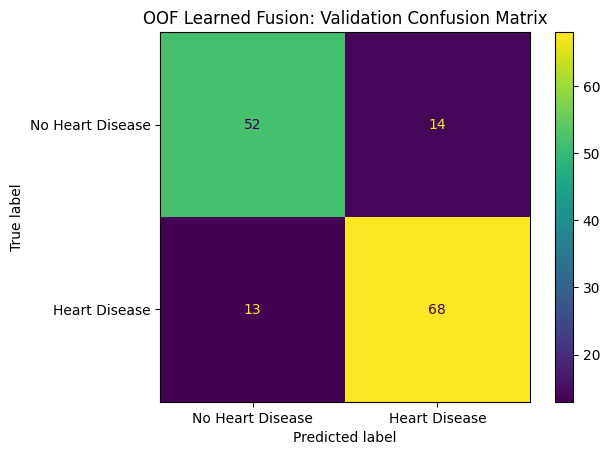

In [199]:
#Learned-fusion confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_heart_val_array.astype(int),
    learned_validation_prediction,

    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title(
    "OOF Learned Fusion: "
    "Validation Confusion Matrix"
)

plt.show()

In [200]:
#Final validation
assert oof_probability_matrix.shape == (
    len(X_heart_dev),
    4
)

assert (
    final_validation_probability_df.shape
    ==
    (len(X_heart_val), 4)
)

assert np.isfinite(
    learned_validation_probability
).all()

assert np.all(
    learned_validation_probability >= 0
)

assert np.all(
    learned_validation_probability <= 1
)

assert set(
    np.unique(
        learned_validation_prediction
    )
).issubset({0, 1})

print(
    "OOF learned-fusion validation passed."
)

OOF learned-fusion validation passed.


Complete Neural Model Comparison

In [201]:
#Comparison function
def make_model_result(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability
        )
    }

In [202]:
#Build the complete comparison table
y_validation_true = (
    y_heart_val_array
    .astype(int)
)

all_model_results = [
    make_model_result(
        model_name="Full-Feature MLP",

        y_true=y_validation_true,
        y_pred=y_val_pred,
        y_probability=y_val_prob
    ),

    make_model_result(
        model_name="Manual Perspective MLP (Equal Fusion)",

        y_true=y_validation_true,

        y_pred=(
            manual_average_validation_prediction
        ),

        y_probability=(
            manual_average_validation_probability
        )
    ),

    make_model_result(
        model_name=(
            "Mixed-Similarity Perspective MLP "
            "(Equal Fusion)"
        ),

        y_true=y_validation_true,

        y_pred=(
            automatic_average_validation_prediction
        ),

        y_probability=(
            automatic_average_validation_probability
        )
    ),

    make_model_result(
        model_name=(
            "Condition-Aware Perspective MLP "
            "(Equal Fusion)"
        ),

        y_true=y_validation_true,

        y_pred=(
            refit_equal_validation_prediction
        ),

        y_probability=(
            refit_equal_validation_probability
        )
    ),

    make_model_result(
        model_name=(
            "Condition-Aware Perspective MLP "
            "(OOF Learned Fusion)"
        ),

        y_true=y_validation_true,

        y_pred=(
            learned_validation_prediction
        ),

        y_probability=(
            learned_validation_probability
        )
    )
]

all_model_comparison_df = pd.DataFrame(
    all_model_results
)

display(
    all_model_comparison_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Full-Feature MLP,0.8299,0.8415,0.8519,0.8466,0.9012
1,Manual Perspective MLP (Equal Fusion),0.8299,0.8111,0.9012,0.8538,0.9052
2,Mixed-Similarity Perspective MLP (Equal Fusion),0.8163,0.7755,0.9383,0.8492,0.8930
3,Condition-Aware Perspective MLP (Equal Fusion),0.8095,0.8193,0.8395,0.8293,0.8859
4,Condition-Aware Perspective MLP (OOF Learned F...,0.8163,0.8293,0.8395,0.8344,0.8939


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------

#Cardiovascular Dataset

----------------------------------------
---------------------------------------------

# Cardiovascular Experiment

## Part C4: Full-Feature MLP Baseline

The cardiovascular training pool is divided into development and validation sets. The test set remains untouched until all model configurations have been finalized.

In [203]:
#Verify existing variables
required_cardio_variables = [
    "X_cardio_train",
    "X_cardio_test",
    "y_cardio_train",
    "y_cardio_test",
    "cardio_preprocessor"
]

for variable_name in required_cardio_variables:
    assert variable_name in globals(), (
        f"{variable_name} is missing. "
        "Run the cardiovascular preprocessing section first."
    )

print("Required cardiovascular variables are available.")

Required cardiovascular variables are available.


In [204]:
#Fixed development-validation split
CARDIO_SEED = 42

(
    X_cardio_dev,
    X_cardio_val,
    y_cardio_dev,
    y_cardio_val
) = train_test_split(
    X_cardio_train,
    y_cardio_train,

    test_size=0.20,
    random_state=CARDIO_SEED,
    stratify=y_cardio_train
)

print("Cardiovascular development set:")
print(X_cardio_dev.shape)

print("\nCardiovascular validation set:")
print(X_cardio_val.shape)

print("\nUntouched cardiovascular test set:")
print(X_cardio_test.shape)

Cardiovascular development set:
(43910, 11)

Cardiovascular validation set:
(10978, 11)

Untouched cardiovascular test set:
(13722, 11)


In [205]:
#Check class distribution
cardio_split_distribution = pd.DataFrame({
    "Development (%)": (
        y_cardio_dev
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),

    "Validation (%)": (
        y_cardio_val
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),

    "Test (%)": (
        y_cardio_test
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
})

cardio_split_distribution.index = [
    "No Cardiovascular Disease",
    "Cardiovascular Disease"
]

display(
    cardio_split_distribution.round(2)
)

,Development (%),Validation (%),Test (%)
No Cardiovascular Disease,50.53,50.53,50.53
Cardiovascular Disease,49.47,49.47,49.47


In [207]:
#Create leakage-safe preprocessor
from sklearn.base import clone

cardio_mlp_preprocessor = clone(
    cardio_preprocessor
)

# Fit only on development data
X_cardio_dev_processed = (
    cardio_mlp_preprocessor.fit_transform(
        X_cardio_dev
    )
)

# Validation data is transformed only
X_cardio_val_processed = (
    cardio_mlp_preprocessor.transform(
        X_cardio_val
    )
)

print(
    "Processed development shape:",
    X_cardio_dev_processed.shape
)

print(
    "Processed validation shape:",
    X_cardio_val_processed.shape
)

Processed development shape: (43910, 15)
Processed validation shape: (10978, 15)


In [208]:
#Validate and convert arrays
assert (
    X_cardio_dev_processed.shape[1]
    ==
    X_cardio_val_processed.shape[1]
)

assert np.isfinite(
    X_cardio_dev_processed
).all()

assert np.isfinite(
    X_cardio_val_processed
).all()

X_cardio_dev_processed = (
    X_cardio_dev_processed
    .astype("float32")
)

X_cardio_val_processed = (
    X_cardio_val_processed
    .astype("float32")
)

y_cardio_dev_array = (
    y_cardio_dev
    .to_numpy()
    .astype("float32")
)

y_cardio_val_array = (
    y_cardio_val
    .to_numpy()
    .astype("float32")
)

print(
    "Cardiovascular MLP preprocessing passed."
)

Cardiovascular MLP preprocessing passed.


In [209]:
#Build the full-feature MLP
def build_cardio_full_feature_mlp(
    input_dimension
):
    model = keras.Sequential(
        [
            keras.Input(
                shape=(input_dimension,),
                name="cardio_features"
            ),

            layers.Dense(
                units=16,
                activation="relu",
                name="hidden_layer_1"
            ),

            layers.Dropout(
                rate=0.20,
                name="dropout_layer"
            ),

            layers.Dense(
                units=8,
                activation="relu",
                name="hidden_layer_2"
            ),

            layers.Dense(
                units=1,
                activation="sigmoid",
                name="cardio_probability"
            )
        ],
        name="cardio_full_feature_mlp"
    )

    return model

In [210]:
#Initialize model
keras.backend.clear_session()

keras.utils.set_random_seed(
    CARDIO_SEED
)

cardio_full_mlp = (
    build_cardio_full_feature_mlp(
        input_dimension=(
            X_cardio_dev_processed.shape[1]
        )
    )
)

cardio_full_mlp.summary()

Model: "cardio_full_feature_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cardio_probability (Dense)      │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [211]:
#Compile model
cardio_full_mlp.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.AUC(
            name="auc"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        )
    ]
)

print(
    "Cardiovascular full-feature MLP compiled."
)

Cardiovascular full-feature MLP compiled.


In [212]:
#Early stopping
cardio_early_stopping = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",

        patience=12,

        restore_best_weights=True,
        verbose=1
    )
)

In [213]:
#Train model
cardio_full_history = (
    cardio_full_mlp.fit(
        X_cardio_dev_processed,
        y_cardio_dev_array,

        validation_data=(
            X_cardio_val_processed,
            y_cardio_val_array
        ),

        epochs=150,
        batch_size=128,

        callbacks=[
            cardio_early_stopping
        ],

        verbose=1
    )
)

Epoch 1/150
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6560 - auc: 0.7308 - loss: 0.6290 - precision: 0.6244 - recall: 0.7647 - val_accuracy: 0.7259 - val_auc: 0.7861 - val_loss: 0.5700 - val_precision: 0.7564 - val_recall: 0.6579
Epoch 2/150
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7185 - auc: 0.7778 - loss: 0.5717 - precision: 0.7397 - recall: 0.6649 - val_accuracy: 0.7317 - val_auc: 0.7948 - val_loss: 0.5526 - val_precision: 0.7473 - val_recall: 0.6916
Epoch 3/150
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7246 - auc: 0.7861 - loss: 0.5619 - precision: 0.7377 - recall: 0.6878 - val_accuracy: 0.7328 - val_auc: 0.7973 - val_loss: 0.5486 - val_precision: 0.7439 - val_recall: 0.7013
Epoch 4/150
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7265 - auc: 0.7894 - loss: 0.5579 - precision: 0.7375 - recall: 0.6941 - val_accuracy: 0.7347 - val_auc: 0.7990 - val_loss: 0.5465 - val_precision: 0.7438 - val_recall: 0.7076
Epoch 5/150
344/344 ━━━━━━━━

In [ ]:
#Training summary
cardio_epochs_completed = len(
    cardio_full_history.history["loss"]
)

cardio_best_epoch = (
    np.argmin(
        cardio_full_history.history[
            "val_loss"
        ]
    )
    + 1
)

cardio_best_validation_loss = np.min(
    cardio_full_history.history[
        "val_loss"
    ]
)

print(
    "Epochs completed:",
    cardio_epochs_completed
)

print(
    "Best epoch:",
    cardio_best_epoch
)

print(
    "Best validation loss:",
    round(
        float(
            cardio_best_validation_loss
        ),
        4
    )
)

Epochs completed: 82
Best epoch: 70
Best validation loss: 0.5391


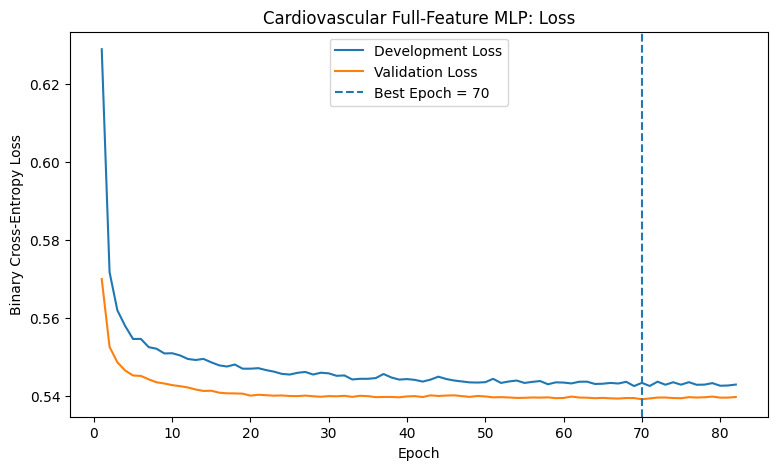

In [ ]:
#Plot loss
cardio_training_epochs = range(
    1,
    cardio_epochs_completed + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    cardio_training_epochs,
    cardio_full_history.history["loss"],
    label="Development Loss"
)

plt.plot(
    cardio_training_epochs,
    cardio_full_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)

plt.axvline(
    cardio_best_epoch,
    linestyle="--",
    label=(
        f"Best Epoch = "
        f"{cardio_best_epoch}"
    )
)

plt.title(
    "Cardiovascular Full-Feature MLP: Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.legend()
plt.show()

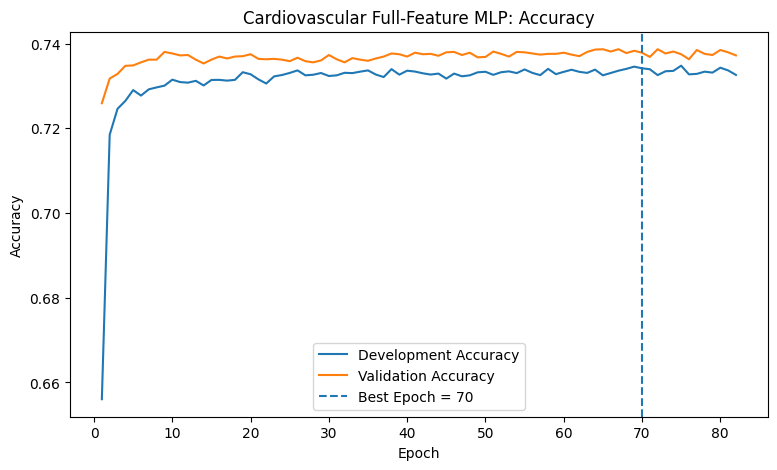

In [ ]:
#Plot accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    cardio_training_epochs,
    cardio_full_history.history[
        "accuracy"
    ],
    label="Development Accuracy"
)

plt.plot(
    cardio_training_epochs,
    cardio_full_history.history[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)

plt.axvline(
    cardio_best_epoch,
    linestyle="--",
    label=(
        f"Best Epoch = "
        f"{cardio_best_epoch}"
    )
)

plt.title(
    "Cardiovascular Full-Feature MLP: Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

In [ ]:
cardio_full_val_probability = (
    cardio_full_mlp.predict(
        X_cardio_val_processed,
        verbose=0
    )
    .ravel()
)

cardio_full_val_prediction = (
    cardio_full_val_probability >= 0.50
).astype(int)

In [ ]:
#Calculate metrics
cardio_full_validation_accuracy = (
    accuracy_score(
        y_cardio_val_array,
        cardio_full_val_prediction
    )
)

cardio_full_validation_precision = (
    precision_score(
        y_cardio_val_array,
        cardio_full_val_prediction,
        zero_division=0
    )
)

cardio_full_validation_recall = (
    recall_score(
        y_cardio_val_array,
        cardio_full_val_prediction,
        zero_division=0
    )
)

cardio_full_validation_f1 = (
    f1_score(
        y_cardio_val_array,
        cardio_full_val_prediction,
        zero_division=0
    )
)

cardio_full_validation_auc = (
    roc_auc_score(
        y_cardio_val_array,
        cardio_full_val_probability
    )
)

In [ ]:
#Baseline result table
cardio_full_mlp_result_df = pd.DataFrame({
    "Model": [
        "Cardiovascular Full-Feature MLP"
    ],

    "Accuracy": [
        cardio_full_validation_accuracy
    ],

    "Precision": [
        cardio_full_validation_precision
    ],

    "Recall": [
        cardio_full_validation_recall
    ],

    "F1-score": [
        cardio_full_validation_f1
    ],

    "ROC-AUC": [
        cardio_full_validation_auc
    ],

    "Best Epoch": [
        cardio_best_epoch
    ]
})

display(
    cardio_full_mlp_result_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best Epoch
0,Cardiovascular Full-Feature MLP,0.7378,0.7681,0.6734,0.7176,0.8024,70


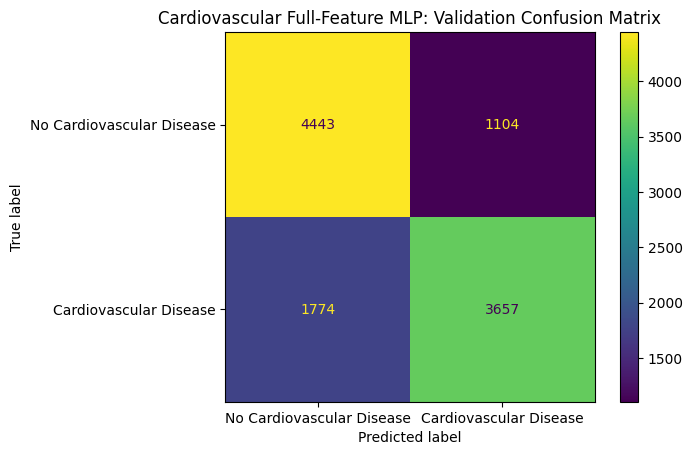

In [ ]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_cardio_val_array.astype(int),
    cardio_full_val_prediction,

    display_labels=[
        "No Cardiovascular Disease",
        "Cardiovascular Disease"
    ]
)

plt.title(
    "Cardiovascular Full-Feature MLP: "
    "Validation Confusion Matrix"
)

plt.show()

In [ ]:
#Final validation
assert len(
    cardio_full_val_probability
) == len(
    y_cardio_val_array
)

assert np.isfinite(
    cardio_full_val_probability
).all()

assert np.all(
    cardio_full_val_probability >= 0
)

assert np.all(
    cardio_full_val_probability <= 1
)

assert set(
    np.unique(
        cardio_full_val_prediction
    )
).issubset({0, 1})

print(
    "Cardiovascular full-feature MLP "
    "validation passed."
)

Cardiovascular full-feature MLP validation passed.


#Cardiovascular Manual Perspective MLP

In [ ]:
#Manual perspectives define
cardio_manual_perspectives = {
    "Demographic_Body": [
        "age_years",
        "gender",
        "height",
        "weight"
    ],

    "Blood_Pressure": [
        "ap_hi",
        "ap_lo"
    ],

    "Metabolic": [
        "cholesterol",
        "gluc"
    ],

    "Lifestyle": [
        "smoke",
        "alco",
        "active"
    ]
}

for perspective_name, features in (
    cardio_manual_perspectives.items()
):
    print(
        perspective_name,
        "->",
        features
    )

Demographic_Body -> ['age_years', 'gender', 'height', 'weight']
Blood_Pressure -> ['ap_hi', 'ap_lo']
Metabolic -> ['cholesterol', 'gluc']
Lifestyle -> ['smoke', 'alco', 'active']


In [ ]:
#Validate groups
all_cardio_manual_features = []

for feature_group in (
    cardio_manual_perspectives.values()
):
    all_cardio_manual_features.extend(
        feature_group
    )

assert len(
    cardio_manual_perspectives
) == 4

assert len(
    all_cardio_manual_features
) == 11

assert len(
    set(all_cardio_manual_features)
) == 11

assert set(
    all_cardio_manual_features
) == set(
    X_cardio_dev.columns
)

print(
    "Cardiovascular manual perspectives passed."
)

Cardiovascular manual perspectives passed.


In [ ]:
#Perspective-specific preprocessor
def build_cardio_perspective_preprocessor(
    feature_list
):
    numerical_features = [
        feature
        for feature in feature_list
        if feature in cardio_continuous_features
    ]

    categorical_features = [
        feature
        for feature in feature_list
        if feature in cardio_categorical_features
    ]

    transformers = []

    if len(numerical_features) > 0:
        numerical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]
        )

        transformers.append(
            (
                "numeric",
                numerical_pipeline,
                numerical_features
            )
        )

    if len(categorical_features) > 0:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop="if_binary",
                        sparse_output=False
                    )
                )
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )

In [ ]:
#Small perspective MLP
def build_cardio_perspective_mlp(
    input_dimension,
    perspective_name
):
    model = keras.Sequential(
        [
            keras.Input(
                shape=(input_dimension,),
                name=f"{perspective_name}_input"
            ),

            layers.Dense(
                units=8,
                activation="relu",
                name=f"{perspective_name}_hidden_1"
            ),

            layers.Dropout(
                rate=0.15,
                name=f"{perspective_name}_dropout"
            ),

            layers.Dense(
                units=4,
                activation="relu",
                name=f"{perspective_name}_hidden_2"
            ),

            layers.Dense(
                units=1,
                activation="sigmoid",
                name=f"{perspective_name}_output"
            )
        ],
        name=f"{perspective_name}_mlp"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss=keras.losses.BinaryCrossentropy(),

        metrics=[
            keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),

            keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    return model

In [ ]:
#Train all four perspective MLPs
cardio_manual_models = {}
cardio_manual_preprocessors = {}
cardio_manual_histories = {}
cardio_manual_validation_probabilities = {}

cardio_manual_individual_results = []

for perspective_index, (
    perspective_name,
    perspective_features
) in enumerate(
    cardio_manual_perspectives.items()
):

    print("=" * 65)
    print("Training:", perspective_name)
    print("Features:", perspective_features)

    perspective_preprocessor = (
        build_cardio_perspective_preprocessor(
            perspective_features
        )
    )

    # Fit only on cardiovascular development data
    X_perspective_dev = (
        perspective_preprocessor.fit_transform(
            X_cardio_dev[
                perspective_features
            ]
        )
        .astype("float32")
    )

    # Validation data is transformed only
    X_perspective_val = (
        perspective_preprocessor.transform(
            X_cardio_val[
                perspective_features
            ]
        )
        .astype("float32")
    )

    input_dimension = (
        X_perspective_dev.shape[1]
    )

    keras.utils.set_random_seed(
        CARDIO_SEED
        + 100
        + perspective_index
    )

    perspective_model = (
        build_cardio_perspective_mlp(
            input_dimension=input_dimension,
            perspective_name=perspective_name
        )
    )

    perspective_early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=12,
            restore_best_weights=True,
            verbose=0
        )
    )

    perspective_history = (
        perspective_model.fit(
            X_perspective_dev,
            y_cardio_dev_array,

            validation_data=(
                X_perspective_val,
                y_cardio_val_array
            ),

            epochs=150,
            batch_size=128,

            callbacks=[
                perspective_early_stopping
            ],

            verbose=0
        )
    )

    validation_probability = (
        perspective_model.predict(
            X_perspective_val,
            verbose=0
        )
        .ravel()
    )

    validation_prediction = (
        validation_probability >= 0.50
    ).astype(int)

    best_epoch = (
        np.argmin(
            perspective_history.history[
                "val_loss"
            ]
        )
        + 1
    )

    individual_accuracy = accuracy_score(
        y_cardio_val_array,
        validation_prediction
    )

    individual_auc = roc_auc_score(
        y_cardio_val_array,
        validation_probability
    )

    cardio_manual_models[
        perspective_name
    ] = perspective_model

    cardio_manual_preprocessors[
        perspective_name
    ] = perspective_preprocessor

    cardio_manual_histories[
        perspective_name
    ] = perspective_history

    cardio_manual_validation_probabilities[
        perspective_name
    ] = validation_probability

    cardio_manual_individual_results.append({
        "Perspective": perspective_name,
        "Features": ", ".join(
            perspective_features
        ),
        "Original Features": len(
            perspective_features
        ),
        "Processed Features": (
            input_dimension
        ),
        "Best Epoch": best_epoch,
        "Validation Accuracy": (
            individual_accuracy
        ),
        "Validation ROC-AUC": (
            individual_auc
        )
    })

    print(
        "Processed dimension:",
        input_dimension
    )

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Validation accuracy:",
        round(
            individual_accuracy,
            4
        )
    )

    print(
        "Validation ROC-AUC:",
        round(
            individual_auc,
            4
        )
    )

Training: Demographic_Body
Features: ['age_years', 'gender', 'height', 'weight']
Processed dimension: 4
Best epoch: 60
Validation accuracy: 0.6288
Validation ROC-AUC: 0.6765
Training: Blood_Pressure
Features: ['ap_hi', 'ap_lo']
Processed dimension: 2
Best epoch: 34
Validation accuracy: 0.7142
Validation ROC-AUC: 0.7561
Training: Metabolic
Features: ['cholesterol', 'gluc']
Processed dimension: 6
Best epoch: 9
Validation accuracy: 0.589
Validation ROC-AUC: 0.596
Training: Lifestyle
Features: ['smoke', 'alco', 'active']
Processed dimension: 3
Best epoch: 3
Validation accuracy: 0.5204
Validation ROC-AUC: 0.5229


In [ ]:
#Individual perspective results
cardio_manual_individual_results_df = (
    pd.DataFrame(
        cardio_manual_individual_results
    )
)

display(
    cardio_manual_individual_results_df.round(4)
)

,Perspective,Features,Original Features,Processed Features,Best Epoch,Validation Accuracy,Validation ROC-AUC
0,Demographic_Body,"age_years, gender, height, weight",4,4,60,0.6288,0.6765
1,Blood_Pressure,"ap_hi, ap_lo",2,2,34,0.7142,0.7561
2,Metabolic,"cholesterol, gluc",2,6,9,0.5890,0.5960
3,Lifestyle,"smoke, alco, active",3,3,3,0.5204,0.5229


In [ ]:
#Equal-probability fusion
cardio_manual_probability_df = pd.DataFrame(
    cardio_manual_validation_probabilities,
    index=X_cardio_val.index
)

cardio_manual_average_probability = (
    cardio_manual_probability_df
    .mean(axis=1)
    .to_numpy()
)

cardio_manual_average_prediction = (
    cardio_manual_average_probability
    >= 0.50
).astype(int)

display(
    cardio_manual_probability_df.head()
)

,Demographic_Body,Blood_Pressure,Metabolic,Lifestyle
34416,0.639675,0.809221,0.561879,0.491019
39111,0.338506,0.338972,0.569194,0.491019
66553,0.511090,0.809221,0.432116,0.472959
19062,0.419450,0.274993,0.432116,0.491019
31750,0.371003,0.293891,0.432116,0.491019


In [ ]:
#Manual-fusion metrics
cardio_manual_validation_accuracy = (
    accuracy_score(
        y_cardio_val_array,
        cardio_manual_average_prediction
    )
)

cardio_manual_validation_precision = (
    precision_score(
        y_cardio_val_array,
        cardio_manual_average_prediction,
        zero_division=0
    )
)

cardio_manual_validation_recall = (
    recall_score(
        y_cardio_val_array,
        cardio_manual_average_prediction,
        zero_division=0
    )
)

cardio_manual_validation_f1 = (
    f1_score(
        y_cardio_val_array,
        cardio_manual_average_prediction,
        zero_division=0
    )
)

cardio_manual_validation_auc = (
    roc_auc_score(
        y_cardio_val_array,
        cardio_manual_average_probability
    )
)

cardio_manual_result_df = pd.DataFrame({
    "Model": [
        "Cardiovascular Manual Perspective MLP"
    ],

    "Accuracy": [
        cardio_manual_validation_accuracy
    ],

    "Precision": [
        cardio_manual_validation_precision
    ],

    "Recall": [
        cardio_manual_validation_recall
    ],

    "F1-score": [
        cardio_manual_validation_f1
    ],

    "ROC-AUC": [
        cardio_manual_validation_auc
    ]
})

display(
    cardio_manual_result_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Cardiovascular Manual Perspective MLP,0.7312,0.7616,0.6647,0.7099,0.7931


In [ ]:
#Full MLP VS Manual Perspective MLP
cardio_full_vs_manual_df = pd.DataFrame(
    [
        {
            "Model": (
                "Cardiovascular Full-Feature MLP"
            ),

            "Accuracy": (
                cardio_full_validation_accuracy
            ),

            "Precision": (
                cardio_full_validation_precision
            ),

            "Recall": (
                cardio_full_validation_recall
            ),

            "F1-score": (
                cardio_full_validation_f1
            ),

            "ROC-AUC": (
                cardio_full_validation_auc
            )
        },

        {
            "Model": (
                "Cardiovascular Manual "
                "Perspective MLP"
            ),

            "Accuracy": (
                cardio_manual_validation_accuracy
            ),

            "Precision": (
                cardio_manual_validation_precision
            ),

            "Recall": (
                cardio_manual_validation_recall
            ),

            "F1-score": (
                cardio_manual_validation_f1
            ),

            "ROC-AUC": (
                cardio_manual_validation_auc
            )
        }
    ]
)

cardio_full_vs_manual_df[
    "Accuracy Change vs Full MLP"
] = (
    cardio_full_vs_manual_df["Accuracy"]
    - cardio_full_validation_accuracy
)

cardio_full_vs_manual_df[
    "AUC Change vs Full MLP"
] = (
    cardio_full_vs_manual_df["ROC-AUC"]
    - cardio_full_validation_auc
)

display(
    cardio_full_vs_manual_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Accuracy Change vs Full MLP,AUC Change vs Full MLP
0,Cardiovascular Full-Feature MLP,0.7378,0.7681,0.6734,0.7176,0.8024,0.0000,0.0000
1,Cardiovascular Manual Perspective MLP,0.7312,0.7616,0.6647,0.7099,0.7931,-0.0066,-0.0093


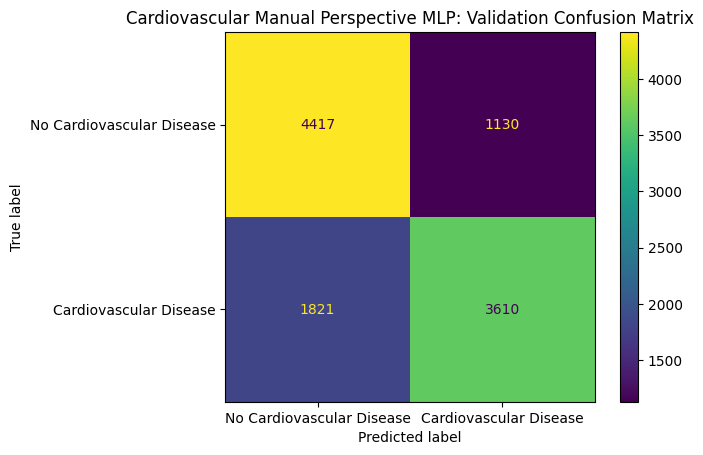

In [ ]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_cardio_val_array.astype(int),
    cardio_manual_average_prediction,

    display_labels=[
        "No Cardiovascular Disease",
        "Cardiovascular Disease"
    ]
)

plt.title(
    "Cardiovascular Manual Perspective MLP: "
    "Validation Confusion Matrix"
)

plt.show()

In [ ]:
#Final validation
assert len(
    cardio_manual_models
) == 4

assert (
    cardio_manual_probability_df.shape
    ==
    (len(X_cardio_val), 4)
)

assert np.isfinite(
    cardio_manual_average_probability
).all()

assert np.all(
    cardio_manual_average_probability >= 0
)

assert np.all(
    cardio_manual_average_probability <= 1
)

assert set(
    np.unique(
        cardio_manual_average_prediction
    )
).issubset({0, 1})

print(
    "Cardiovascular manual perspective "
    "MLP validation passed."
)

Cardiovascular manual perspective MLP validation passed.


## Part C6: Mixed-Similarity Automatic Perspectives

Automatic cardiovascular perspectives are generated from the development features only. Continuous-continuous, categorical-categorical, and mixed-type feature pairs are handled using different similarity measures.

In [ ]:
#Imports
from sklearn.metrics import normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering

In [ ]:
#Correlation-ratio function
def calculate_correlation_ratio(
    categorical_values,
    continuous_values
):
    """
    Calculate correlation ratio eta between one categorical
    feature and one continuous feature.
    """

    pair_data = pd.DataFrame({
        "category": categorical_values,
        "continuous": continuous_values
    }).dropna()

    if pair_data.empty:
        return 0.0

    categories, category_codes = np.unique(
        pair_data["category"],
        return_inverse=True
    )

    continuous_array = (
        pair_data["continuous"]
        .to_numpy(dtype=float)
    )

    overall_mean = np.mean(
        continuous_array
    )

    total_variation = np.sum(
        (
            continuous_array
            - overall_mean
        ) ** 2
    )

    if total_variation == 0:
        return 0.0

    between_group_variation = 0.0

    for category_index in range(
        len(categories)
    ):
        category_values = continuous_array[
            category_codes == category_index
        ]

        if len(category_values) == 0:
            continue

        category_mean = np.mean(
            category_values
        )

        between_group_variation += (
            len(category_values)
            * (
                category_mean
                - overall_mean
            ) ** 2
        )

    eta_squared = (
        between_group_variation
        / total_variation
    )

    eta_squared = np.clip(
        eta_squared,
        0.0,
        1.0
    )

    return float(
        np.sqrt(eta_squared)
    )

In [ ]:
#Single feature-pair similarity function
def calculate_cardio_feature_similarity(
    feature_1,
    feature_2,
    dataframe
):
    feature_1_is_continuous = (
        feature_1
        in cardio_continuous_features
    )

    feature_2_is_continuous = (
        feature_2
        in cardio_continuous_features
    )

    # Continuous–continuous
    if (
        feature_1_is_continuous
        and feature_2_is_continuous
    ):
        similarity = dataframe[
            [feature_1, feature_2]
        ].corr(
            method="spearman"
        ).iloc[0, 1]

        if pd.isna(similarity):
            return 0.0

        return float(
            abs(similarity)
        )

    # Categorical–categorical
    if (
        not feature_1_is_continuous
        and not feature_2_is_continuous
    ):
        pair_data = dataframe[
            [feature_1, feature_2]
        ].dropna()

        if pair_data.empty:
            return 0.0

        similarity = (
            normalized_mutual_info_score(
                pair_data[
                    feature_1
                ].astype(str),

                pair_data[
                    feature_2
                ].astype(str)
            )
        )

        return float(similarity)

    # Continuous–categorical
    if feature_1_is_continuous:
        continuous_feature = feature_1
        categorical_feature = feature_2
    else:
        continuous_feature = feature_2
        categorical_feature = feature_1

    return calculate_correlation_ratio(
        categorical_values=(
            dataframe[
                categorical_feature
            ]
        ),

        continuous_values=(
            dataframe[
                continuous_feature
            ]
        )
    )

In [ ]:
#Build the similarity matrix
X_cardio_dev

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
26758,55.460643,2,162,64.0,120,80,1,1,0,0,1
10323,50.288843,2,171,69.0,110,60,1,1,1,1,1
6834,64.301164,1,172,91.0,130,90,3,1,0,1,1
18222,53.549624,1,162,75.0,110,80,1,1,0,0,1
46672,55.819302,1,155,56.0,130,90,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69369,52.158795,1,169,70.0,150,100,1,2,0,0,1
50335,63.709788,1,154,60.0,140,90,3,1,0,0,0
33847,45.538672,1,152,56.0,140,90,1,1,0,0,1
54981,57.656400,1,154,50.0,110,80,2,1,0,0,1


In [ ]:
cardio_original_features = list(
    X_cardio_dev.columns
)

number_of_cardio_features = len(
    cardio_original_features
)

cardio_similarity_matrix = np.eye(
    number_of_cardio_features,
    dtype=float
)

for feature_index_1 in range(
    number_of_cardio_features
):
    for feature_index_2 in range(
        feature_index_1 + 1,
        number_of_cardio_features
    ):
        feature_1 = cardio_original_features[
            feature_index_1
        ]

        feature_2 = cardio_original_features[
            feature_index_2
        ]

        similarity_value = (
            calculate_cardio_feature_similarity(
                feature_1=feature_1,
                feature_2=feature_2,
                dataframe=X_cardio_dev
            )
        )

        cardio_similarity_matrix[
            feature_index_1,
            feature_index_2
        ] = similarity_value

        cardio_similarity_matrix[
            feature_index_2,
            feature_index_1
        ] = similarity_value

In [ ]:
#Display similarity matrix
cardio_similarity_df = pd.DataFrame(
    cardio_similarity_matrix,
    index=cardio_original_features,
    columns=cardio_original_features
)

display(
    cardio_similarity_df.round(3)
)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
age_years,1.000,0.024,0.086,0.058,0.217,0.154,0.158,0.097,0.046,0.028,0.011
gender,0.024,1.000,0.515,0.155,0.058,0.068,0.001,0.000,0.124,0.033,0.000
height,0.086,0.515,1.000,0.316,0.019,0.033,0.054,0.023,0.198,0.101,0.005
weight,0.058,0.155,0.316,1.000,0.278,0.249,0.141,0.121,0.067,0.070,0.014
ap_hi,0.217,0.058,0.019,0.278,1.000,0.744,0.200,0.107,0.028,0.038,0.002
ap_lo,0.154,0.068,0.033,0.249,0.744,1.000,0.163,0.086,0.029,0.038,0.002
cholesterol,0.158,0.001,0.054,0.141,0.200,0.163,1.000,0.160,0.001,0.002,0.000
gluc,0.097,0.000,0.023,0.121,0.107,0.086,0.160,1.000,0.000,0.001,0.000
smoke,0.046,0.124,0.198,0.067,0.028,0.029,0.001,0.000,1.000,0.135,0.001
alco,0.028,0.033,0.101,0.070,0.038,0.038,0.002,0.001,0.135,1.000,0.001


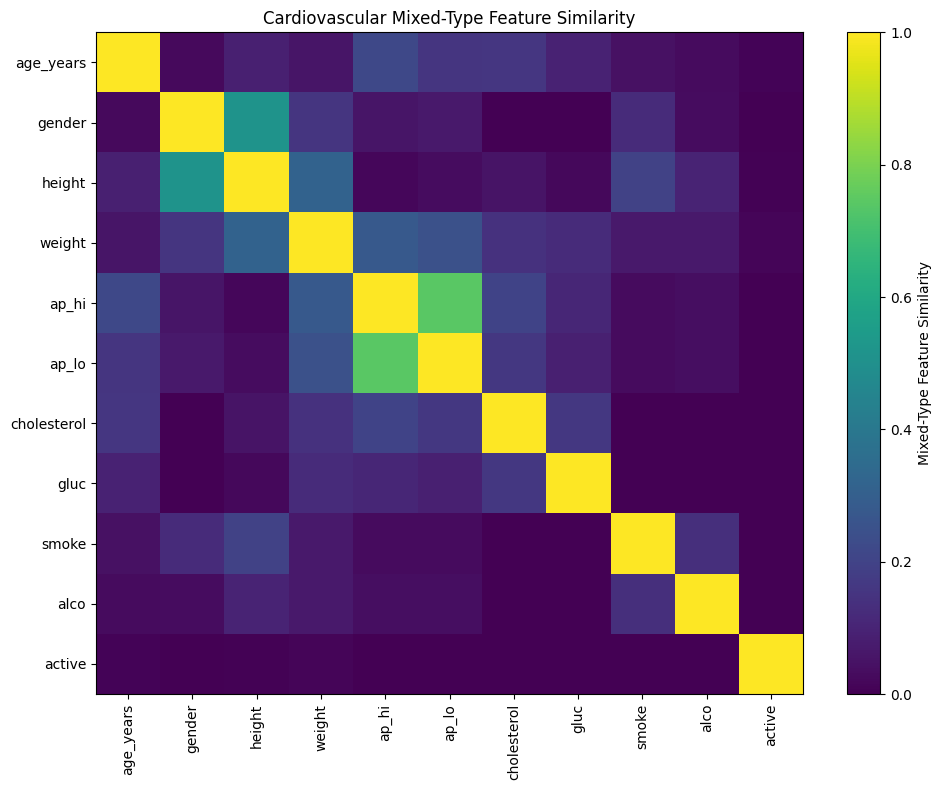

In [ ]:
#Similarity heatmap
plt.figure(figsize=(10, 8))

plt.imshow(
    cardio_similarity_matrix,
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    label="Mixed-Type Feature Similarity"
)

plt.xticks(
    range(number_of_cardio_features),
    cardio_original_features,
    rotation=90
)

plt.yticks(
    range(number_of_cardio_features),
    cardio_original_features
)

plt.title(
    "Cardiovascular Mixed-Type Feature Similarity"
)

plt.tight_layout()
plt.show()

In [ ]:
#Convert similarity into distance
cardio_distance_matrix = (
    1.0
    - cardio_similarity_matrix
)

np.fill_diagonal(
    cardio_distance_matrix,
    0.0
)

cardio_distance_df = pd.DataFrame(
    cardio_distance_matrix,
    index=cardio_original_features,
    columns=cardio_original_features
)

display(
    cardio_distance_df.round(3)
)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
age_years,0.000,0.976,0.914,0.942,0.783,0.846,0.842,0.903,0.954,0.972,0.989
gender,0.976,0.000,0.485,0.845,0.942,0.932,0.999,1.000,0.876,0.967,1.000
height,0.914,0.485,0.000,0.684,0.981,0.967,0.946,0.977,0.802,0.899,0.995
weight,0.942,0.845,0.684,0.000,0.722,0.751,0.859,0.879,0.933,0.930,0.986
ap_hi,0.783,0.942,0.981,0.722,0.000,0.256,0.800,0.893,0.972,0.962,0.998
ap_lo,0.846,0.932,0.967,0.751,0.256,0.000,0.837,0.914,0.971,0.962,0.998
cholesterol,0.842,0.999,0.946,0.859,0.800,0.837,0.000,0.840,0.999,0.998,1.000
gluc,0.903,1.000,0.977,0.879,0.893,0.914,0.840,0.000,1.000,0.999,1.000
smoke,0.954,0.876,0.802,0.933,0.972,0.971,0.999,1.000,0.000,0.865,0.999
alco,0.972,0.967,0.899,0.930,0.962,0.962,0.998,0.999,0.865,0.000,0.999


In [ ]:
#Generate four automatic clusters
NUMBER_OF_CARDIO_AUTO_PERSPECTIVES = 4

try:
    cardio_cluster_model = (
        AgglomerativeClustering(
            n_clusters=(
                NUMBER_OF_CARDIO_AUTO_PERSPECTIVES
            ),
            metric="precomputed",
            linkage="average"
        )
    )

except TypeError:
    # Compatibility with older sklearn versions
    cardio_cluster_model = (
        AgglomerativeClustering(
            n_clusters=(
                NUMBER_OF_CARDIO_AUTO_PERSPECTIVES
            ),
            affinity="precomputed",
            linkage="average"
        )
    )

cardio_cluster_labels = (
    cardio_cluster_model.fit_predict(
        cardio_distance_matrix
    )
)

print(
    "Cluster labels:",
    cardio_cluster_labels
)

Cluster labels: [0 2 2 0 0 0 0 0 2 3 1]


In [ ]:
#Convert cluster labels into perspectives
cardio_mixed_similarity_perspectives = {}

for cluster_number in sorted(
    np.unique(cardio_cluster_labels)
):
    perspective_name = (
        f"Cardio_Auto_Perspective_"
        f"{cluster_number + 1}"
    )

    perspective_features = [
        feature_name

        for feature_name, feature_cluster
        in zip(
            cardio_original_features,
            cardio_cluster_labels
        )

        if feature_cluster == cluster_number
    ]

    cardio_mixed_similarity_perspectives[
        perspective_name
    ] = perspective_features

In [ ]:
for perspective_name, perspective_features in (
    cardio_mixed_similarity_perspectives.items()
):
    print(perspective_name)

    print(
        perspective_features
    )

    print(
        "Group size:",
        len(perspective_features)
    )

    print()

Cardio_Auto_Perspective_1
['age_years', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc']
Group size: 6

Cardio_Auto_Perspective_2
['active']
Group size: 1

Cardio_Auto_Perspective_3
['gender', 'height', 'smoke']
Group size: 3

Cardio_Auto_Perspective_4
['alco']
Group size: 1



In [ ]:
#Summary table
cardio_auto_group_rows = []

for perspective_name, perspective_features in (
    cardio_mixed_similarity_perspectives.items()
):
    cardio_auto_group_rows.append({
        "Perspective": perspective_name,
        "Features": ", ".join(
            perspective_features
        ),
        "Group Size": len(
            perspective_features
        )
    })

cardio_auto_group_summary_df = pd.DataFrame(
    cardio_auto_group_rows
)

display(
    cardio_auto_group_summary_df
)

,Perspective,Features,Group Size
0,Cardio_Auto_Perspective_1,"age_years, weight, ap_hi, ap_lo, cholesterol, ...",6
1,Cardio_Auto_Perspective_2,active,1
2,Cardio_Auto_Perspective_3,"gender, height, smoke",3
3,Cardio_Auto_Perspective_4,alco,1


In [ ]:
#Validate generated perspectives
all_cardio_auto_features = []

for perspective_features in (
    cardio_mixed_similarity_perspectives.values()
):
    all_cardio_auto_features.extend(
        perspective_features
    )

cardio_auto_group_sizes = [
    len(perspective_features)

    for perspective_features in (
        cardio_mixed_similarity_perspectives.values()
    )
]

assert (
    cardio_similarity_matrix.shape
    ==
    (11, 11)
)

assert np.allclose(
    cardio_similarity_matrix,
    cardio_similarity_matrix.T
)

assert np.allclose(
    np.diag(cardio_similarity_matrix),
    1.0
)

assert np.all(
    cardio_similarity_matrix >= 0
)

assert np.all(
    cardio_similarity_matrix <= 1
)

assert len(
    cardio_mixed_similarity_perspectives
) == 4

assert len(
    all_cardio_auto_features
) == 11

assert len(
    set(all_cardio_auto_features)
) == 11

assert set(
    all_cardio_auto_features
) == set(
    cardio_original_features
)

print(
    "Cardiovascular mixed-similarity "
    "perspective generation passed."
)

print(
    "Generated group sizes:",
    cardio_auto_group_sizes
)

Cardiovascular mixed-similarity perspective generation passed.
Generated group sizes: [6, 1, 3, 1]


In [ ]:
#Prepare storage
cardio_auto_models = {}
cardio_auto_preprocessors = {}
cardio_auto_histories = {}
cardio_auto_validation_probabilities = {}

cardio_auto_individual_results = []

In [ ]:
#Train four automatic-perspective MLPs
for perspective_index, (
    perspective_name,
    perspective_features
) in enumerate(
    cardio_mixed_similarity_perspectives.items()
):

    print("=" * 70)
    print("Training:", perspective_name)
    print("Features:", perspective_features)

    # New preprocessing object for this perspective
    auto_preprocessor = (
        build_cardio_perspective_preprocessor(
            perspective_features
        )
    )

    # Fit preprocessing only on development data
    X_auto_dev = (
        auto_preprocessor.fit_transform(
            X_cardio_dev[
                perspective_features
            ]
        )
        .astype("float32")
    )

    # Validation set is transformed only
    X_auto_val = (
        auto_preprocessor.transform(
            X_cardio_val[
                perspective_features
            ]
        )
        .astype("float32")
    )

    input_dimension = X_auto_dev.shape[1]

    keras.utils.set_random_seed(
        CARDIO_SEED
        + 300
        + perspective_index
    )

    auto_model = (
        build_cardio_perspective_mlp(
            input_dimension=input_dimension,
            perspective_name=perspective_name
        )
    )

    auto_early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=12,
            restore_best_weights=True,
            verbose=0
        )
    )

    auto_history = auto_model.fit(
        X_auto_dev,
        y_cardio_dev_array,

        validation_data=(
            X_auto_val,
            y_cardio_val_array
        ),

        epochs=150,
        batch_size=128,

        callbacks=[
            auto_early_stopping
        ],

        verbose=0
    )

    validation_probability = (
        auto_model.predict(
            X_auto_val,
            verbose=0
        )
        .ravel()
    )

    validation_prediction = (
        validation_probability >= 0.50
    ).astype(int)

    best_epoch = (
        np.argmin(
            auto_history.history[
                "val_loss"
            ]
        )
        + 1
    )

    individual_accuracy = accuracy_score(
        y_cardio_val_array,
        validation_prediction
    )

    individual_auc = roc_auc_score(
        y_cardio_val_array,
        validation_probability
    )

    # Save trained objects and predictions
    cardio_auto_models[
        perspective_name
    ] = auto_model

    cardio_auto_preprocessors[
        perspective_name
    ] = auto_preprocessor

    cardio_auto_histories[
        perspective_name
    ] = auto_history

    cardio_auto_validation_probabilities[
        perspective_name
    ] = validation_probability

    cardio_auto_individual_results.append({
        "Perspective": perspective_name,

        "Features": ", ".join(
            perspective_features
        ),

        "Original Features": len(
            perspective_features
        ),

        "Processed Features": input_dimension,

        "Best Epoch": best_epoch,

        "Validation Accuracy": (
            individual_accuracy
        ),

        "Validation ROC-AUC": (
            individual_auc
        )
    })

    print(
        "Processed dimension:",
        input_dimension
    )

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Validation accuracy:",
        round(individual_accuracy, 4)
    )

    print(
        "Validation ROC-AUC:",
        round(individual_auc, 4)
    )

Training: Cardio_Auto_Perspective_1
Features: ['age_years', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc']
Processed dimension: 10
Best epoch: 54
Validation accuracy: 0.736
Validation ROC-AUC: 0.7983
Training: Cardio_Auto_Perspective_2
Features: ['active']
Processed dimension: 1
Best epoch: 13
Validation accuracy: 0.5204
Validation ROC-AUC: 0.5172
Training: Cardio_Auto_Perspective_3
Features: ['gender', 'height', 'smoke']
Processed dimension: 3
Best epoch: 34
Validation accuracy: 0.5142
Validation ROC-AUC: 0.5187
Training: Cardio_Auto_Perspective_4
Features: ['alco']
Processed dimension: 1
Best epoch: 1
Validation accuracy: 0.5053
Validation ROC-AUC: 0.504


In [ ]:
#Construct perspective-probability table
cardio_auto_probability_df = pd.DataFrame(
    cardio_auto_validation_probabilities,
    index=X_cardio_val.index
)

display(
    cardio_auto_probability_df.head()
)

,Cardio_Auto_Perspective_1,Cardio_Auto_Perspective_2,Cardio_Auto_Perspective_3,Cardio_Auto_Perspective_4
34416,0.727684,0.487207,0.496483,0.494536
39111,0.277055,0.487207,0.480857,0.494536
66553,0.777441,0.487207,0.463065,0.494536
19062,0.212179,0.487207,0.506116,0.494536
31750,0.180246,0.487207,0.505171,0.494536


In [ ]:
#Equal-average probability
cardio_auto_average_probability = (
    cardio_auto_probability_df
    .mean(axis=1)
    .to_numpy()
)

cardio_auto_average_prediction = (
    cardio_auto_average_probability
    >= 0.50
).astype(int)

In [ ]:
#Calculate fused metrics
cardio_auto_validation_accuracy = (
    accuracy_score(
        y_cardio_val_array,
        cardio_auto_average_prediction
    )
)

cardio_auto_validation_precision = (
    precision_score(
        y_cardio_val_array,
        cardio_auto_average_prediction,
        zero_division=0
    )
)

cardio_auto_validation_recall = (
    recall_score(
        y_cardio_val_array,
        cardio_auto_average_prediction,
        zero_division=0
    )
)

cardio_auto_validation_f1 = (
    f1_score(
        y_cardio_val_array,
        cardio_auto_average_prediction,
        zero_division=0
    )
)

cardio_auto_validation_auc = (
    roc_auc_score(
        y_cardio_val_array,
        cardio_auto_average_probability
    )
)

In [ ]:
#Result table
cardio_auto_result_df = pd.DataFrame({
    "Model": [
        (
            "Cardiovascular Mixed-Similarity "
            "Perspective MLP"
        )
    ],

    "Accuracy": [
        cardio_auto_validation_accuracy
    ],

    "Precision": [
        cardio_auto_validation_precision
    ],

    "Recall": [
        cardio_auto_validation_recall
    ],

    "F1-score": [
        cardio_auto_validation_f1
    ],

    "ROC-AUC": [
        cardio_auto_validation_auc
    ]
})

display(
    cardio_auto_result_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Cardiovascular Mixed-Similarity Perspective MLP,0.7339,0.7781,0.6465,0.7062,0.7996


In [ ]:
#Three-model comparison
cardio_three_model_comparison_df = pd.DataFrame(
    [
        {
            "Model": (
                "Full-Feature MLP"
            ),

            "Accuracy": (
                cardio_full_validation_accuracy
            ),

            "Precision": (
                cardio_full_validation_precision
            ),

            "Recall": (
                cardio_full_validation_recall
            ),

            "F1-score": (
                cardio_full_validation_f1
            ),

            "ROC-AUC": (
                cardio_full_validation_auc
            )
        },

        {
            "Model": (
                "Manual Perspective MLP "
                "(Equal Fusion)"
            ),

            "Accuracy": (
                cardio_manual_validation_accuracy
            ),

            "Precision": (
                cardio_manual_validation_precision
            ),

            "Recall": (
                cardio_manual_validation_recall
            ),

            "F1-score": (
                cardio_manual_validation_f1
            ),

            "ROC-AUC": (
                cardio_manual_validation_auc
            )
        },

        {
            "Model": (
                "Mixed-Similarity Perspective MLP "
                "(Equal Fusion)"
            ),

            "Accuracy": (
                cardio_auto_validation_accuracy
            ),

            "Precision": (
                cardio_auto_validation_precision
            ),

            "Recall": (
                cardio_auto_validation_recall
            ),

            "F1-score": (
                cardio_auto_validation_f1
            ),

            "ROC-AUC": (
                cardio_auto_validation_auc
            )
        }
    ]
)

cardio_three_model_comparison_df[
    "Accuracy Change vs Full MLP"
] = (
    cardio_three_model_comparison_df[
        "Accuracy"
    ]
    - cardio_full_validation_accuracy
)

cardio_three_model_comparison_df[
    "AUC Change vs Full MLP"
] = (
    cardio_three_model_comparison_df[
        "ROC-AUC"
    ]
    - cardio_full_validation_auc
)

display(
    cardio_three_model_comparison_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Accuracy Change vs Full MLP,AUC Change vs Full MLP
0,Full-Feature MLP,0.7378,0.7681,0.6734,0.7176,0.8024,0.0000,0.0000
1,Manual Perspective MLP (Equal Fusion),0.7312,0.7616,0.6647,0.7099,0.7931,-0.0066,-0.0093
2,Mixed-Similarity Perspective MLP (Equal Fusion),0.7339,0.7781,0.6465,0.7062,0.7996,-0.0039,-0.0028


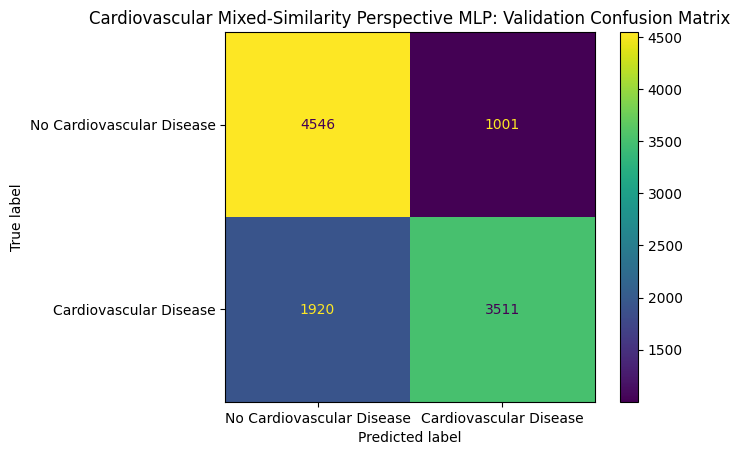

In [ ]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_cardio_val_array.astype(int),
    cardio_auto_average_prediction,

    display_labels=[
        "No Cardiovascular Disease",
        "Cardiovascular Disease"
    ]
)

plt.title(
    "Cardiovascular Mixed-Similarity "
    "Perspective MLP: Validation Confusion Matrix"
)

plt.show()

In [ ]:
#Validate outputs
assert len(
    cardio_auto_models
) == 4

assert (
    cardio_auto_probability_df.shape
    ==
    (len(X_cardio_val), 4)
)

assert np.isfinite(
    cardio_auto_probability_df.to_numpy()
).all()

assert np.isfinite(
    cardio_auto_average_probability
).all()

assert np.all(
    cardio_auto_average_probability >= 0
)

assert np.all(
    cardio_auto_average_probability <= 1
)

assert set(
    np.unique(
        cardio_auto_average_prediction
    )
).issubset({0, 1})

print(
    "Cardiovascular mixed-similarity "
    "perspective MLP validation passed."
)

Cardiovascular mixed-similarity perspective MLP validation passed.


## Part C7: Target-Aware Balanced Cardiovascular Perspectives

Individual target relevance and pairwise predictive complementarity are measured using out-of-fold predictions on the cardiovascular development set.

In [ ]:
from itertools import combinations

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

CARDIO_SCORING_FOLDS = 3

cardio_feature_scoring_cv = StratifiedKFold(
    n_splits=CARDIO_SCORING_FOLDS,
    shuffle=True,
    random_state=CARDIO_SEED
)

print(
    "Cardiovascular feature-scoring folds:",
    CARDIO_SCORING_FOLDS
)

Cardiovascular feature-scoring folds: 3


In [ ]:
#Cross-validated feature scoring function
def calculate_cardio_cross_validated_auc(
    feature_list
):
    """
    Calculate out-of-fold ROC-AUC for selected
    original cardiovascular features.
    """

    scoring_preprocessor = (
        build_cardio_perspective_preprocessor(
            feature_list
        )
    )

    scoring_classifier = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=CARDIO_SEED
    )

    scoring_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                scoring_preprocessor
            ),
            (
                "classifier",
                scoring_classifier
            )
        ]
    )

    out_of_fold_probabilities = cross_val_predict(
        scoring_pipeline,

        X_cardio_dev[
            feature_list
        ],

        y_cardio_dev,

        cv=cardio_feature_scoring_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    auc_value = roc_auc_score(
        y_cardio_dev,
        out_of_fold_probabilities
    )

    return float(auc_value)

In [ ]:
#Individual feature AUC
cardio_feature_names = list(
    X_cardio_dev.columns
)

cardio_individual_feature_auc = {}

for feature_name in cardio_feature_names:

    feature_auc = (
        calculate_cardio_cross_validated_auc(
            [feature_name]
        )
    )

    cardio_individual_feature_auc[
        feature_name
    ] = feature_auc

    print(
        f"{feature_name:15s} "
        f"AUC = {feature_auc:.4f}"
    )

age_years       AUC = 0.6363
gender          AUC = 0.4968
height          AUC = 0.5075
weight          AUC = 0.6009
ap_hi           AUC = 0.7511
ap_lo           AUC = 0.6895
cholesterol     AUC = 0.5928
gluc            AUC = 0.5327
smoke           AUC = 0.5043
alco            AUC = 0.5013
active          AUC = 0.5145


In [ ]:
#Individual relevance table
cardio_individual_feature_auc_df = (
    pd.DataFrame({
        "Feature": list(
            cardio_individual_feature_auc.keys()
        ),

        "Individual CV ROC-AUC": list(
            cardio_individual_feature_auc.values()
        )
    })
    .sort_values(
        by="Individual CV ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cardio_individual_feature_auc_df.round(4)
)

,Feature,Individual CV ROC-AUC
0,ap_hi,0.7511
1,ap_lo,0.6895
2,age_years,0.6363
3,weight,0.6009
4,cholesterol,0.5928
5,gluc,0.5327
6,active,0.5145
7,height,0.5075
8,smoke,0.5043
9,alco,0.5013


In [ ]:
#Initialize pairwise matrices
number_of_cardio_features = len(
    cardio_feature_names
)

cardio_pairwise_auc_matrix = np.zeros(
    (
        number_of_cardio_features,
        number_of_cardio_features
    ),
    dtype=float
)

cardio_pairwise_gain_matrix = np.zeros(
    (
        number_of_cardio_features,
        number_of_cardio_features
    ),
    dtype=float
)

# Individual AUC values on the diagonal
for feature_index, feature_name in enumerate(
    cardio_feature_names
):
    cardio_pairwise_auc_matrix[
        feature_index,
        feature_index
    ] = cardio_individual_feature_auc[
        feature_name
    ]

In [ ]:
#Evaluate all feature pairs
cardio_pairwise_results = []

cardio_feature_pairs = list(
    combinations(
        cardio_feature_names,
        2
    )
)

print(
    "Total cardiovascular feature pairs:",
    len(cardio_feature_pairs)
)

for pair_number, (
    feature_1,
    feature_2
) in enumerate(
    cardio_feature_pairs,
    start=1
):

    pair_auc = (
        calculate_cardio_cross_validated_auc(
            [
                feature_1,
                feature_2
            ]
        )
    )

    best_individual_auc = max(
        cardio_individual_feature_auc[
            feature_1
        ],

        cardio_individual_feature_auc[
            feature_2
        ]
    )

    complementarity_gain = max(
        0.0,
        pair_auc - best_individual_auc
    )

    feature_1_index = (
        cardio_feature_names.index(
            feature_1
        )
    )

    feature_2_index = (
        cardio_feature_names.index(
            feature_2
        )
    )

    cardio_pairwise_auc_matrix[
        feature_1_index,
        feature_2_index
    ] = pair_auc

    cardio_pairwise_auc_matrix[
        feature_2_index,
        feature_1_index
    ] = pair_auc

    cardio_pairwise_gain_matrix[
        feature_1_index,
        feature_2_index
    ] = complementarity_gain

    cardio_pairwise_gain_matrix[
        feature_2_index,
        feature_1_index
    ] = complementarity_gain

    cardio_pairwise_results.append({
        "Feature 1": feature_1,
        "Feature 2": feature_2,

        "Feature 1 AUC": (
            cardio_individual_feature_auc[
                feature_1
            ]
        ),

        "Feature 2 AUC": (
            cardio_individual_feature_auc[
                feature_2
            ]
        ),

        "Pair CV ROC-AUC": pair_auc,

        "Complementarity Gain": (
            complementarity_gain
        )
    })

    if (
        pair_number % 10 == 0
        or pair_number
        == len(cardio_feature_pairs)
    ):
        print(
            f"Completed "
            f"{pair_number}/"
            f"{len(cardio_feature_pairs)} pairs"
        )

Total cardiovascular feature pairs: 55
Completed 10/55 pairs
Completed 20/55 pairs
Completed 30/55 pairs
Completed 40/55 pairs
Completed 50/55 pairs
Completed 55/55 pairs


In [ ]:
#Strongest predictive pairs
cardio_pairwise_results_df = pd.DataFrame(
    cardio_pairwise_results
)

cardio_strongest_pairs_df = (
    cardio_pairwise_results_df
    .sort_values(
        by=[
            "Pair CV ROC-AUC",
            "Complementarity Gain"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cardio_strongest_pairs_df
    .head(15)
    .round(4)
)

,Feature 1,Feature 2,Feature 1 AUC,Feature 2 AUC,Pair CV ROC-AUC,Complementarity Gain
0,age_years,ap_hi,0.6363,0.7511,0.7777,0.0266
1,ap_hi,cholesterol,0.7511,0.5928,0.7678,0.0168
2,weight,ap_hi,0.6009,0.7511,0.7588,0.0077
3,ap_hi,gluc,0.7511,0.5327,0.7554,0.0043
4,ap_hi,active,0.7511,0.5145,0.7551,0.0040
5,height,ap_hi,0.5075,0.7511,0.7535,0.0025
6,ap_hi,smoke,0.7511,0.5043,0.7530,0.0020
7,ap_hi,ap_lo,0.7511,0.6895,0.7530,0.0019
8,gender,ap_hi,0.4968,0.7511,0.7528,0.0017
9,ap_hi,alco,0.7511,0.5013,0.7524,0.0013


In [ ]:
#Most complementary pairs
cardio_most_complementary_pairs_df = (
    cardio_pairwise_results_df
    .sort_values(
        by=[
            "Complementarity Gain",
            "Pair CV ROC-AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cardio_most_complementary_pairs_df
    .head(15)
    .round(4)
)

,Feature 1,Feature 2,Feature 1 AUC,Feature 2 AUC,Pair CV ROC-AUC,Complementarity Gain
0,weight,cholesterol,0.6009,0.5928,0.6492,0.0483
1,age_years,ap_lo,0.6363,0.6895,0.7319,0.0424
2,age_years,cholesterol,0.6363,0.5928,0.6751,0.0388
3,ap_lo,cholesterol,0.6895,0.5928,0.7205,0.0310
4,age_years,weight,0.6363,0.6009,0.6664,0.0302
5,age_years,ap_hi,0.6363,0.7511,0.7777,0.0266
6,weight,ap_lo,0.6009,0.6895,0.7084,0.0188
7,ap_hi,cholesterol,0.7511,0.5928,0.7678,0.0168
8,cholesterol,active,0.5928,0.5145,0.6046,0.0118
9,gluc,active,0.5327,0.5145,0.5444,0.0116


In [ ]:
#Convert matrices to DataFrames
cardio_pairwise_auc_df = pd.DataFrame(
    cardio_pairwise_auc_matrix,
    index=cardio_feature_names,
    columns=cardio_feature_names
)

cardio_pairwise_gain_df = pd.DataFrame(
    cardio_pairwise_gain_matrix,
    index=cardio_feature_names,
    columns=cardio_feature_names
)

print("Pairwise cardiovascular ROC-AUC:")

display(
    cardio_pairwise_auc_df.round(3)
)

print(
    "\nPairwise complementarity gain:"
)

display(
    cardio_pairwise_gain_df.round(3)
)

Pairwise cardiovascular ROC-AUC:


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
age_years,0.636,0.637,0.637,0.666,0.778,0.732,0.675,0.643,0.636,0.636,0.638
gender,0.637,0.497,0.511,0.602,0.753,0.693,0.597,0.535,0.507,0.500,0.511
height,0.637,0.511,0.507,0.611,0.754,0.696,0.593,0.537,0.510,0.508,0.522
weight,0.666,0.602,0.611,0.601,0.759,0.708,0.649,0.611,0.602,0.601,0.603
ap_hi,0.778,0.753,0.754,0.759,0.751,0.753,0.768,0.755,0.753,0.752,0.755
ap_lo,0.732,0.693,0.696,0.708,0.753,0.690,0.721,0.700,0.692,0.692,0.697
cholesterol,0.675,0.597,0.593,0.649,0.768,0.721,0.593,0.599,0.598,0.595,0.605
gluc,0.643,0.535,0.537,0.611,0.755,0.700,0.599,0.533,0.536,0.534,0.544
smoke,0.636,0.507,0.510,0.602,0.753,0.692,0.598,0.536,0.504,0.503,0.518
alco,0.636,0.500,0.508,0.601,0.752,0.692,0.595,0.534,0.503,0.501,0.515



Pairwise complementarity gain:


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
age_years,0.000,0.000,0.000,0.030,0.027,0.042,0.039,0.006,0.000,0.000,0.002
gender,0.000,0.000,0.003,0.001,0.002,0.004,0.004,0.002,0.002,0.000,0.000
height,0.000,0.003,0.000,0.010,0.002,0.007,0.000,0.004,0.003,0.001,0.007
weight,0.030,0.001,0.010,0.000,0.008,0.019,0.048,0.010,0.001,0.000,0.002
ap_hi,0.027,0.002,0.002,0.008,0.000,0.002,0.017,0.004,0.002,0.001,0.004
ap_lo,0.042,0.004,0.007,0.019,0.002,0.000,0.031,0.010,0.003,0.002,0.007
cholesterol,0.039,0.004,0.000,0.048,0.017,0.031,0.000,0.006,0.005,0.002,0.012
gluc,0.006,0.002,0.004,0.010,0.004,0.010,0.006,0.000,0.003,0.002,0.012
smoke,0.000,0.002,0.003,0.001,0.002,0.003,0.005,0.003,0.000,0.000,0.003
alco,0.000,0.000,0.001,0.000,0.001,0.002,0.002,0.002,0.000,0.000,0.001


In [ ]:
#Validation checks
assert len(
    cardio_individual_feature_auc
) == 11

assert len(
    cardio_pairwise_results
) == 55

assert (
    cardio_pairwise_auc_matrix.shape
    == (11, 11)
)

assert (
    cardio_pairwise_gain_matrix.shape
    == (11, 11)
)

assert np.allclose(
    cardio_pairwise_auc_matrix,
    cardio_pairwise_auc_matrix.T
)

assert np.allclose(
    cardio_pairwise_gain_matrix,
    cardio_pairwise_gain_matrix.T
)

assert np.all(
    cardio_pairwise_gain_matrix >= 0
)

assert np.isfinite(
    cardio_pairwise_auc_matrix
).all()

assert np.isfinite(
    cardio_pairwise_gain_matrix
).all()

print(
    "Cardiovascular target-aware "
    "feature scoring passed."
)

Cardiovascular target-aware feature scoring passed.


In [ ]:
#Verify required results
required_cardio_target_objects = [
    "cardio_feature_names",
    "cardio_individual_feature_auc",
    "cardio_pairwise_auc_matrix",
    "cardio_pairwise_gain_matrix",
    "cardio_similarity_matrix"
]

for object_name in required_cardio_target_objects:
    assert object_name in globals(), (
        f"{object_name} is missing. "
        "Run Part C7A first."
    )

print(
    "All cardiovascular target-aware "
    "scoring objects are available."
)

All cardiovascular target-aware scoring objects are available.


In [ ]:
#Normalize pairwise scores
# Pairwise ROC-AUC:
# AUC 0.50 -> 0
# AUC 1.00 -> 1
cardio_normalized_pair_auc = np.clip(
    (
        cardio_pairwise_auc_matrix
        - 0.50
    ) / 0.50,
    0.0,
    1.0
)

# Complementarity gain normalization
cardio_maximum_gain = float(
    cardio_pairwise_gain_matrix.max()
)

if cardio_maximum_gain > 0:
    cardio_normalized_pair_gain = (
        cardio_pairwise_gain_matrix
        / cardio_maximum_gain
    )
else:
    cardio_normalized_pair_gain = (
        np.zeros_like(
            cardio_pairwise_gain_matrix
        )
    )

# Similarity already lies between 0 and 1
cardio_normalized_similarity = np.clip(
    cardio_similarity_matrix,
    0.0,
    1.0
)

print(
    "Maximum complementarity gain:",
    round(cardio_maximum_gain, 4)
)

Maximum complementarity gain: 0.0483


In [ ]:
#Define affinity weights
CARDIO_PAIR_AUC_WEIGHT = 0.50
CARDIO_GAIN_WEIGHT = 0.30
CARDIO_SIMILARITY_WEIGHT = 0.20

assert np.isclose(
    CARDIO_PAIR_AUC_WEIGHT
    + CARDIO_GAIN_WEIGHT
    + CARDIO_SIMILARITY_WEIGHT,
    1.0
)

print(
    "Pair predictive AUC weight:",
    CARDIO_PAIR_AUC_WEIGHT
)

print(
    "Complementarity weight:",
    CARDIO_GAIN_WEIGHT
)

print(
    "Feature similarity weight:",
    CARDIO_SIMILARITY_WEIGHT
)

Pair predictive AUC weight: 0.5
Complementarity weight: 0.3
Feature similarity weight: 0.2


In [ ]:
#Construct final target-aware affinity matrix
cardio_target_affinity_matrix = (
    CARDIO_PAIR_AUC_WEIGHT
    * cardio_normalized_pair_auc

    + CARDIO_GAIN_WEIGHT
    * cardio_normalized_pair_gain

    + CARDIO_SIMILARITY_WEIGHT
    * cardio_normalized_similarity
)

# Self-affinity
np.fill_diagonal(
    cardio_target_affinity_matrix,
    1.0
)

cardio_target_affinity_df = pd.DataFrame(
    cardio_target_affinity_matrix,
    index=cardio_feature_names,
    columns=cardio_feature_names
)

display(
    cardio_target_affinity_df.round(3)
)

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
age_years,1.000,0.143,0.156,0.365,0.487,0.526,0.448,0.202,0.147,0.142,0.151
gender,0.143,1.000,0.135,0.142,0.275,0.230,0.122,0.047,0.046,0.007,0.011
height,0.156,0.135,1.000,0.237,0.273,0.244,0.104,0.067,0.067,0.032,0.066
weight,0.365,0.142,0.237,1.000,0.362,0.375,0.477,0.196,0.123,0.118,0.117
ap_hi,0.487,0.275,0.273,0.362,1.000,0.414,0.412,0.304,0.271,0.268,0.280
ap_lo,0.526,0.230,0.244,0.375,0.414,1.000,0.446,0.279,0.216,0.213,0.241
cholesterol,0.448,0.122,0.104,0.477,0.412,0.446,1.000,0.167,0.128,0.109,0.178
gluc,0.202,0.047,0.067,0.196,0.304,0.279,0.167,1.000,0.057,0.046,0.117
smoke,0.147,0.046,0.067,0.123,0.271,0.216,0.128,0.057,1.000,0.030,0.037
alco,0.142,0.007,0.032,0.118,0.268,0.213,0.109,0.046,0.030,1.000,0.021


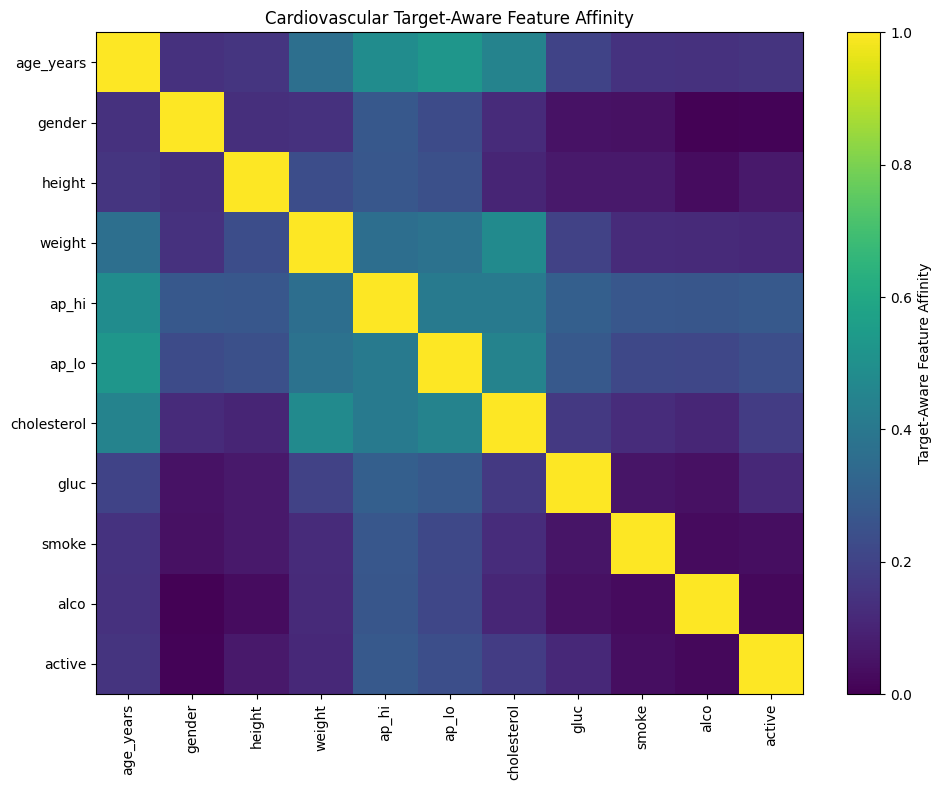

In [ ]:
#Plot affinity matrix
plt.figure(figsize=(10, 8))

plt.imshow(
    cardio_target_affinity_matrix,
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    label="Target-Aware Feature Affinity"
)

plt.xticks(
    range(len(cardio_feature_names)),
    cardio_feature_names,
    rotation=90
)

plt.yticks(
    range(len(cardio_feature_names)),
    cardio_feature_names
)

plt.title(
    "Cardiovascular Target-Aware "
    "Feature Affinity"
)

plt.tight_layout()
plt.show()

In [ ]:
#Normalize individual feature relevance
cardio_individual_auc_array = np.array(
    [
        cardio_individual_feature_auc[
            feature_name
        ]
        for feature_name
        in cardio_feature_names
    ],
    dtype=float
)

cardio_min_individual_auc = float(
    cardio_individual_auc_array.min()
)

cardio_max_individual_auc = float(
    cardio_individual_auc_array.max()
)

if (
    cardio_max_individual_auc
    > cardio_min_individual_auc
):
    cardio_normalized_relevance = (
        cardio_individual_auc_array
        - cardio_min_individual_auc
    ) / (
        cardio_max_individual_auc
        - cardio_min_individual_auc
    )
else:
    cardio_normalized_relevance = (
        np.ones_like(
            cardio_individual_auc_array
        )
    )

cardio_relevance_df = pd.DataFrame({
    "Feature": cardio_feature_names,

    "Individual CV ROC-AUC": (
        cardio_individual_auc_array
    ),

    "Normalized Relevance": (
        cardio_normalized_relevance
    )
})

display(
    cardio_relevance_df
    .sort_values(
        by="Individual CV ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
    .round(4)
)

,Feature,Individual CV ROC-AUC,Normalized Relevance
0,ap_hi,0.7511,1.0000
1,ap_lo,0.6895,0.7580
2,age_years,0.6363,0.5485
3,weight,0.6009,0.4094
4,cholesterol,0.5928,0.3773
5,gluc,0.5327,0.1412
6,active,0.5145,0.0697
7,height,0.5075,0.0420
8,smoke,0.5043,0.0292
9,alco,0.5013,0.0174


In [ ]:
#Select predictive and diverse anchors
NUMBER_OF_CARDIO_TARGET_PERSPECTIVES = 4

cardio_selected_anchor_indices = []

# First anchor:
# highest individual target relevance
first_cardio_anchor_index = int(
    np.argmax(
        cardio_normalized_relevance
    )
)

cardio_selected_anchor_indices.append(
    first_cardio_anchor_index
)

while (
    len(cardio_selected_anchor_indices)
    < NUMBER_OF_CARDIO_TARGET_PERSPECTIVES
):

    anchor_candidate_records = []

    for candidate_index in range(
        len(cardio_feature_names)
    ):
        if (
            candidate_index
            in cardio_selected_anchor_indices
        ):
            continue

        candidate_relevance = float(
            cardio_normalized_relevance[
                candidate_index
            ]
        )

        maximum_anchor_affinity = max(
            cardio_target_affinity_matrix[
                candidate_index,
                selected_anchor_index
            ]
            for selected_anchor_index
            in cardio_selected_anchor_indices
        )

        candidate_diversity = (
            1.0
            - maximum_anchor_affinity
        )

        candidate_anchor_score = (
            0.70 * candidate_relevance
            + 0.30 * candidate_diversity
        )

        anchor_candidate_records.append({
            "Feature Index": candidate_index,
            "Anchor Score": candidate_anchor_score,
            "Relevance": candidate_relevance,
            "Diversity": candidate_diversity
        })

    anchor_candidate_records.sort(
        key=lambda record: (
            record["Anchor Score"],
            record["Relevance"],
            record["Diversity"],
            -record["Feature Index"]
        ),
        reverse=True
    )

    selected_candidate_index = (
        anchor_candidate_records[0][
            "Feature Index"
        ]
    )

    cardio_selected_anchor_indices.append(
        selected_candidate_index
    )

In [ ]:
#Sort anchors by target relevance
cardio_selected_anchor_indices.sort(
    key=lambda feature_index:
        cardio_normalized_relevance[
            feature_index
        ],
    reverse=True
)

cardio_selected_anchor_features = [
    cardio_feature_names[
        feature_index
    ]
    for feature_index
    in cardio_selected_anchor_indices
]

print(
    "Selected cardiovascular anchors:"
)

for anchor_number, anchor_feature in enumerate(
    cardio_selected_anchor_features,
    start=1
):
    anchor_auc = (
        cardio_individual_feature_auc[
            anchor_feature
        ]
    )

    print(
        f"Anchor {anchor_number}: "
        f"{anchor_feature} "
        f"(AUC = {anchor_auc:.4f})"
    )

Selected cardiovascular anchors:
Anchor 1: ap_hi (AUC = 0.7511)
Anchor 2: ap_lo (AUC = 0.6895)
Anchor 3: age_years (AUC = 0.6363)
Anchor 4: weight (AUC = 0.6009)


In [ ]:
#Define capacities
cardio_target_perspective_capacities = [
    3,
    3,
    3,
    2
]

assert sum(
    cardio_target_perspective_capacities
) == len(
    cardio_feature_names
)

print(
    "Perspective capacities:",
    cardio_target_perspective_capacities
)

Perspective capacities: [3, 3, 3, 2]


In [ ]:
#Initialize groups with anchors
cardio_target_perspective_indices = {
    perspective_index: [
        anchor_index
    ]

    for perspective_index, anchor_index
    in enumerate(
        cardio_selected_anchor_indices
    )
}

for perspective_index in range(
    NUMBER_OF_CARDIO_TARGET_PERSPECTIVES
):
    anchor_index = (
        cardio_target_perspective_indices[
            perspective_index
        ][0]
    )

    print(
        f"Target Perspective "
        f"{perspective_index + 1} "
        f"anchor: "
        f"{cardio_feature_names[anchor_index]}"
    )

Target Perspective 1 anchor: ap_hi
Target Perspective 2 anchor: ap_lo
Target Perspective 3 anchor: age_years
Target Perspective 4 anchor: weight


In [ ]:
#Prepare remaining features
cardio_remaining_feature_indices = [
    feature_index

    for feature_index in range(
        len(cardio_feature_names)
    )

    if feature_index
    not in cardio_selected_anchor_indices
]

print(
    "Remaining features:",
    [
        cardio_feature_names[index]
        for index
        in cardio_remaining_feature_indices
    ]
)

Remaining features: ['gender', 'height', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [ ]:
#Global greedy balanced assignment
cardio_target_assignment_records = []

while len(
    cardio_remaining_feature_indices
) > 0:

    all_possible_assignments = []

    for feature_index in (
        cardio_remaining_feature_indices
    ):
        for perspective_index in range(
            NUMBER_OF_CARDIO_TARGET_PERSPECTIVES
        ):
            current_members = (
                cardio_target_perspective_indices[
                    perspective_index
                ]
            )

            current_size = len(
                current_members
            )

            maximum_size = (
                cardio_target_perspective_capacities[
                    perspective_index
                ]
            )

            if current_size >= maximum_size:
                continue

            mean_affinity = float(
                np.mean(
                    [
                        cardio_target_affinity_matrix[
                            feature_index,
                            member_index
                        ]
                        for member_index
                        in current_members
                    ]
                )
            )

            all_possible_assignments.append({
                "Feature Index": feature_index,

                "Perspective Index": (
                    perspective_index
                ),

                "Mean Affinity": mean_affinity,

                "Feature Relevance": float(
                    cardio_normalized_relevance[
                        feature_index
                    ]
                ),

                "Current Group Size": (
                    current_size
                )
            })

    assert len(
        all_possible_assignments
    ) > 0

    all_possible_assignments.sort(
        key=lambda record: (
            record["Mean Affinity"],
            record["Feature Relevance"],
            -record["Current Group Size"],
            -record["Perspective Index"],
            -record["Feature Index"]
        ),
        reverse=True
    )

    best_assignment = (
        all_possible_assignments[0]
    )

    selected_feature_index = (
        best_assignment["Feature Index"]
    )

    selected_perspective_index = (
        best_assignment[
            "Perspective Index"
        ]
    )

    cardio_target_perspective_indices[
        selected_perspective_index
    ].append(
        selected_feature_index
    )

    cardio_remaining_feature_indices.remove(
        selected_feature_index
    )

    cardio_target_assignment_records.append({
        "Feature": cardio_feature_names[
            selected_feature_index
        ],

        "Assigned Perspective": (
            f"Cardio_Target_Perspective_"
            f"{selected_perspective_index + 1}"
        ),

        "Assignment Affinity": (
            best_assignment[
                "Mean Affinity"
            ]
        ),

        "Normalized Target Relevance": (
            best_assignment[
                "Feature Relevance"
            ]
        )
    })

In [ ]:
#Convert groups into feature names
cardio_target_aware_perspectives = {}

for perspective_index in range(
    NUMBER_OF_CARDIO_TARGET_PERSPECTIVES
):
    perspective_name = (
        f"Cardio_Target_Perspective_"
        f"{perspective_index + 1}"
    )

    perspective_features = [
        cardio_feature_names[
            feature_index
        ]

        for feature_index
        in cardio_target_perspective_indices[
            perspective_index
        ]
    ]

    cardio_target_aware_perspectives[
        perspective_name
    ] = perspective_features

In [ ]:
#Display generated perspectives
for perspective_name, perspective_features in (
    cardio_target_aware_perspectives.items()
):
    print("=" * 60)
    print(perspective_name)

    print(
        "Anchor:",
        perspective_features[0]
    )

    print(
        "Features:",
        perspective_features
    )

    print(
        "Group size:",
        len(perspective_features)
    )

Cardio_Target_Perspective_1
Anchor: ap_hi
Features: ['ap_hi', 'gluc', 'active']
Group size: 3
Cardio_Target_Perspective_2
Anchor: ap_lo
Features: ['ap_lo', 'height', 'gender']
Group size: 3
Cardio_Target_Perspective_3
Anchor: age_years
Features: ['age_years', 'smoke', 'alco']
Group size: 3
Cardio_Target_Perspective_4
Anchor: weight
Features: ['weight', 'cholesterol']
Group size: 2


In [ ]:
#Perspective summary table
cardio_target_perspective_rows = []

for perspective_name, perspective_features in (
    cardio_target_aware_perspectives.items()
):
    group_feature_indices = [
        cardio_feature_names.index(
            feature
        )
        for feature
        in perspective_features
    ]

    within_group_affinities = []

    for first_position in range(
        len(group_feature_indices)
    ):
        for second_position in range(
            first_position + 1,
            len(group_feature_indices)
        ):
            within_group_affinities.append(
                cardio_target_affinity_matrix[
                    group_feature_indices[
                        first_position
                    ],
                    group_feature_indices[
                        second_position
                    ]
                ]
            )

    if len(within_group_affinities) > 0:
        mean_within_group_affinity = float(
            np.mean(
                within_group_affinities
            )
        )
    else:
        mean_within_group_affinity = np.nan

    mean_individual_auc = float(
        np.mean(
            [
                cardio_individual_feature_auc[
                    feature
                ]
                for feature
                in perspective_features
            ]
        )
    )

    cardio_target_perspective_rows.append({
        "Perspective": perspective_name,

        "Anchor": perspective_features[0],

        "Features": ", ".join(
            perspective_features
        ),

        "Group Size": len(
            perspective_features
        ),

        "Mean Individual AUC": (
            mean_individual_auc
        ),

        "Mean Within-Group Affinity": (
            mean_within_group_affinity
        )
    })

cardio_target_perspective_summary_df = (
    pd.DataFrame(
        cardio_target_perspective_rows
    )
)

display(
    cardio_target_perspective_summary_df.round(4)
)

,Perspective,Anchor,Features,Group Size,Mean Individual AUC,Mean Within-Group Affinity
0,Cardio_Target_Perspective_1,ap_hi,"ap_hi, gluc, active",3,0.5994,0.2336
1,Cardio_Target_Perspective_2,ap_lo,"ap_lo, height, gender",3,0.5646,0.2029
2,Cardio_Target_Perspective_3,age_years,"age_years, smoke, alco",3,0.5473,0.1063
3,Cardio_Target_Perspective_4,weight,"weight, cholesterol",2,0.5968,0.4774


In [ ]:
#Assignment details
cardio_target_assignment_df = pd.DataFrame(
    cardio_target_assignment_records
)

display(
    cardio_target_assignment_df.round(4)
)

,Feature,Assigned Perspective,Assignment Affinity,Normalized Target Relevance
0,cholesterol,Cardio_Target_Perspective_4,0.4774,0.3773
1,gluc,Cardio_Target_Perspective_1,0.3037,0.1412
2,height,Cardio_Target_Perspective_2,0.2438,0.0420
3,active,Cardio_Target_Perspective_1,0.1985,0.0697
4,gender,Cardio_Target_Perspective_2,0.1824,0.0000
5,smoke,Cardio_Target_Perspective_3,0.1466,0.0292
6,alco,Cardio_Target_Perspective_3,0.0861,0.0174


In [ ]:
#Validate balanced perspectives
all_cardio_target_features = []

for perspective_features in (
    cardio_target_aware_perspectives.values()
):
    all_cardio_target_features.extend(
        perspective_features
    )

cardio_target_group_sizes = [
    len(perspective_features)

    for perspective_features in (
        cardio_target_aware_perspectives.values()
    )
]

assert len(
    cardio_target_aware_perspectives
) == 4

assert sorted(
    cardio_target_group_sizes,
    reverse=True
) == [3, 3, 3, 2]

assert len(
    all_cardio_target_features
) == 11

assert len(
    set(all_cardio_target_features)
) == 11

assert set(
    all_cardio_target_features
) == set(
    cardio_feature_names
)

assert np.allclose(
    cardio_target_affinity_matrix,
    cardio_target_affinity_matrix.T
)

assert np.all(
    cardio_target_affinity_matrix >= 0
)

assert np.all(
    cardio_target_affinity_matrix <= 1
)

print(
    "Cardiovascular target-aware balanced "
    "perspective generation passed."
)

print(
    "Generated group sizes:",
    cardio_target_group_sizes
)

Cardiovascular target-aware balanced perspective generation passed.
Generated group sizes: [3, 3, 3, 2]


### Part C7C: Target-Aware Balanced Perspective MLP

Each target-aware balanced cardiovascular perspective is learned by a separate lightweight MLP. Equal-probability fusion is used for a controlled comparison with the manual and mixed-similarity perspective models.

In [ ]:
cardio_target_models = {}
cardio_target_preprocessors = {}
cardio_target_histories = {}

cardio_target_validation_probabilities = {}
cardio_target_individual_results = []

In [ ]:
#Train perspective-specific MLPs
for perspective_index, (
    perspective_name,
    perspective_features
) in enumerate(
    cardio_target_aware_perspectives.items()
):

    print("=" * 70)
    print("Training:", perspective_name)
    print("Features:", perspective_features)

    # Separate preprocessor for each perspective
    target_preprocessor = (
        build_cardio_perspective_preprocessor(
            perspective_features
        )
    )

    # Fit preprocessing only on development data
    X_target_dev = (
        target_preprocessor.fit_transform(
            X_cardio_dev[
                perspective_features
            ]
        )
        .astype("float32")
    )

    # Validation data is transformed only
    X_target_val = (
        target_preprocessor.transform(
            X_cardio_val[
                perspective_features
            ]
        )
        .astype("float32")
    )

    input_dimension = (
        X_target_dev.shape[1]
    )

    # Reproducible initialization
    keras.utils.set_random_seed(
        CARDIO_SEED
        + 500
        + perspective_index
    )

    target_model = (
        build_cardio_perspective_mlp(
            input_dimension=input_dimension,
            perspective_name=perspective_name
        )
    )

    target_early_stopping = (
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=12,
            restore_best_weights=True,
            verbose=0
        )
    )

    target_history = target_model.fit(
        X_target_dev,
        y_cardio_dev_array,

        validation_data=(
            X_target_val,
            y_cardio_val_array
        ),

        epochs=150,
        batch_size=128,

        callbacks=[
            target_early_stopping
        ],

        verbose=0
    )

    validation_probability = (
        target_model.predict(
            X_target_val,
            verbose=0
        )
        .ravel()
    )

    validation_prediction = (
        validation_probability >= 0.50
    ).astype(int)

    best_epoch = (
        np.argmin(
            target_history.history[
                "val_loss"
            ]
        )
        + 1
    )

    individual_accuracy = accuracy_score(
        y_cardio_val_array,
        validation_prediction
    )

    individual_precision = precision_score(
        y_cardio_val_array,
        validation_prediction,
        zero_division=0
    )

    individual_recall = recall_score(
        y_cardio_val_array,
        validation_prediction,
        zero_division=0
    )

    individual_f1 = f1_score(
        y_cardio_val_array,
        validation_prediction,
        zero_division=0
    )

    individual_auc = roc_auc_score(
        y_cardio_val_array,
        validation_probability
    )

    cardio_target_models[
        perspective_name
    ] = target_model

    cardio_target_preprocessors[
        perspective_name
    ] = target_preprocessor

    cardio_target_histories[
        perspective_name
    ] = target_history

    cardio_target_validation_probabilities[
        perspective_name
    ] = validation_probability

    cardio_target_individual_results.append({
        "Perspective": perspective_name,

        "Features": ", ".join(
            perspective_features
        ),

        "Original Features": len(
            perspective_features
        ),

        "Processed Features": (
            input_dimension
        ),

        "Best Epoch": best_epoch,

        "Validation Accuracy": (
            individual_accuracy
        ),

        "Validation Precision": (
            individual_precision
        ),

        "Validation Recall": (
            individual_recall
        ),

        "Validation F1-score": (
            individual_f1
        ),

        "Validation ROC-AUC": (
            individual_auc
        )
    })

    print(
        "Processed dimension:",
        input_dimension
    )

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Validation accuracy:",
        round(individual_accuracy, 4)
    )

    print(
        "Validation ROC-AUC:",
        round(individual_auc, 4)
    )

Training: Cardio_Target_Perspective_1
Features: ['ap_hi', 'gluc', 'active']
Processed dimension: 5
Best epoch: 19
Validation accuracy: 0.7138
Validation ROC-AUC: 0.7644
Training: Cardio_Target_Perspective_2
Features: ['ap_lo', 'height', 'gender']
Processed dimension: 3
Best epoch: 26
Validation accuracy: 0.664
Validation ROC-AUC: 0.703
Training: Cardio_Target_Perspective_3
Features: ['age_years', 'smoke', 'alco']
Processed dimension: 3
Best epoch: 32
Validation accuracy: 0.5929
Validation ROC-AUC: 0.6321
Training: Cardio_Target_Perspective_4
Features: ['weight', 'cholesterol']
Processed dimension: 4
Best epoch: 32
Validation accuracy: 0.6144
Validation ROC-AUC: 0.6535


In [ ]:
#Individual perspective results\
cardio_target_individual_results_df = (
    pd.DataFrame(
        cardio_target_individual_results
    )
)

display(
    cardio_target_individual_results_df.round(4)
)

,Perspective,Features,Original Features,Processed Features,Best Epoch,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation ROC-AUC
0,Cardio_Target_Perspective_1,"ap_hi, gluc, active",3,5,19,0.7138,0.7554,0.6233,0.6830,0.7644
1,Cardio_Target_Perspective_2,"ap_lo, height, gender",3,3,26,0.6640,0.7777,0.4491,0.5694,0.7030
2,Cardio_Target_Perspective_3,"age_years, smoke, alco",3,3,32,0.5929,0.5967,0.5467,0.5706,0.6321
3,Cardio_Target_Perspective_4,"weight, cholesterol",2,4,32,0.6144,0.6313,0.5303,0.5764,0.6535


In [ ]:
#Equal-probability fusion - Perspective probability matrix
cardio_target_probability_df = pd.DataFrame(
    cardio_target_validation_probabilities,
    index=X_cardio_val.index
)

display(
    cardio_target_probability_df.head()
)

,Cardio_Target_Perspective_1,Cardio_Target_Perspective_2,Cardio_Target_Perspective_3,Cardio_Target_Perspective_4
34416,0.775016,0.413056,0.702812,0.495539
39111,0.338363,0.321826,0.343534,0.598667
66553,0.813003,0.411544,0.545990,0.407717
19062,0.263451,0.331570,0.456540,0.443196
31750,0.263451,0.416255,0.377499,0.464685
